In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import h5py
import scipy.sparse as sp
import yaml
import scanpy as sc
import anndata as an
import scanpy.external as sce
import gget
import time
import pyranges as pr
from scipy.stats import ttest_rel, ttest_ind
from statsmodels.stats.multitest import multipletests

import logging
sc.settings.verbosity = 2

# Load resources

In [2]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

idf.head()

idf.shape=(110149, 11)


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [16]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

# Load data

In [11]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)

adata.var.set_index('transcript_name', inplace=True)

print(adata)
adata.var.head()

AnnData object with n_obs × n_vars = 19858 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
CPU times: user 318 ms, sys: 394 ms, total: 712 ms
Wall time: 1.43 s


,gene_id,gene_name,gene_type,transcript_type,Chromosome,Start,End,transcript_id,UniProtKB
transcript_name,,,,,,,,,
ARF5-201,ENSG00000004059,ARF5,protein_coding,protein_coding,chr7,127588410,127591700,ENST00000000233,P84085
M6PR-201,ENSG00000003056,M6PR,protein_coding,protein_coding,chr12,8940360,8949645,ENST00000000412,P20645
ESRRA-201,ENSG00000173153,ESRRA,protein_coding,protein_coding,chr11,64305523,64316743,ENST00000000442,P11474
FKBP4-201,ENSG00000004478,FKBP4,protein_coding,protein_coding,chr12,2794969,2805423,ENST00000001008,Q02790
CYP26B1-201,ENSG00000003137,CYP26B1,protein_coding,protein_coding,chr2,72129237,72147862,ENST00000001146,Q9NR63


### Filter cells + add clusters from gene data

In [12]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/anndata/condition_subsets/pos_myod.h5ad"
gdata = sc.read_h5ad(fpath)
gdata

CPU times: user 492 ms, sys: 1.43 s, total: 1.92 s
Wall time: 4.19 s


AnnData object with n_obs × n_vars = 12388 × 24505
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'means', 'variance

In [13]:
%%time

print(f"Initial number of cells in adata: {adata.n_obs}")
print(f"Number of cells in gdata: {gdata.n_obs}")

# Subset adata to those present in bdata
cells_to_keep = adata.obs_names.isin(gdata.obs_names)
print(f"Number of cells in adata after filtering by gdata: {cells_to_keep.sum()}")

adata = adata[cells_to_keep, :].copy()
print(f"Final number of cells in adata: {adata.n_obs}")

# Sort adata and bdata to the same order (shared cells only)
shared_cells = gdata.obs_names.intersection(adata.obs_names)
print(f"Number of shared cells: {len(shared_cells)}")

# Sort both AnnData objects
adata = adata[shared_cells, :].copy()
gdata_sorted = gdata[shared_cells, :].copy()

# Assert same order
assert all(adata.obs_names == gdata_sorted.obs_names), "Cell ordering does not match!"
print("Cell ordering is identical between adata and bdata (shared cells).")
adata

Initial number of cells in adata: 19858
Number of cells in gdata: 12388
Number of cells in adata after filtering by gdata: 12388
Final number of cells in adata: 12388
Number of shared cells: 12388
Cell ordering is identical between adata and bdata (shared cells).
CPU times: user 1.38 s, sys: 3.07 s, total: 4.44 s
Wall time: 4.55 s


AnnData object with n_obs × n_vars = 12388 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'

Before merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts']
After merge: adata.obs columns = ['dataset', 'n_reads', 'n_transcripts', 'cluster_str', 'pooled_condition', 'phase']
AnnData object with n_obs × n_vars = 12388 × 89570
    obs: 'dataset', 'n_reads', 'n_transcripts', 'cluster_str', 'pooled_condition', 'phase'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB'
    uns: 'cluster_str_colors', 'dataset_colors', 'pooled_condition_colors', 'draw_graph'
    obsm: 'X_draw_graph_fa'


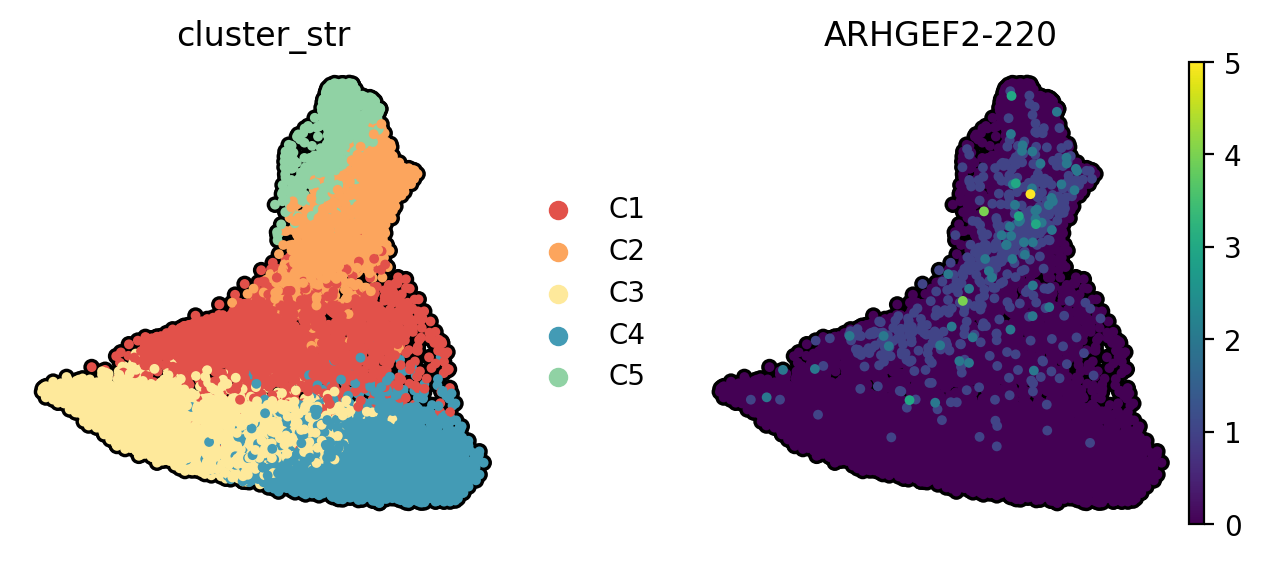

CPU times: user 812 ms, sys: 60.9 ms, total: 873 ms
Wall time: 908 ms


In [14]:
%%time

obs_columns = [
    'cluster_str',
    'pooled_condition',
    'phase',
]

print(f"Before merge: adata.obs columns = {list(adata.obs.columns)}")

# Subset bdata.obs to the needed columns
df_merge = gdata.obs[obs_columns].copy()
df_merge.index.name = "cell"

# Merge by index (obs_names)
adata.obs = adata.obs.merge(df_merge, left_index=True, right_index=True, suffixes=('', '_gdata'))

print(f"After merge: adata.obs columns = {list(adata.obs.columns)}")

# Add uns
adata.uns['cluster_str_colors'] = gdata.uns['cluster_str_colors'].copy()
adata.uns['dataset_colors'] = gdata.uns['dataset_colors'].copy()
adata.uns['pooled_condition_colors'] = gdata.uns['pooled_condition_colors'].copy()

# Merge embeddings
adata.obsm['X_draw_graph_fa'] = gdata.obsm['X_draw_graph_fa'].copy()
adata.uns['draw_graph'] = gdata.uns['draw_graph'].copy()

print(adata)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.draw_graph(
    adata,
    ncols=2,
    sort_order=True,
    color=['cluster_str', 'ARHGEF2-220'],
    size=50,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)

# Preprocessing

In [15]:
sc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43531 genes that are detected in less than 30 counts
normalizing counts per cell
    finished (0:00:01)


AnnData object with n_obs × n_vars = 12388 × 46039
    obs: 'dataset', 'n_reads', 'n_transcripts', 'cluster_str', 'pooled_condition', 'phase'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'UniProtKB', 'n_counts'
    uns: 'cluster_str_colors', 'dataset_colors', 'pooled_condition_colors', 'draw_graph', 'log1p'
    obsm: 'X_draw_graph_fa'
    layers: 'counts', 'log_norm'

# Isoform table

In [17]:
%%time 
adata.X = adata.layers['counts'].copy()
print(f"{type(adata.X)=}")

aggdata = sc.get.aggregate(
    adata, 
    by='cluster_str',
    func='sum',
    axis=0,
)

df = aggdata.to_df(layer='sum')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)

df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
print(f"{df.shape=}")
df.head()

type(adata.X)=<class 'scipy.sparse._csr.csr_matrix'>
df.shape=(46039, 12)
CPU times: user 364 ms, sys: 319 ms, total: 683 ms
Wall time: 715 ms


,transcript_name,C1,C2,C3,C4,C5,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-204,1255.0,1091.0,3135.0,3112.0,171.0,8764.0,A1BG,protein_coding,retained_intron,False,NaN
1,A1BG-AS1-202,13.0,4.0,19.0,19.0,2.0,57.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
2,A1BG-AS1-203,7.0,4.0,11.0,10.0,1.0,33.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
3,A1BG-AS1-204,52.0,40.0,56.0,41.0,16.0,205.0,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-209,70.0,81.0,43.0,32.0,9.0,235.0,A1BG-AS1,lncRNA,lncRNA,False,NaN


# Add splicing events

In [18]:
fpath = "../../resources/AS_events.csv.gz"

asdf = pd.read_csv(fpath)
asdf = asdf[asdf['gene_name'].notna()]
asdf = asdf.drop(columns=['gene_id', 'transcript_id', 'gene_name'])
asdf.head()

df = pd.merge(
    df, asdf,
    how='left',
)
print(f"{df.shape=}")
print()

df.head()

df.shape=(46039, 20)



,transcript_name,C1,C2,C3,C4,C5,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot,A3,A5,AF,AL,MX,RI,SE,num_events
0,A1BG-204,1255.0,1091.0,3135.0,3112.0,171.0,8764.0,A1BG,protein_coding,retained_intron,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A1BG-AS1-202,13.0,4.0,19.0,19.0,2.0,57.0,A1BG-AS1,lncRNA,lncRNA,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1BG-AS1-203,7.0,4.0,11.0,10.0,1.0,33.0,A1BG-AS1,lncRNA,lncRNA,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A1BG-AS1-204,52.0,40.0,56.0,41.0,16.0,205.0,A1BG-AS1,lncRNA,lncRNA,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A1BG-AS1-209,70.0,81.0,43.0,32.0,9.0,235.0,A1BG-AS1,lncRNA,lncRNA,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name', observed=True)['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name', observed=True)['uniprot'].transform('nunique')

# add grouped expression counts
grouped = pdf.groupby('gene_name', observed=True)[['C1', 'C2', 'C3', 'C4', 'C5']].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in ['C1', 'C2', 'C3', 'C4', 'C5']:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'C1_pct', 'C2_pct', 'C5_pct']].head().to_string())

  gene_name transcript_name    C1_pct    C2_pct    C5_pct
0      A1BG        A1BG-204  1.000000  1.000000  1.000000
1  A1BG-AS1    A1BG-AS1-202  0.091549  0.031008  0.071429
2  A1BG-AS1    A1BG-AS1-203  0.049296  0.031008  0.035714
3  A1BG-AS1    A1BG-AS1-204  0.366197  0.310078  0.571429
4  A1BG-AS1    A1BG-AS1-209  0.492958  0.627907  0.321429
CPU times: user 86.2 ms, sys: 460 μs, total: 86.7 ms
Wall time: 93.6 ms


         SE    A5    A3   MX   RI    AF    AL
group                                        
C1     9720  3904  5275  740  626  4888  1327
C2     9196  3686  4983  677  604  4632  1253
C3     9627  3877  5213  729  620  4850  1311
C4     9510  3836  5147  710  607  4809  1307
C5     8735  3479  4716  645  564  4378  1192


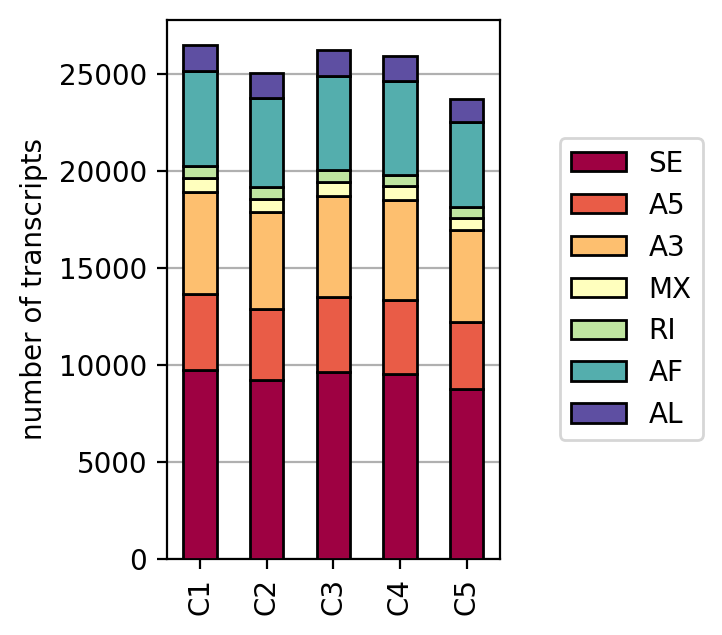

In [21]:
plot_df = pdf.copy()

columns = [
    'gene_name', 'transcript_name',
    'transcript_type', 'uniprot',
    'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE',
    'C1', 'C2', 'C3', 'C4', 'C5',
]

plot_df = plot_df[columns]
plot_df = pd.melt(
    plot_df, id_vars=columns[:-5],
)

event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}

results = []
for group_name, group in plot_df.groupby('variable'):
    group = group[group['transcript_type'] == 'protein_coding']
    group = group[group['uniprot'].notna()]

    row = {
        'group' : group_name,
    }

    for event_type, event_label in event_types.items():
        count = group[(group[event_type] == True) & (group['value'] > 0)]['transcript_name'].nunique()
        row[event_type] = count

    results.append(row)
    
results = pd.DataFrame(results)
results = results.set_index('group')
print(results.to_string())

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.15, 3.5
results.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral'
)

plt.grid(axis='y', zorder=0)
plt.xlabel("")
plt.ylabel("number of transcripts")
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(1.65, 0.5)
)

[Text(0, 0.5, '0.0'),
 Text(0, 0.6000000000000001, '0.6'),
 Text(0, 0.7000000000000001, '0.7'),
 Text(0, 0.8, '0.8'),
 Text(0, 0.9, '0.9'),
 Text(0, 1.0, '1.0'),
 Text(0, 1.1, '1.1')]

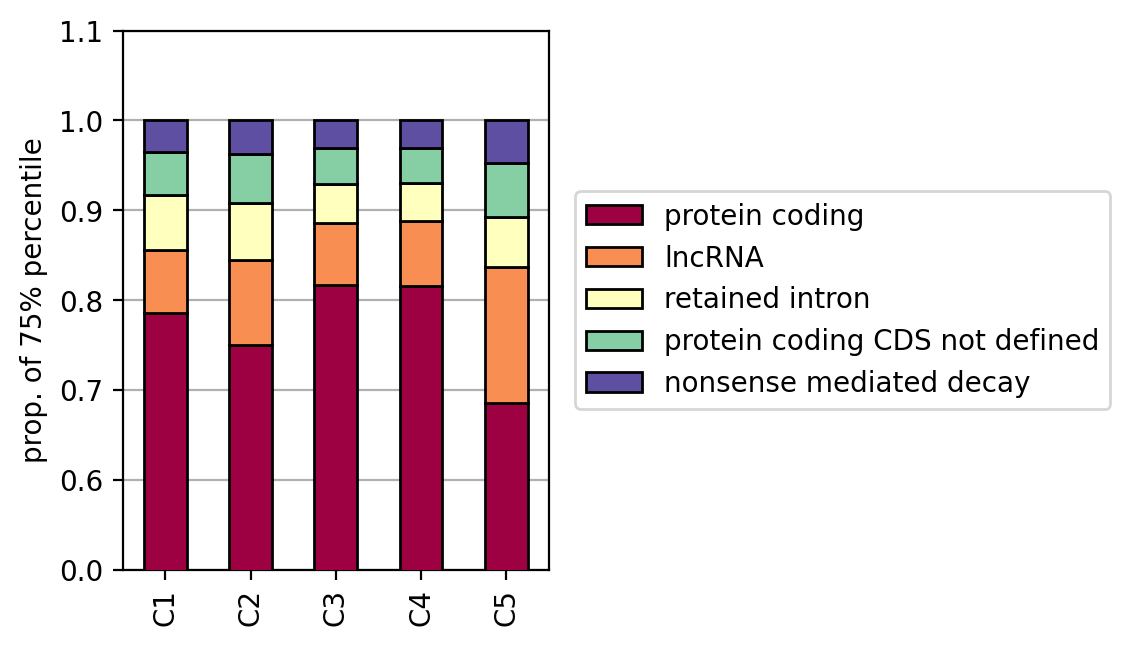

In [22]:
p = 0.75
cols = ['C1', 'C2', 'C3', 'C4', 'C5']

keep = [
    'retained_intron',
    'protein_coding_CDS_not_defined',
    'lncRNA',
    'protein_coding',
    'nonsense_mediated_decay',
    # 'protein_coding_LoF',
]

proportions = {}
for col in cols:
    thresh = pdf[col].quantile(p)
    mask   = (pdf[col] > thresh) & pdf['transcript_type'].isin(keep)
    cnts   = pdf.loc[mask, 'transcript_type'].value_counts(normalize=True)
    cnts.index = cnts.index.str.replace("_", " ")
    proportions[col] = cnts

result = pd.DataFrame(proportions).fillna(0)

# pick the order you want – here, descending in “initial”
order = result['C1'].sort_values(ascending=False).index

# reindex so the stacks plot in that order
result = result.loc[order]
result = result.loc[(result != 0).any(axis=1)]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.75, 3.5
result.T.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral',
)

plt.grid(axis='y', zorder=0)
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(2.35, 0.5)
)
plt.ylabel(f'prop. of {int(p*100)}% percentile')
plt.ylim([0.5, 1.005])

ax = plt.gca()
yticks = ax.get_yticks()
yticklabels = [f"{round(t, 3)}" for t in yticks]
yticklabels[0] = 0.0    # set lowest label manually
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

In [23]:
pdf.head()

,transcript_name,C1,C2,C3,C4,C5,total_transcript,gene_name,gene_type,transcript_type,...,C2_sum,C3_sum,C4_sum,C5_sum,total_gene,C1_pct,C2_pct,C3_pct,C4_pct,C5_pct
0,A1BG-204,1255.0,1091.0,3135.0,3112.0,171.0,8764.0,A1BG,protein_coding,retained_intron,...,1091.0,3135.0,3112.0,171.0,8764.0,1.000000,1.000000,1.000000,1.000000,1.000000
1,A1BG-AS1-202,13.0,4.0,19.0,19.0,2.0,57.0,A1BG-AS1,lncRNA,lncRNA,...,129.0,129.0,102.0,28.0,530.0,0.091549,0.031008,0.147287,0.186275,0.071429
2,A1BG-AS1-203,7.0,4.0,11.0,10.0,1.0,33.0,A1BG-AS1,lncRNA,lncRNA,...,129.0,129.0,102.0,28.0,530.0,0.049296,0.031008,0.085271,0.098039,0.035714
3,A1BG-AS1-204,52.0,40.0,56.0,41.0,16.0,205.0,A1BG-AS1,lncRNA,lncRNA,...,129.0,129.0,102.0,28.0,530.0,0.366197,0.310078,0.434109,0.401961,0.571429
4,A1BG-AS1-209,70.0,81.0,43.0,32.0,9.0,235.0,A1BG-AS1,lncRNA,lncRNA,...,129.0,129.0,102.0,28.0,530.0,0.492958,0.627907,0.333333,0.313725,0.321429


# Isoform dominance

In [26]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

for col in ['C1_pct', 'C2_pct', 'C3_pct', 'C4_pct', 'C5_pct']:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,C1,C2,C3,C4,C5,total_transcript,gene_name,gene_type,transcript_type,...,C1_pct,C2_pct,C3_pct,C4_pct,C5_pct,C1_pct_top,C2_pct_top,C3_pct_top,C4_pct_top,C5_pct_top
0,A1BG-204,1255.0,1091.0,3135.0,3112.0,171.0,8764.0,A1BG,protein_coding,retained_intron,...,1.000000,1.000000,1.000000,1.000000,1.000000,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-AS1-202,13.0,4.0,19.0,19.0,2.0,57.0,A1BG-AS1,lncRNA,lncRNA,...,0.091549,0.031008,0.147287,0.186275,0.071429,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-204,A1BG-AS1-204
2,A1BG-AS1-203,7.0,4.0,11.0,10.0,1.0,33.0,A1BG-AS1,lncRNA,lncRNA,...,0.049296,0.031008,0.085271,0.098039,0.035714,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-204,A1BG-AS1-204
3,A1BG-AS1-204,52.0,40.0,56.0,41.0,16.0,205.0,A1BG-AS1,lncRNA,lncRNA,...,0.366197,0.310078,0.434109,0.401961,0.571429,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-204,A1BG-AS1-204
4,A1BG-AS1-209,70.0,81.0,43.0,32.0,9.0,235.0,A1BG-AS1,lncRNA,lncRNA,...,0.492958,0.627907,0.333333,0.313725,0.321429,A1BG-AS1-209,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-204,A1BG-AS1-204


In [28]:
plot_df = pdf.copy()
print(plot_df.columns)
print()

plot_df = plot_df[~plot_df['gene_name'].str.startswith("MT")]
plot_df = plot_df[~plot_df['gene_name'].str.startswith("RP")]

# Drop rows where all _top values are the same (excluding NaN-only rows)
top_cols = ['C1_pct_top', 'C2_pct_top', 'C3_pct_top', 'C4_pct_top', 'C5_pct_top']

results = []

for column in top_cols:
    label = column.replace("_pct_top", "")
    other_columns = top_cols.copy()
    other_columns.remove(column)
    
    mask = (
        plot_df['transcript_name'] == plot_df[column]) &\
        (plot_df[other_columns].ne(plot_df[column], axis=0).all(axis=1)) &\
        (plot_df['is_tf']) & (plot_df['transcript_type'] == 'protein_coding') &\
        (plot_df['uniprot'].notna()
        )
    
    dominant_iso = plot_df[mask].copy()
    tmp = pd.DataFrame(dominant_iso['gene_name'].unique(), columns=['gene_name'])
    tmp['group'] = label
    results.append(tmp)

results = pd.concat(results)
print(results['group'].value_counts())

results

Index(['transcript_name', 'C1', 'C2', 'C3', 'C4', 'C5', 'total_transcript',
       'gene_name', 'gene_type', 'transcript_type', 'is_tf', 'uniprot', 'A3',
       'A5', 'AF', 'AL', 'MX', 'RI', 'SE', 'num_events', 'n_isoforms',
       'n_protiens', 'C1_sum', 'C2_sum', 'C3_sum', 'C4_sum', 'C5_sum',
       'total_gene', 'C1_pct', 'C2_pct', 'C3_pct', 'C4_pct', 'C5_pct',
       'C1_pct_top', 'C2_pct_top', 'C3_pct_top', 'C4_pct_top', 'C5_pct_top'],
      dtype='object')

group
C5    50
C3    32
C4    29
C2    27
C1    22
Name: count, dtype: int64


,gene_name,group
0,BANP,C1
1,CNOT3,C1
2,ECSIT,C1
3,GTF2IRD1,C1
4,HDX,C1
...,...,...
45,ZNF623,C5
46,ZNF639,C5
47,ZNF677,C5
48,ZNF726,C5


In [33]:
print(results['gene_name'].nunique())
print(", ".join(results['gene_name'].unique()))

140
BANP, CNOT3, ECSIT, GTF2IRD1, HDX, LHX9, MXI1, NFKB2, OSR2, RFX1, TCF3, TCF4, ZBTB3, ZNF189, ZNF324B, ZNF407, ZNF415, ZNF721, ZNF726, ZNF793, ZNF816, ZSCAN32, BCL11A, BNC2, BRF1, CANX, CBFA2T2, FHL2, GIT2, MEF2C, MEF2D, MELK, MSRB3, NCOA1, NR4A1, RAB18, TRIB2, USP39, ZNF232, ZNF343, ZNF613, ZNF682, ZNF700, ZNF780A, ZNF821, ZSCAN2, ZSCAN26, ASCC1, CLK1, FOXP2, HDAC2, ING4, NCOR2, NFXL1, NOC2L, NR2C2, NR3C1, NRF1, PAXIP1, RBM7, SIN3A, ZBTB4, ZBTB48, ZNF107, ZNF155, ZNF195, ZNF239, ZNF254, ZNF286A, ZNF302, ZNF410, ZNF586, ZNF589, ZNF644, ZNF653, ZNF701, ZNF786, ADARB1, CREM, DNAJC21, FIZ1, GABPB1, NR1H3, POU2F2, PRDM5, PRDM11, RFX3, ZFX, ZNF81, ZNF182, ZNF235, ZNF384, ZNF398, ZNF483, ZNF567, ZNF577, ZNF706, ZNF773, AHDC1, BACH1, BACH2, EMX2, GPANK1, KDM5D, LCOR, MAZ, MECOM, MIOS, MORN1, NAP1L1, NCOA2, NFIX, NNT, PICK1, POLI, PPARG, RARB, RFX2, RNASEH2C, RUVBL1, SMAD3, UBTF, USF2, ZFP30, ZFP64, ZFP90, ZKSCAN1, ZNF10, ZNF112, ZNF114, ZNF174, ZNF181, ZNF331, ZNF439, ZNF554, ZNF580, ZNF62

In [35]:
plot_df = pdf.copy()

gene_df = plot_df[plot_df['gene_name'] == 'MEF2C'].reset_index()

gene_df['annotation'] = (
    gene_df['transcript_name']
    + np.where(
        gene_df['uniprot'].notna(),
        ' (' + gene_df['uniprot'] + ')',
        ''
    )
)

gene_df.head()

,index,transcript_name,C1,C2,C3,C4,C5,total_transcript,gene_name,gene_type,...,C2_pct,C3_pct,C4_pct,C5_pct,C1_pct_top,C2_pct_top,C3_pct_top,C4_pct_top,C5_pct_top,annotation
0,24016,MEF2C-203,3.0,0.0,27.0,20.0,0.0,50.0,MEF2C,protein_coding,...,0.000000,0.380282,0.289855,0.000,MEF2C-209,MEF2C-207,MEF2C-203,MEF2C-249,MEF2C-209,MEF2C-203 (Q06413)
1,24017,MEF2C-207,72.0,44.0,2.0,0.0,16.0,134.0,MEF2C,protein_coding,...,0.280255,0.028169,0.000000,0.128,MEF2C-209,MEF2C-207,MEF2C-203,MEF2C-249,MEF2C-209,MEF2C-207 (A0A0D9SGF3)
2,24018,MEF2C-209,76.0,31.0,7.0,5.0,36.0,155.0,MEF2C,protein_coding,...,0.197452,0.098592,0.072464,0.288,MEF2C-209,MEF2C-207,MEF2C-203,MEF2C-249,MEF2C-209,MEF2C-209 (Q06413)
3,24019,MEF2C-215,59.0,40.0,6.0,4.0,18.0,127.0,MEF2C,protein_coding,...,0.254777,0.084507,0.057971,0.144,MEF2C-209,MEF2C-207,MEF2C-203,MEF2C-249,MEF2C-209,MEF2C-215
4,24020,MEF2C-217,44.0,27.0,1.0,3.0,26.0,101.0,MEF2C,protein_coding,...,0.171975,0.014085,0.043478,0.208,MEF2C-209,MEF2C-207,MEF2C-203,MEF2C-249,MEF2C-209,MEF2C-217 (A0A0R4J2G5)


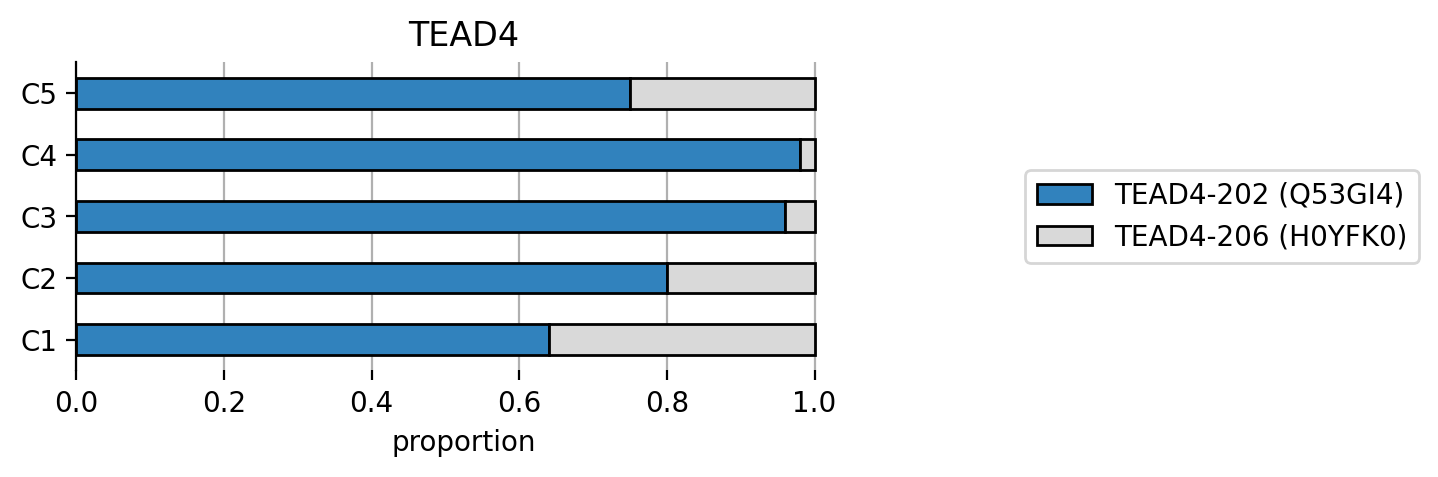

In [38]:
plot_df = pdf.copy()

gene_df = plot_df[plot_df['gene_name'] == 'TEAD4'].reset_index()

# Option 1: using np.where
gene_df['annotation'] = (
    gene_df['transcript_name']
    + np.where(
        gene_df['uniprot'].notna(),
        ' (' + gene_df['uniprot'] + ')',
        ''
    )
)

tmp = gene_df.set_index('annotation').copy()
tmp = tmp[['C1_pct', 'C2_pct', 'C3_pct', 'C4_pct', 'C5_pct']]
tmp.columns = [x.replace("_pct", "") for x in tmp.columns]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 2

# 1) Plot figure without legend
fig1, ax1 = plt.subplots()
tmp.T.plot(
    kind='barh',
    stacked=True,
    ec='k',
    zorder=10,
    width=0.5,
    cmap='tab20c',
    ax=ax1
)
ax1.grid(axis='x', zorder=0)
ax1.set_xlabel("proportion")
sns.move_legend(
    ax1,
    loc='center right',
    title="",
    bbox_to_anchor=(1.75, 0.5),
)
ax1.set_title('TEAD4')
sns.despine(bottom=True)
plt.show()

Index(['transcript_name', 'C1', 'C2', 'C3', 'C4', 'C5', 'total_transcript',
       'gene_name', 'gene_type', 'transcript_type', 'is_tf', 'uniprot', 'A3',
       'A5', 'AF', 'AL', 'MX', 'RI', 'SE', 'num_events', 'n_isoforms',
       'n_protiens', 'C1_sum', 'C2_sum', 'C3_sum', 'C4_sum', 'C5_sum',
       'total_gene', 'C1_pct', 'C2_pct', 'C3_pct', 'C4_pct', 'C5_pct',
       'C1_pct_top', 'C2_pct_top', 'C3_pct_top', 'C4_pct_top', 'C5_pct_top'],
      dtype='object')

BANP


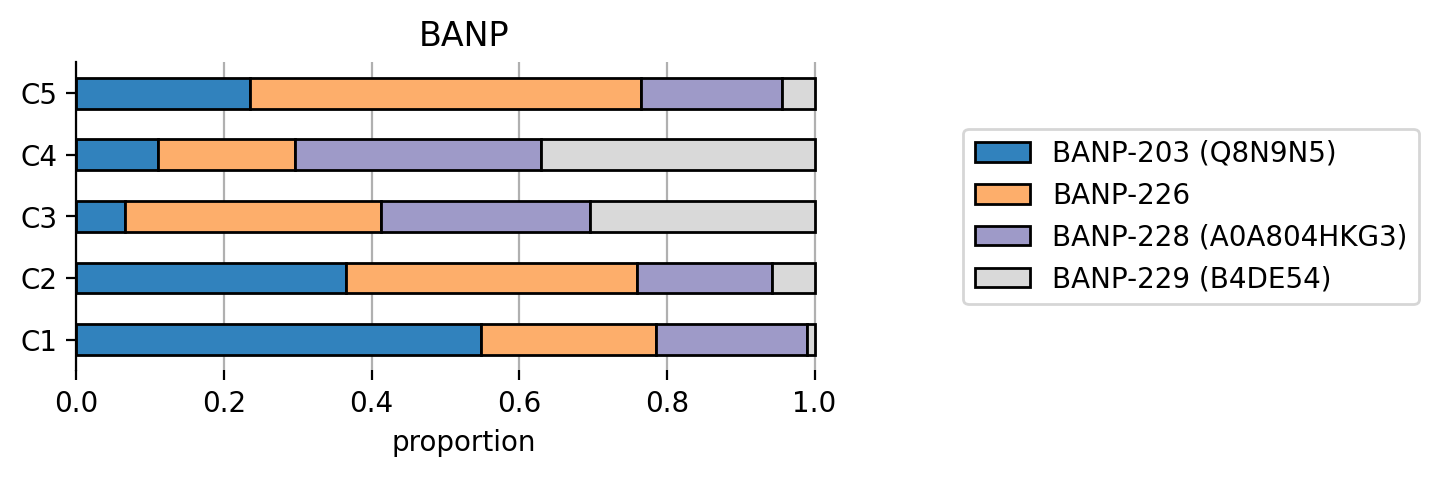

CNOT3


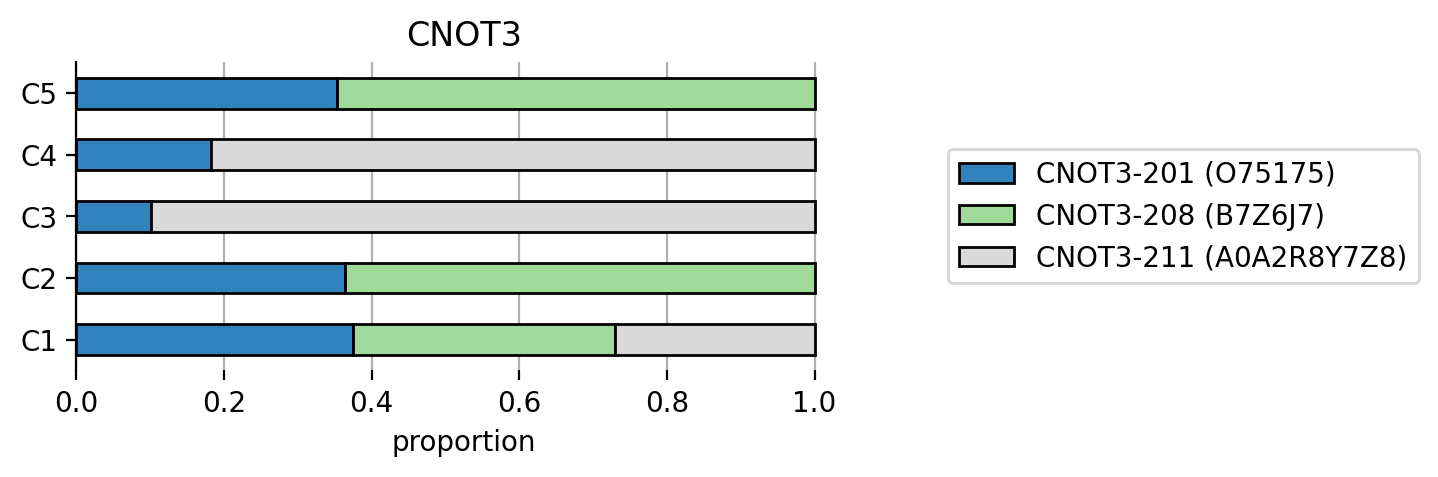

ECSIT


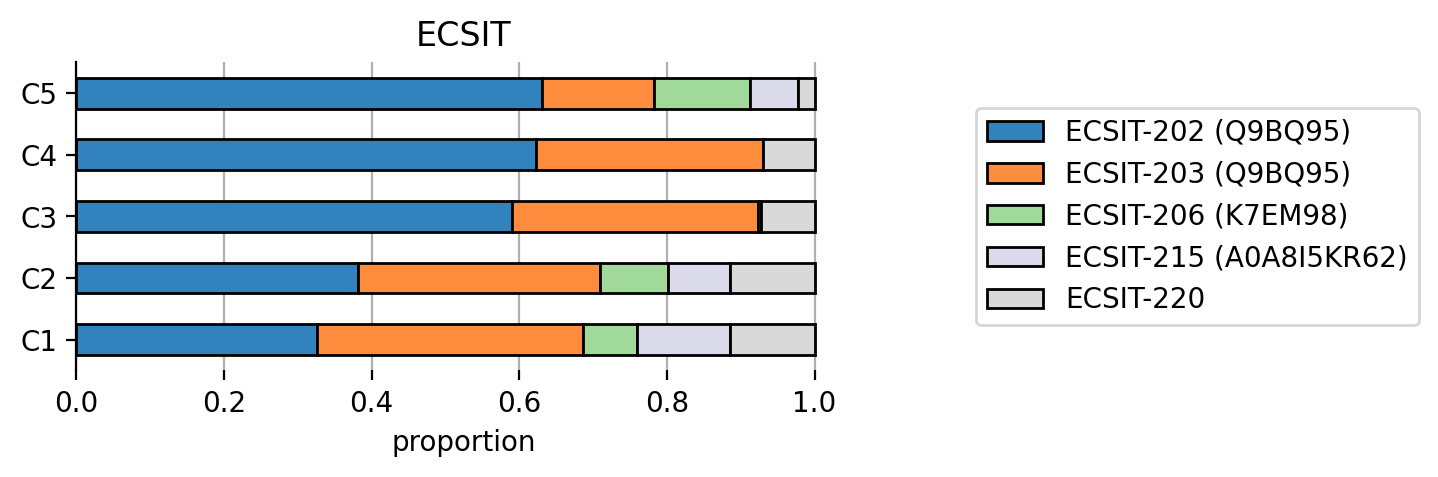

GTF2IRD1


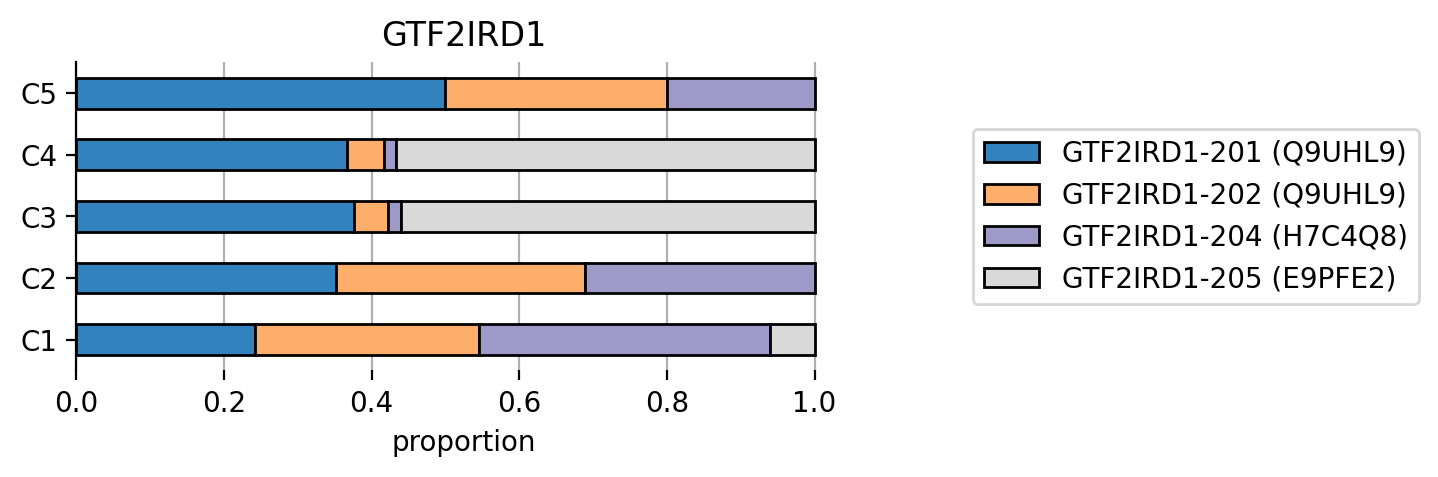

HDX


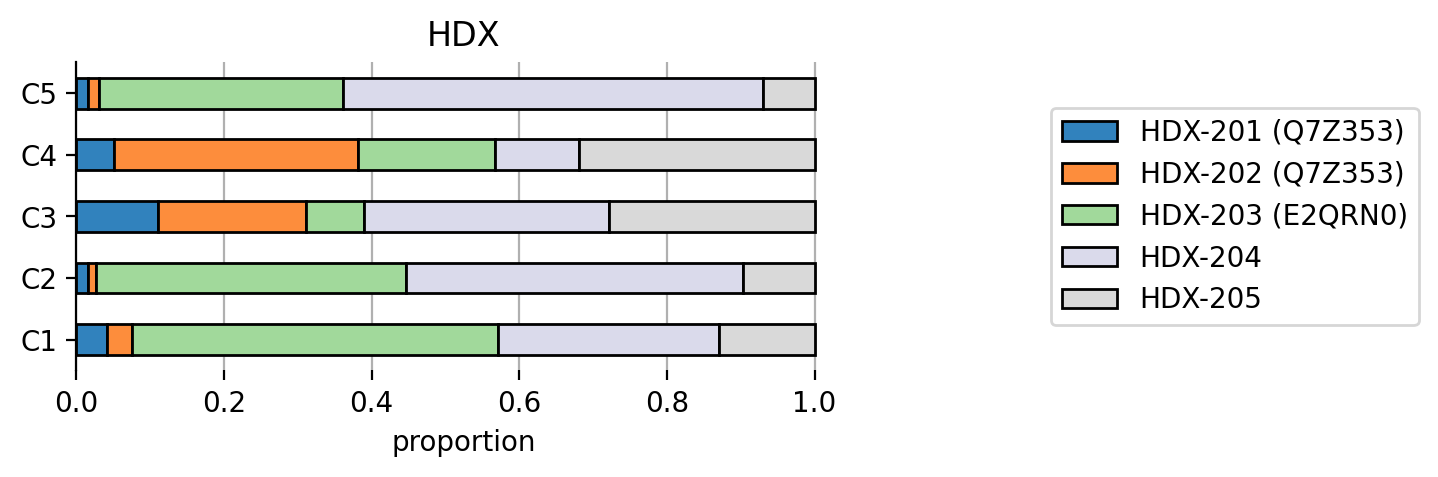

LHX9


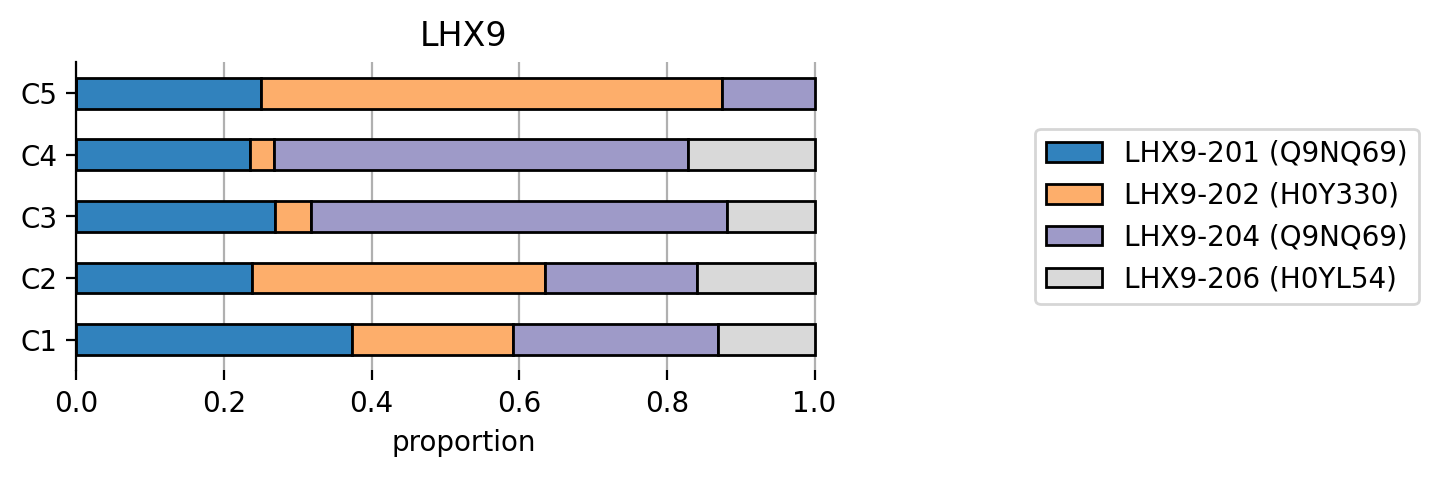

MXI1


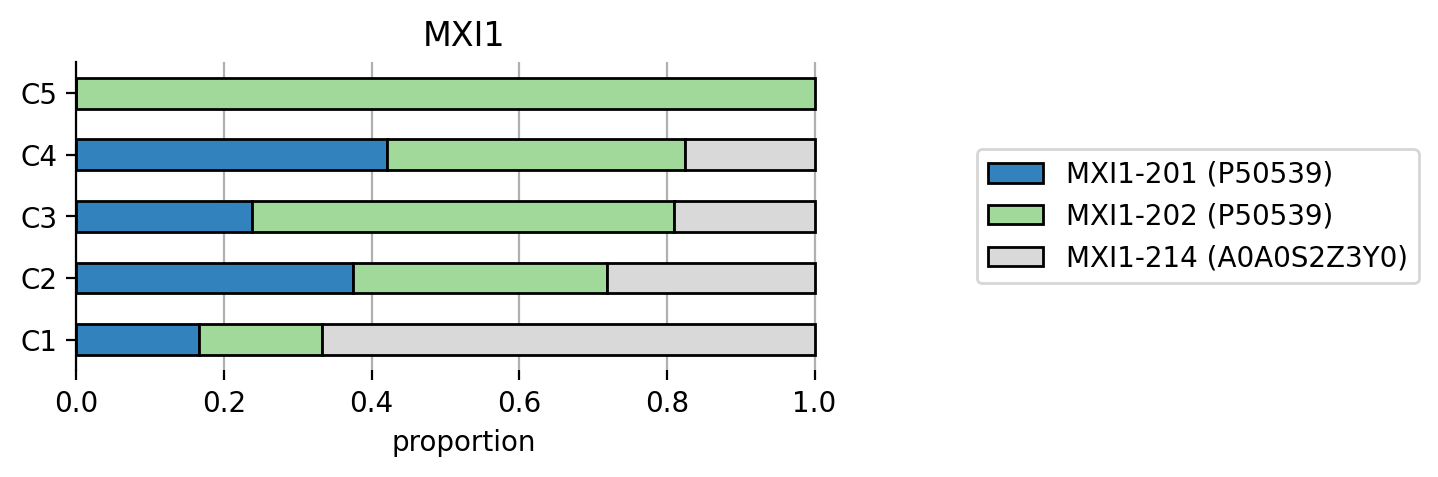

NFKB2


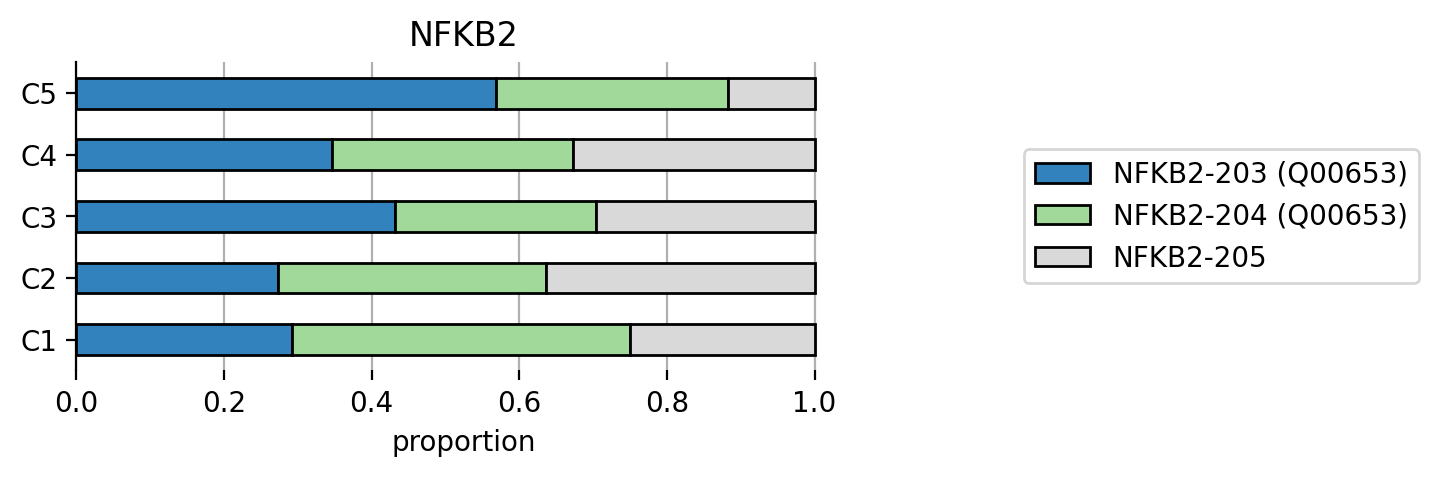

OSR2


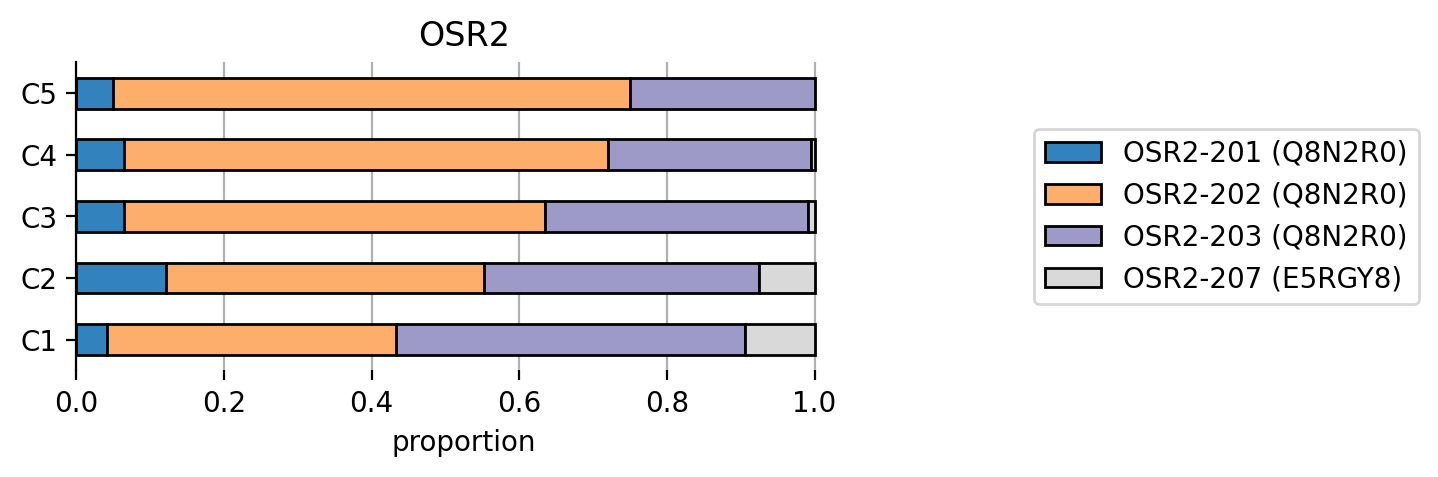

RFX1


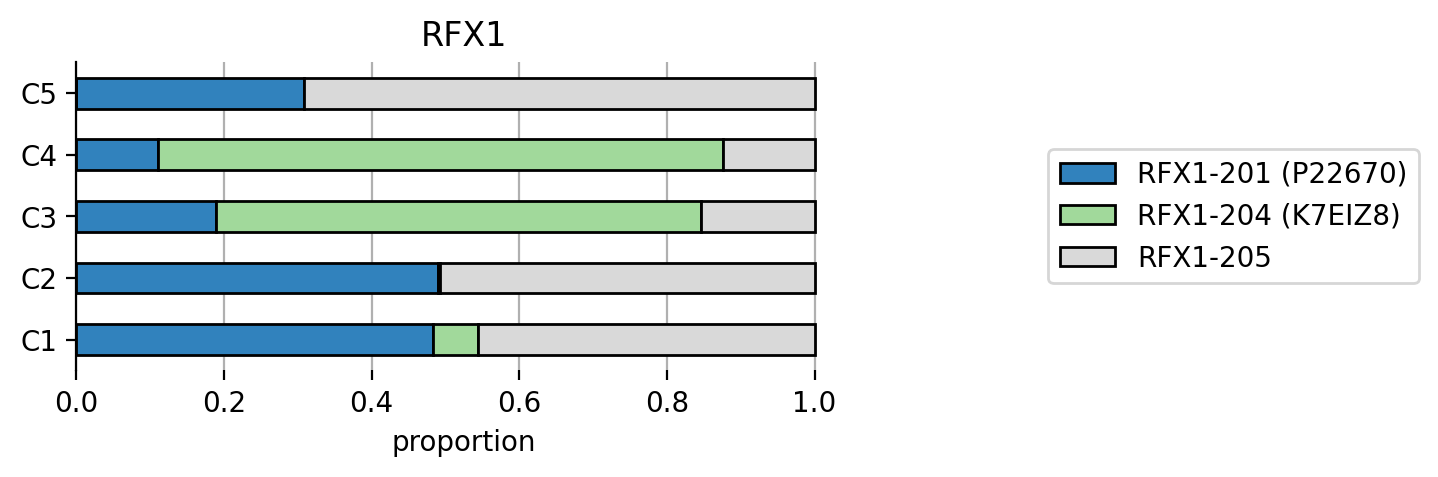

TCF3


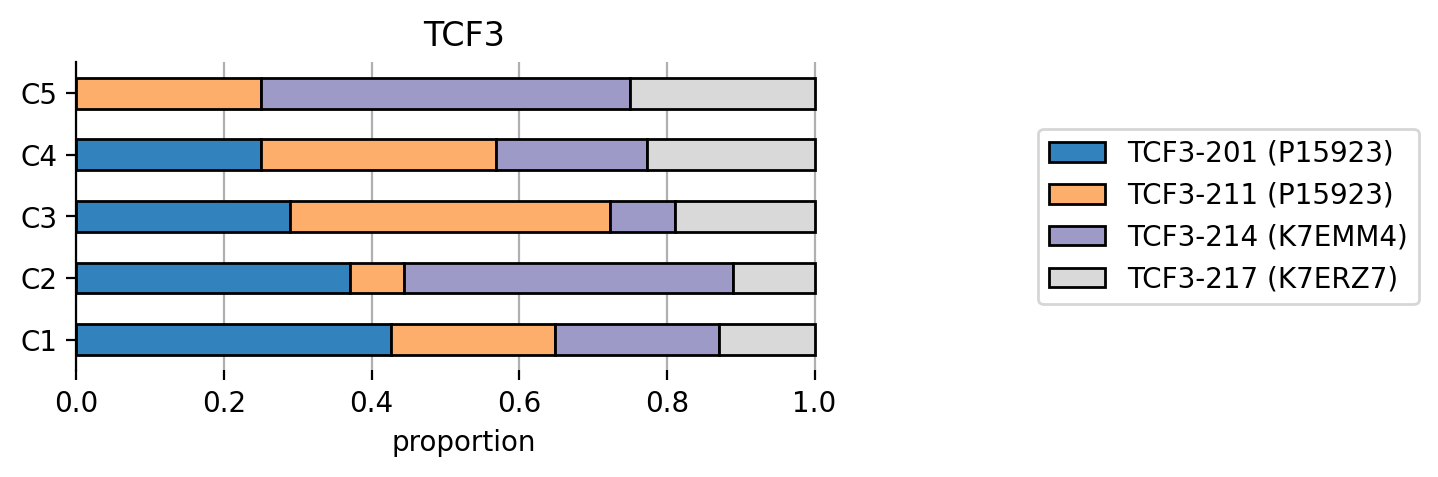

TCF4


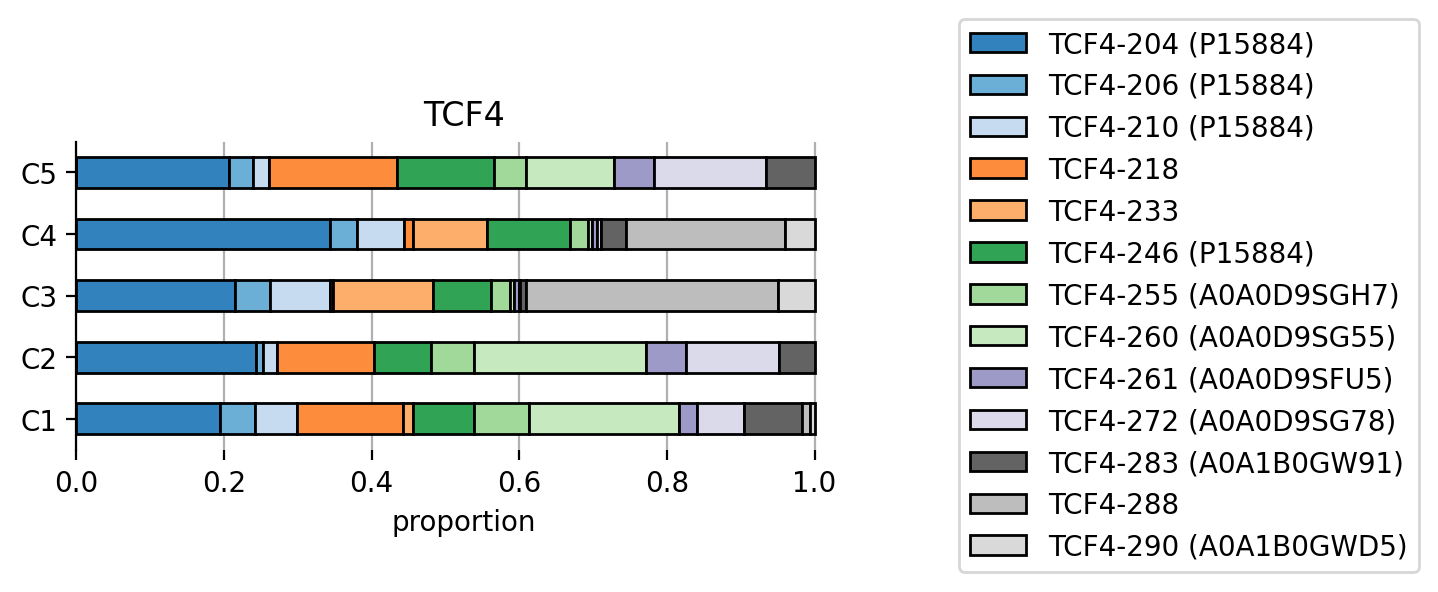

ZBTB3


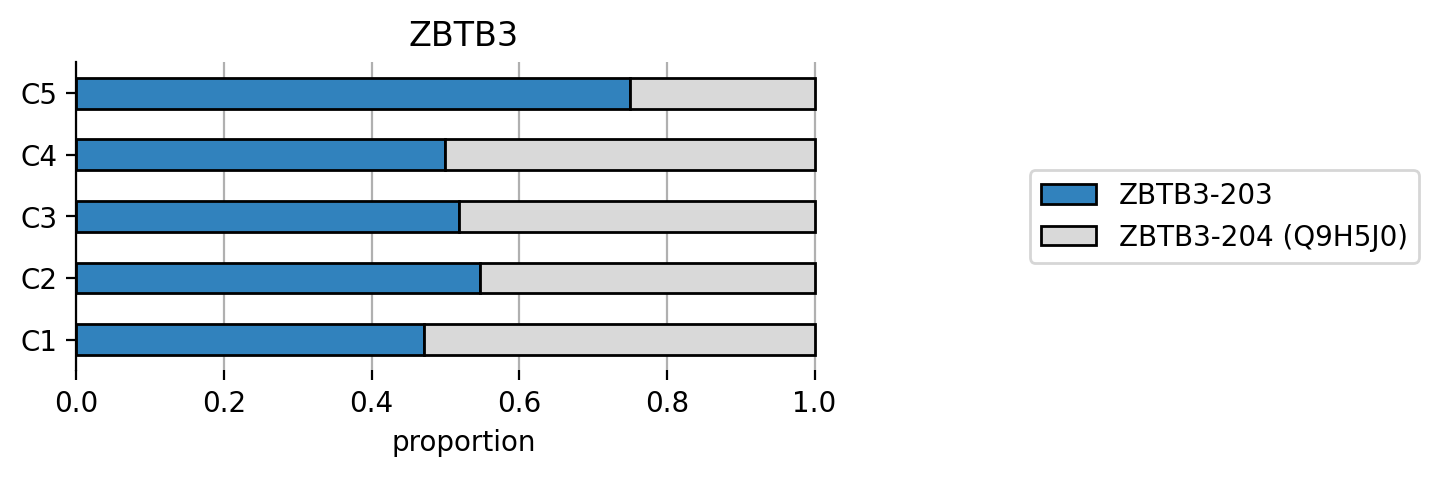

ZNF189


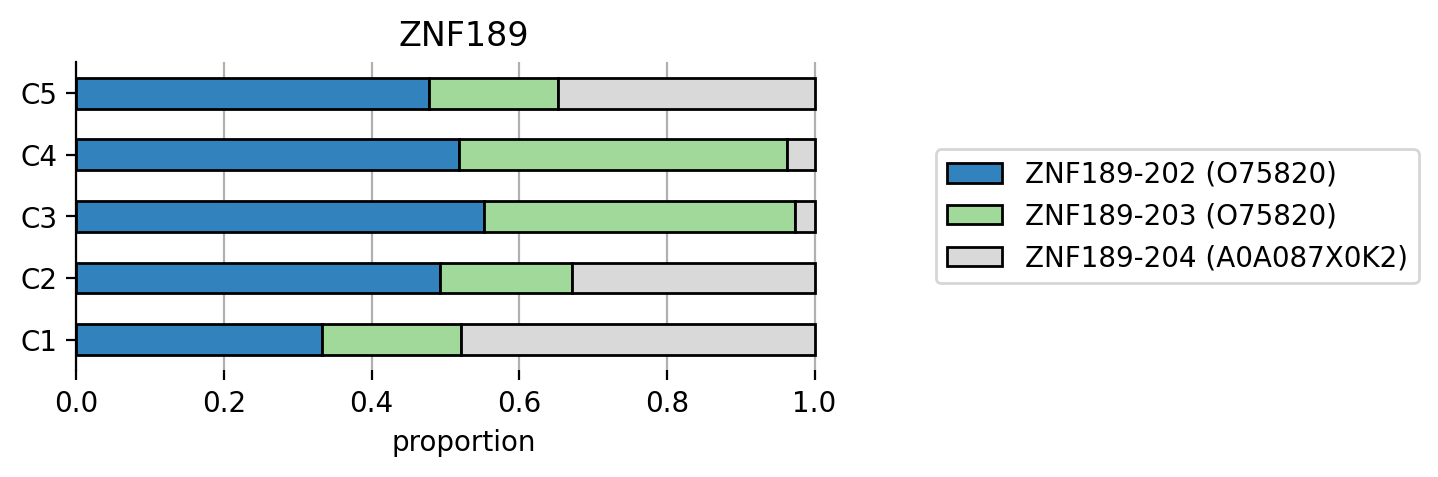

ZNF324B


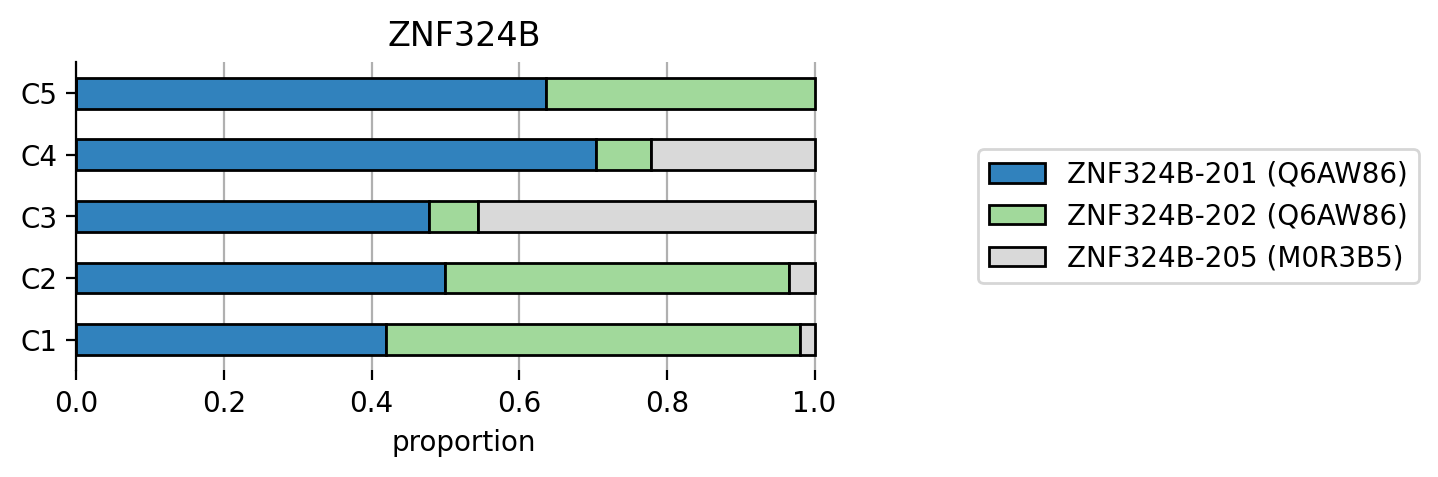

ZNF407


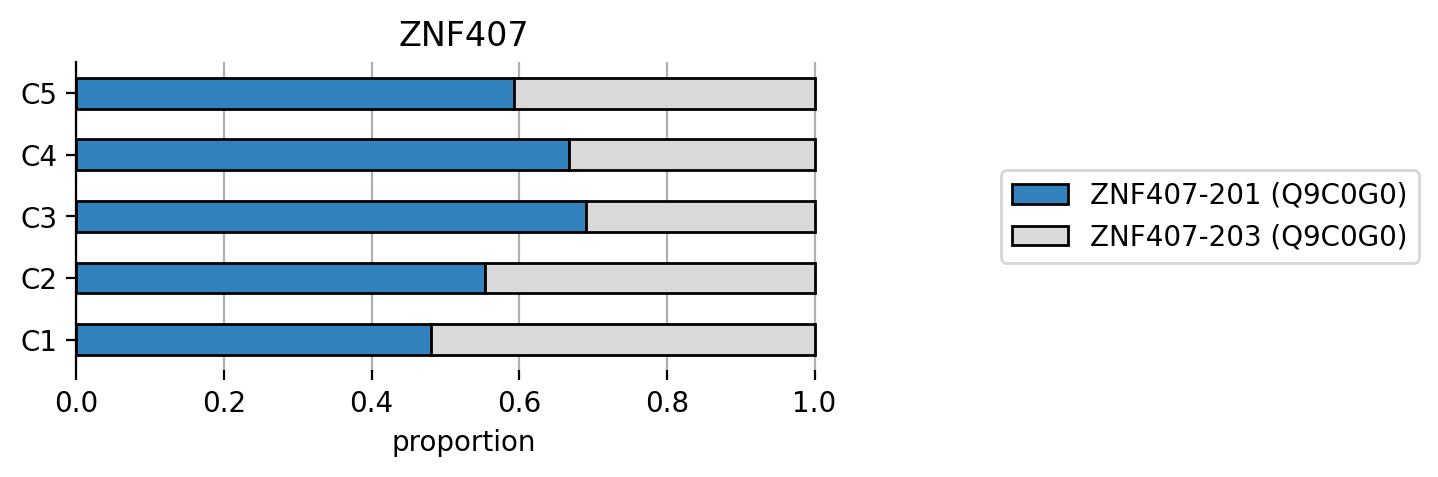

ZNF415


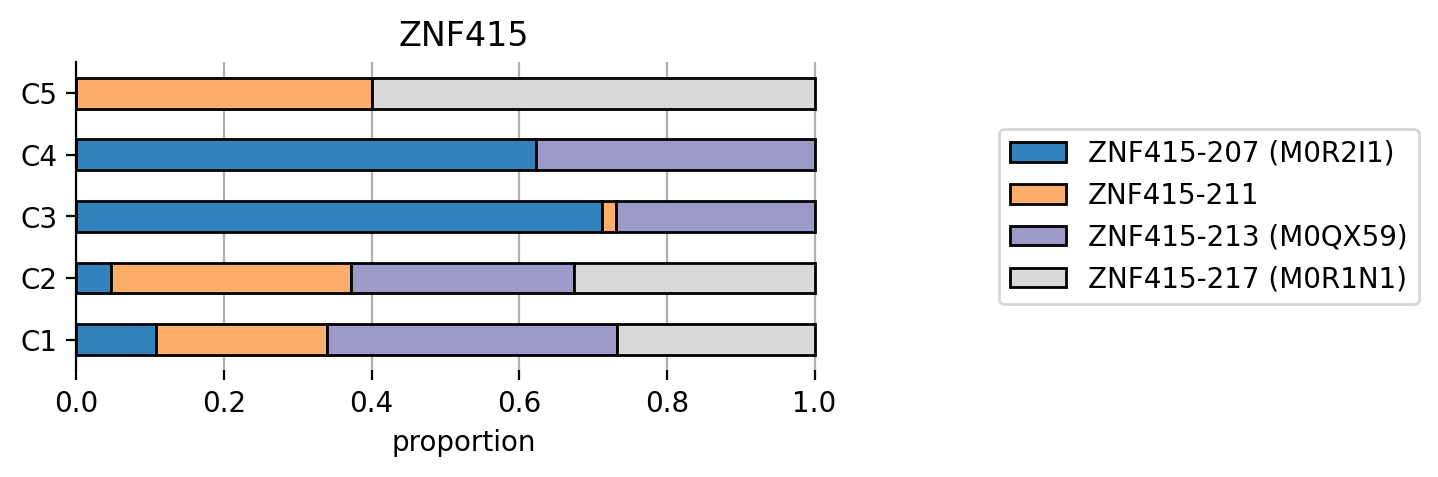

ZNF721


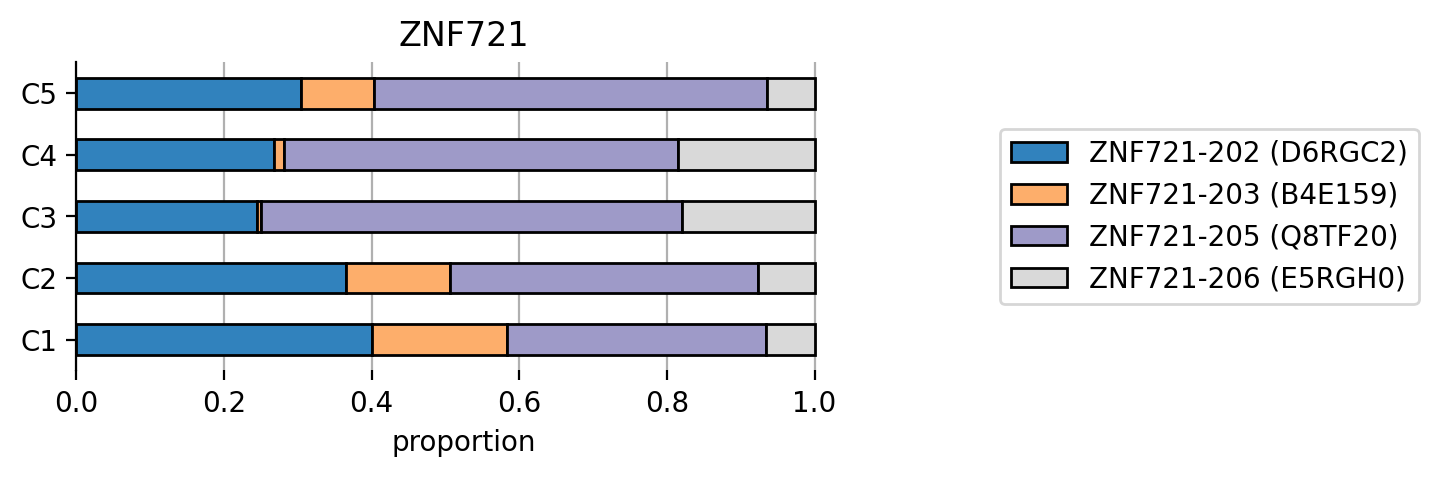

ZNF726


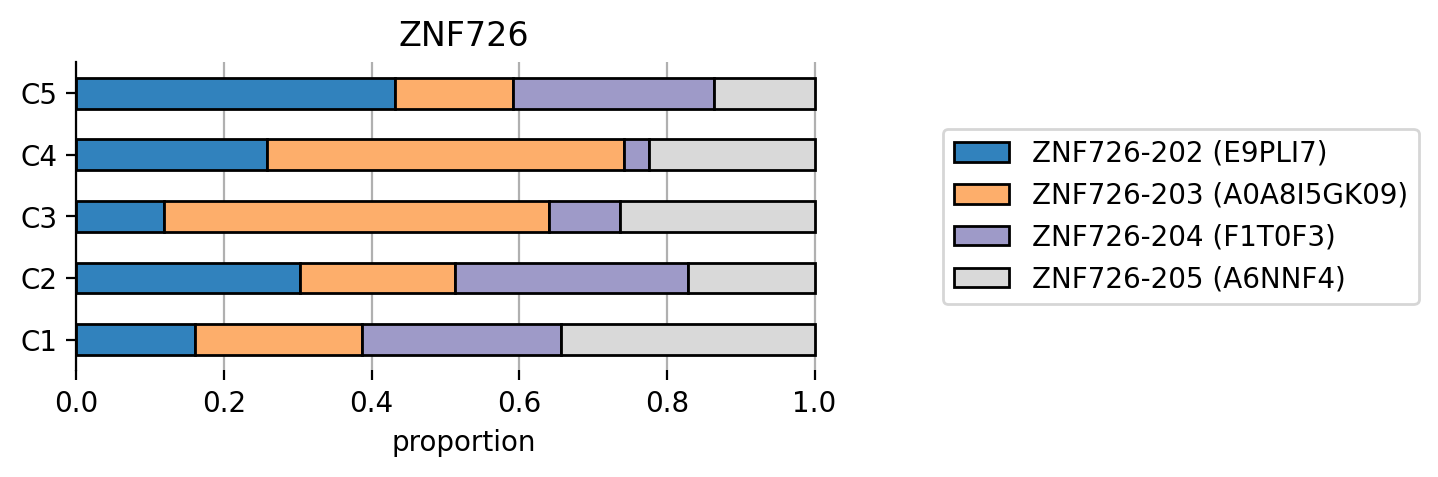

ZNF793


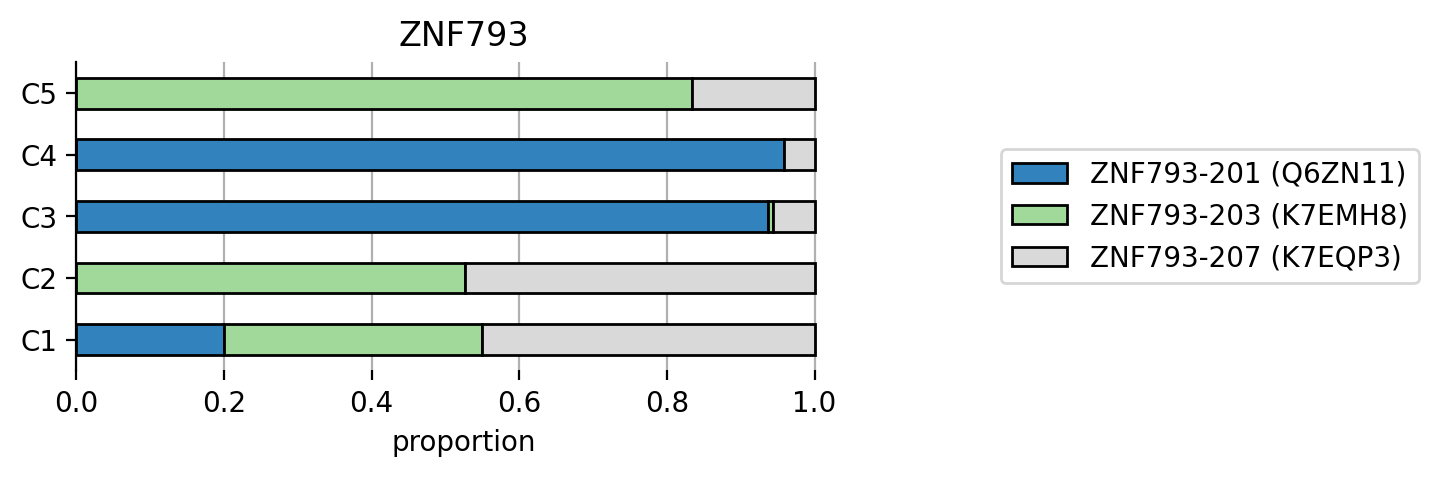

ZNF816


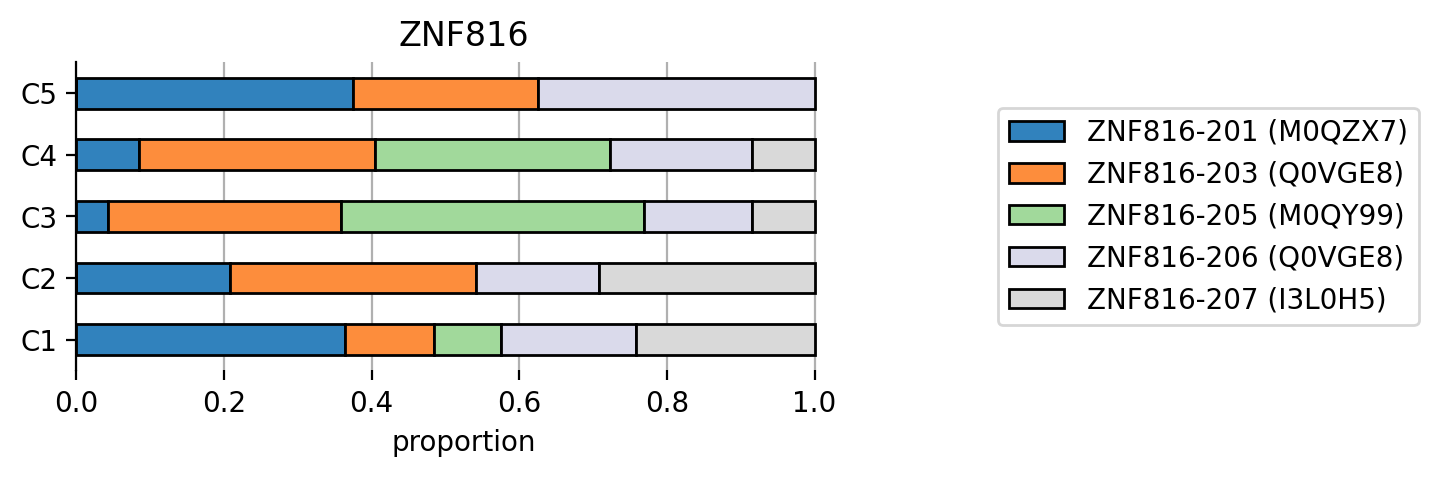

ZSCAN32


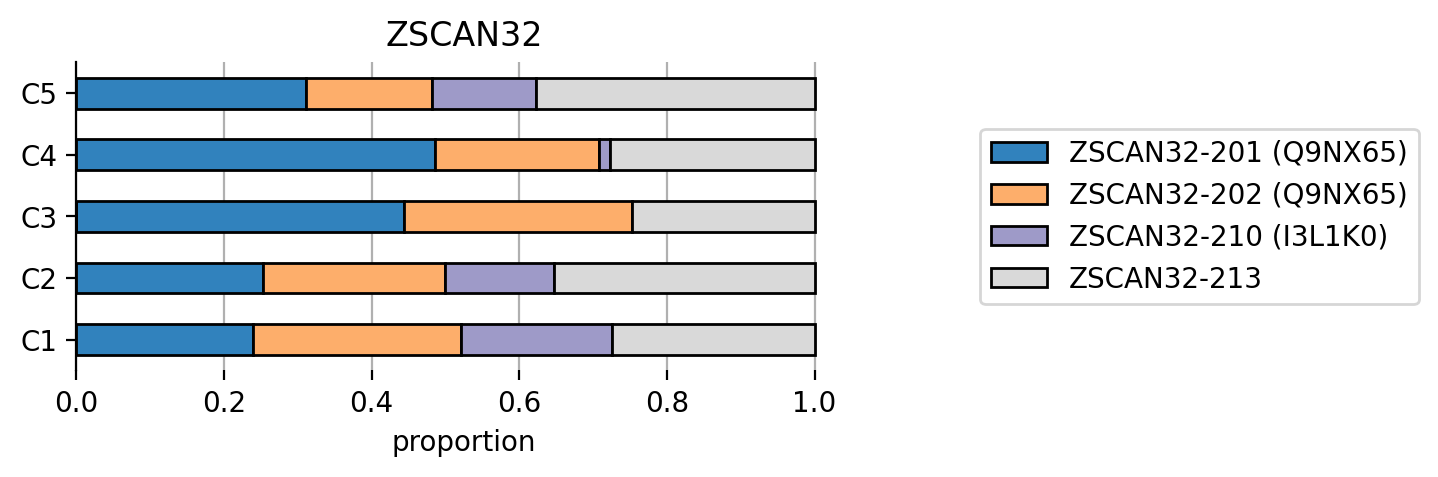

BCL11A


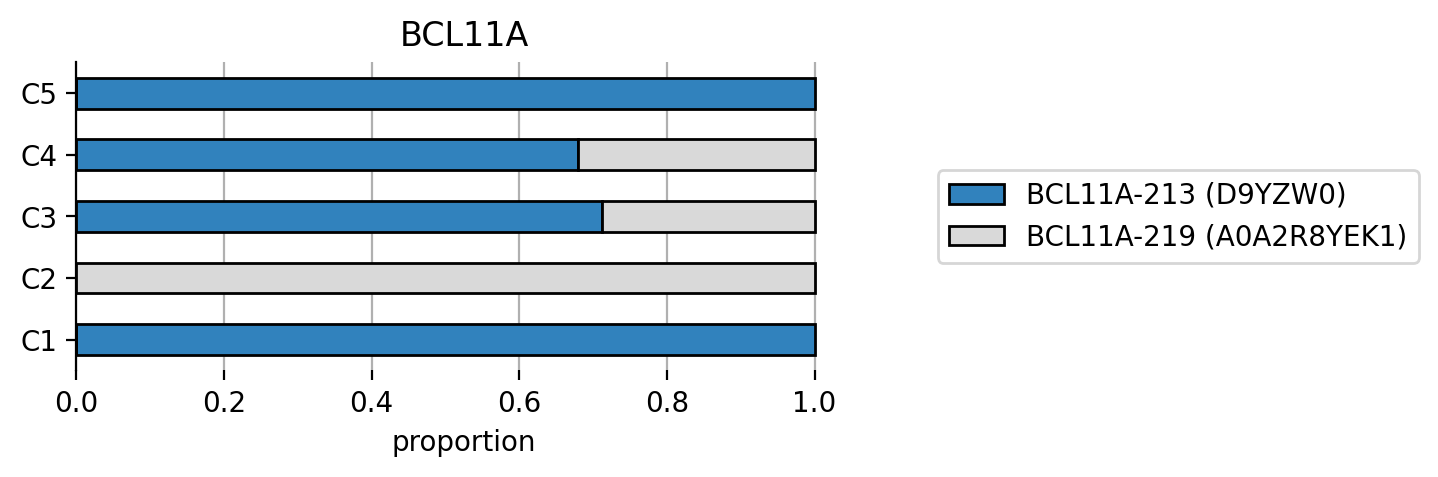

BNC2


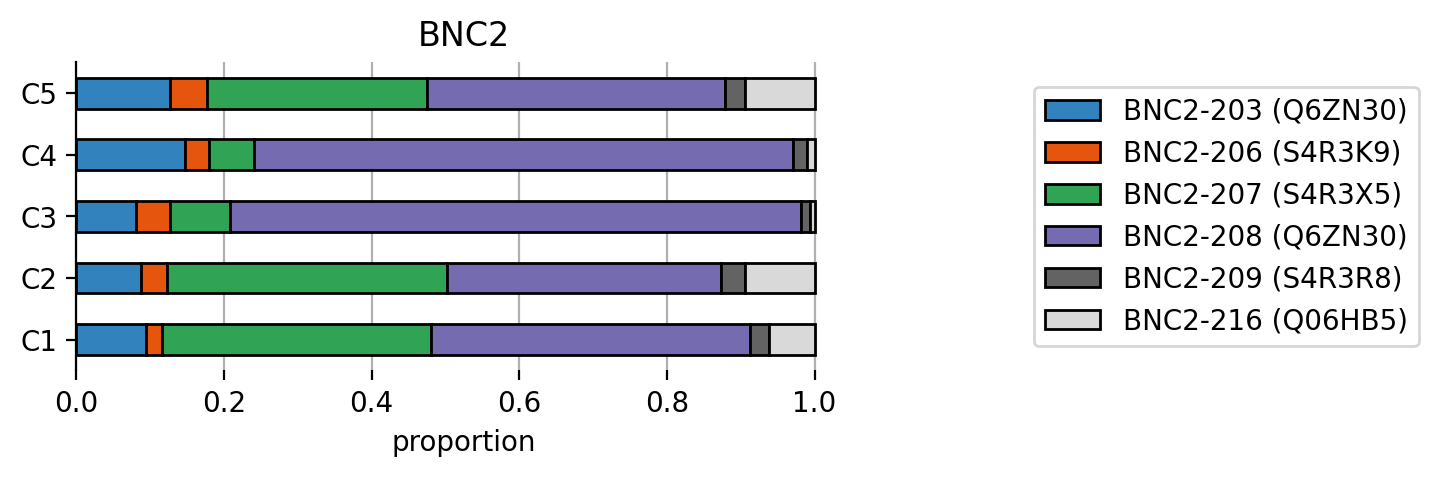

BRF1


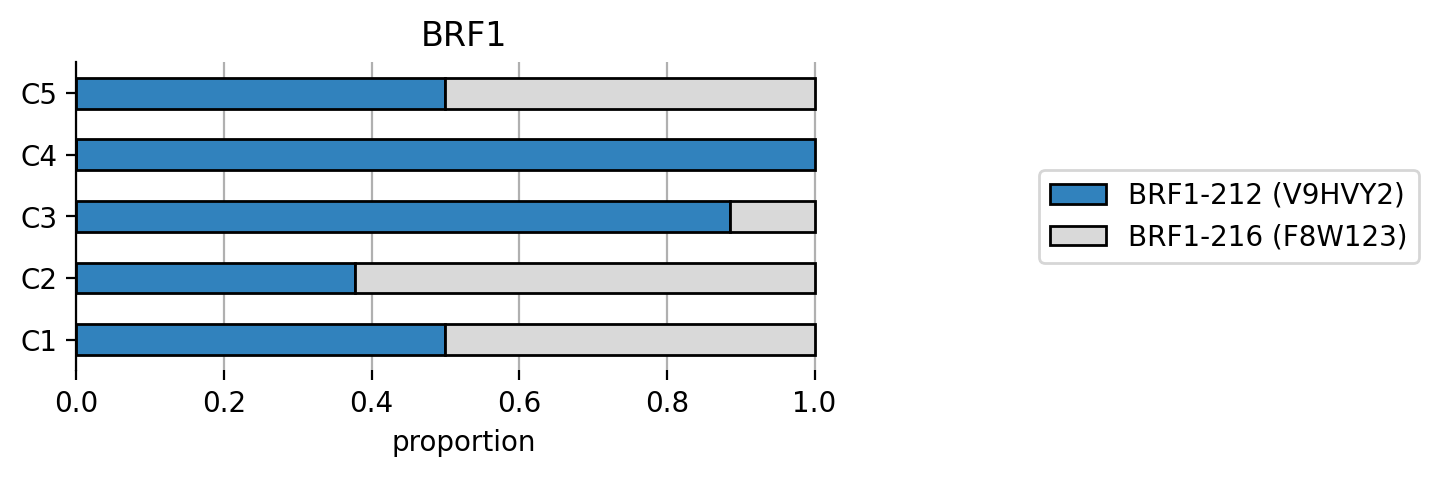

CANX


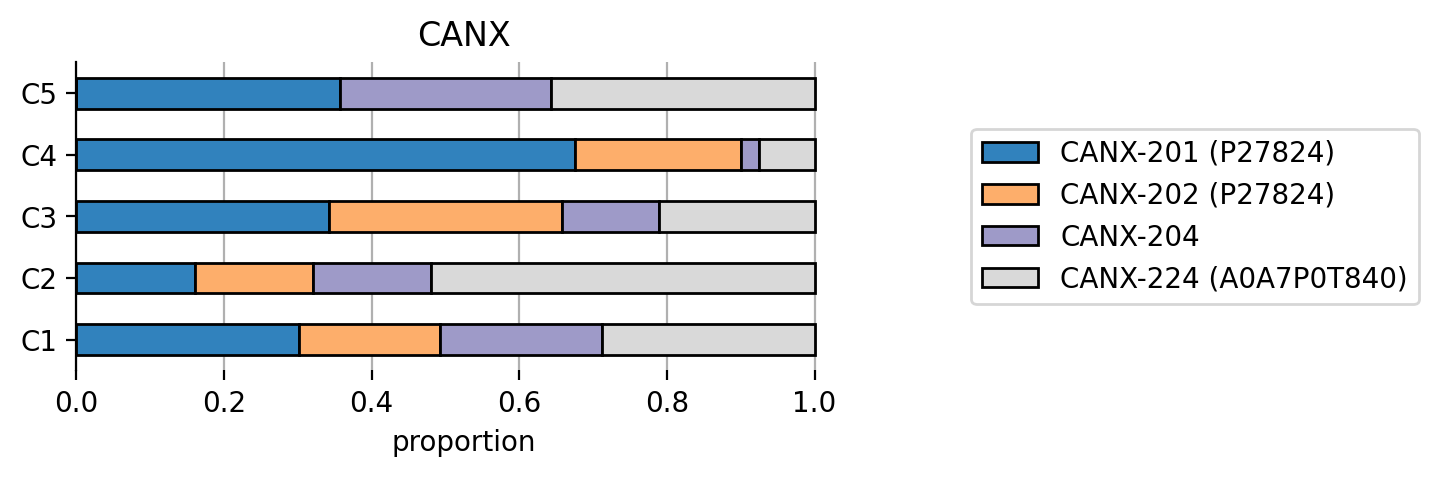

CBFA2T2


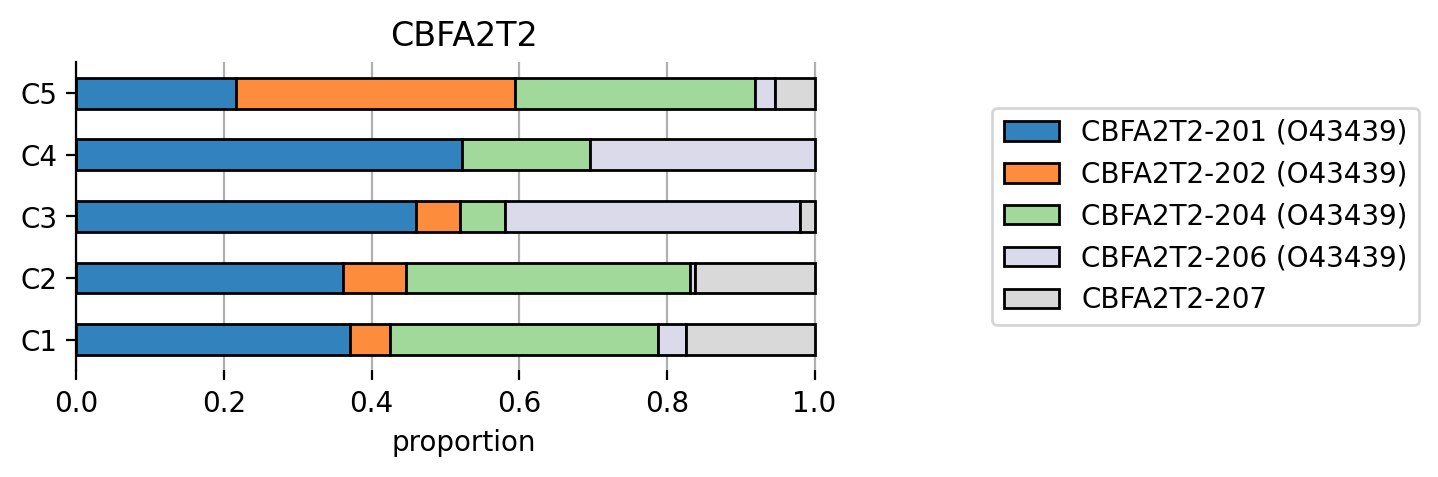

FHL2


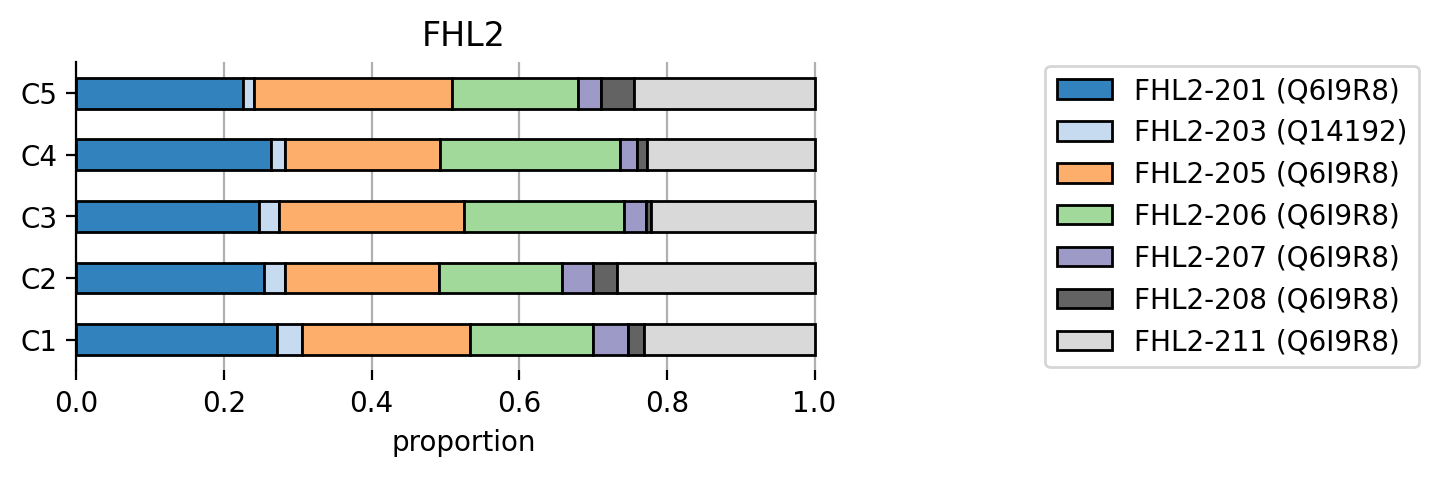

GIT2


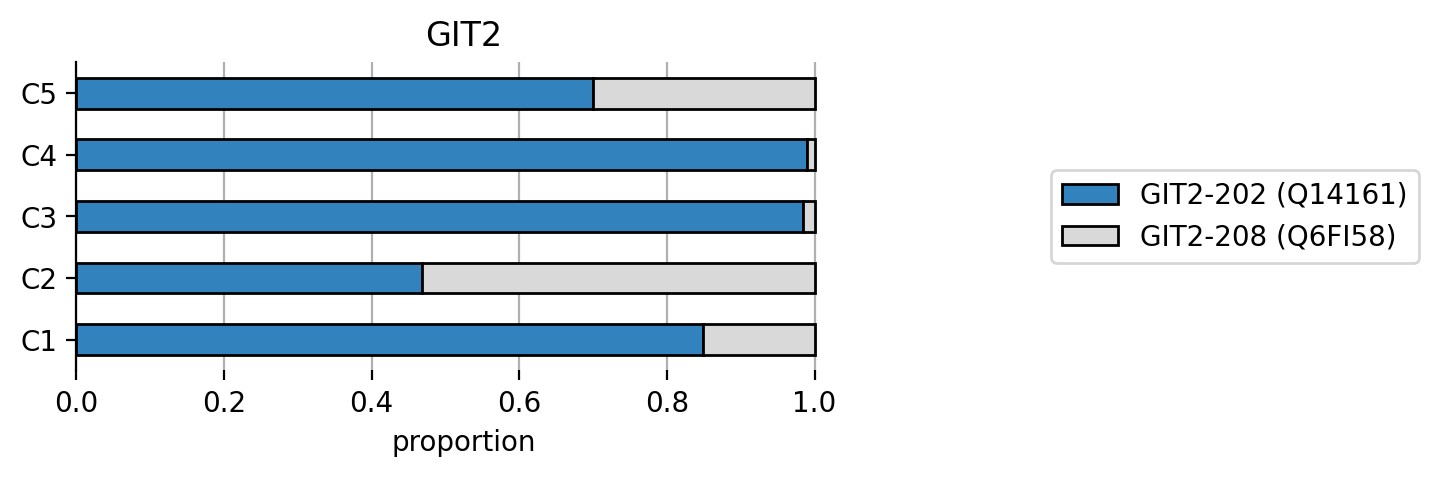

MEF2C


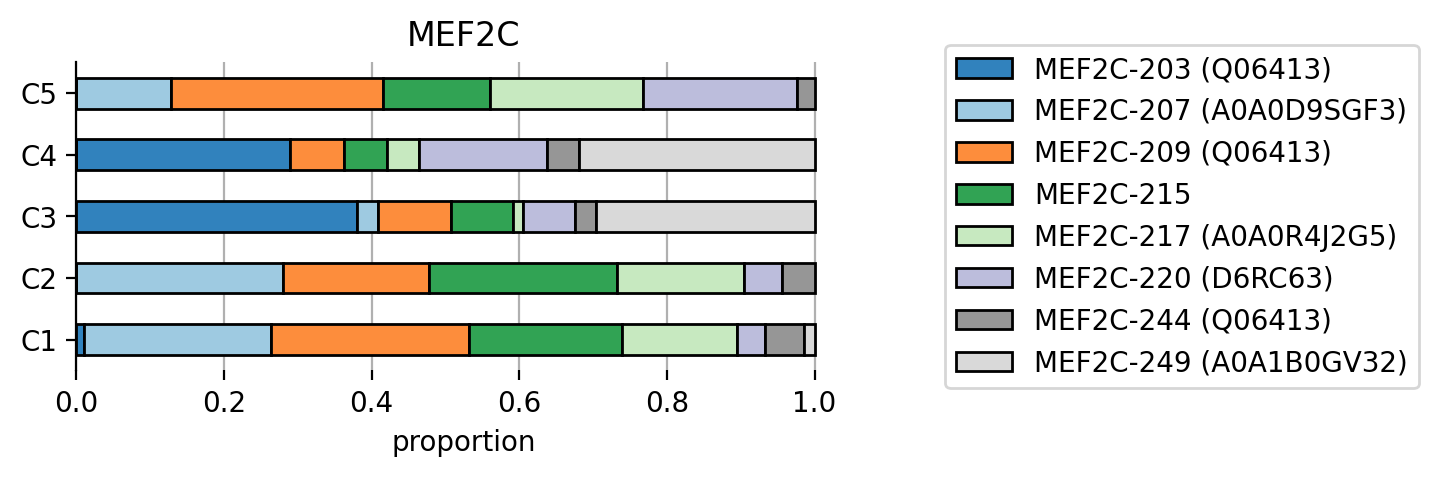

MEF2D


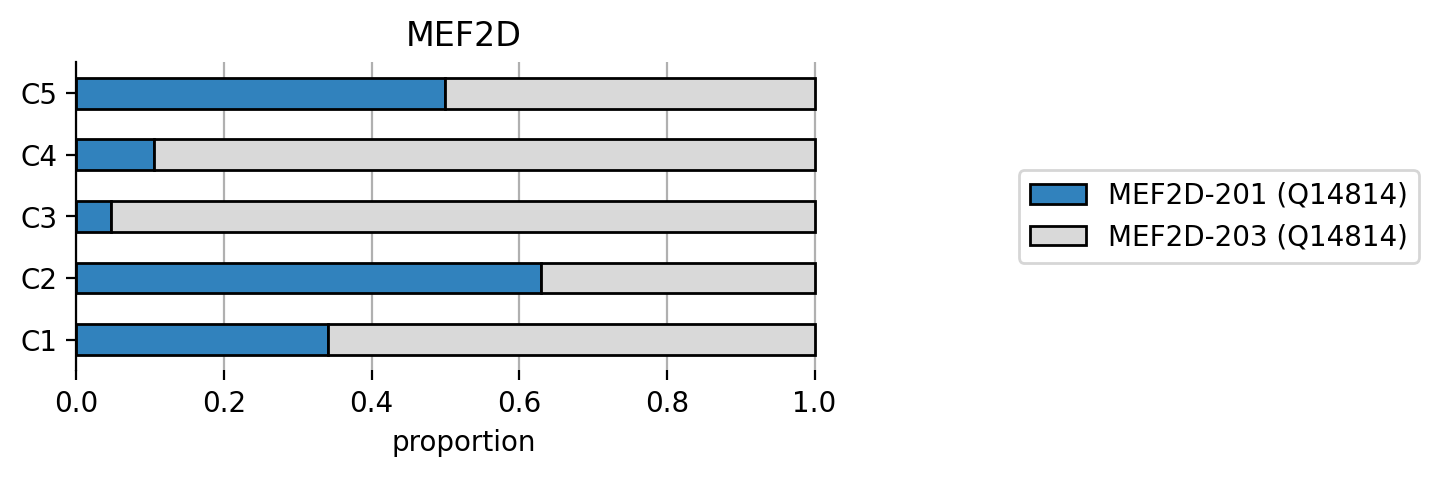

MELK


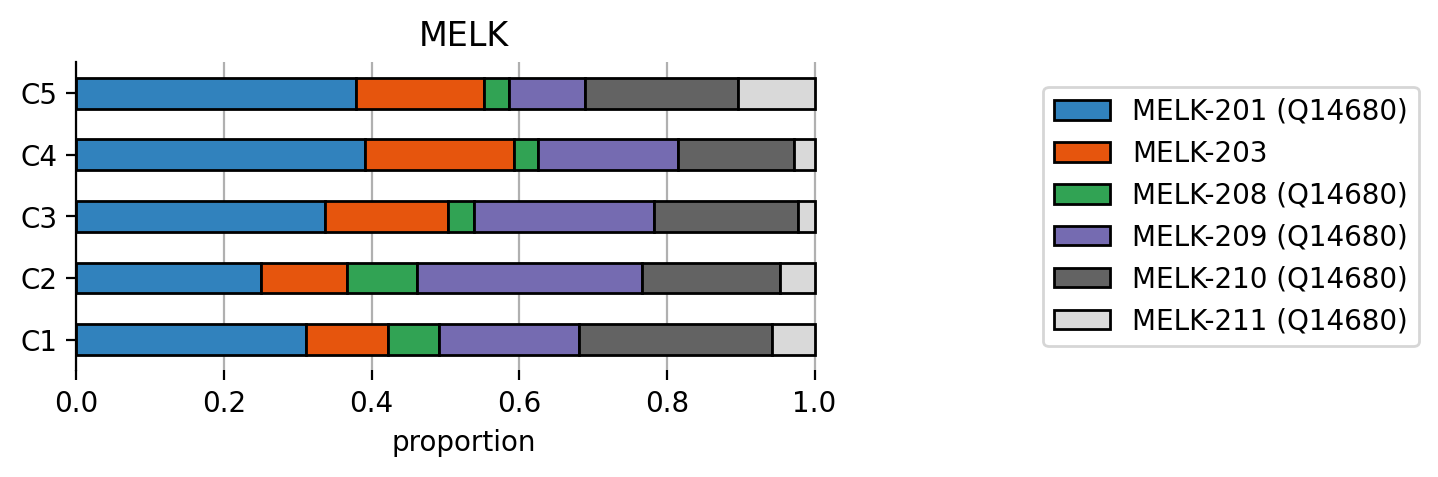

MSRB3


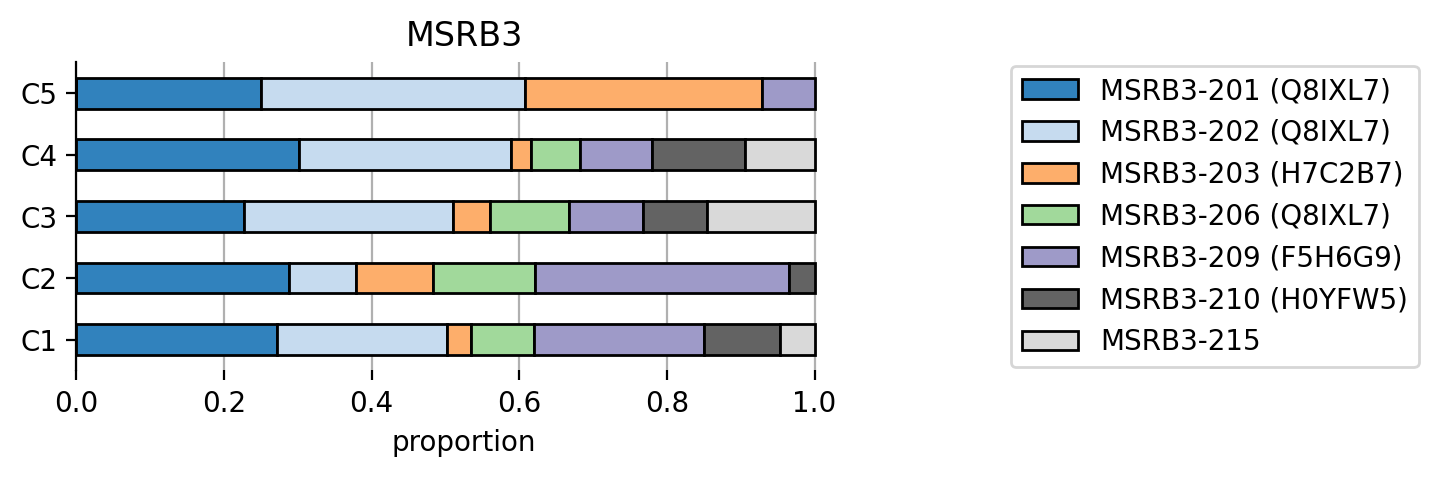

NCOA1


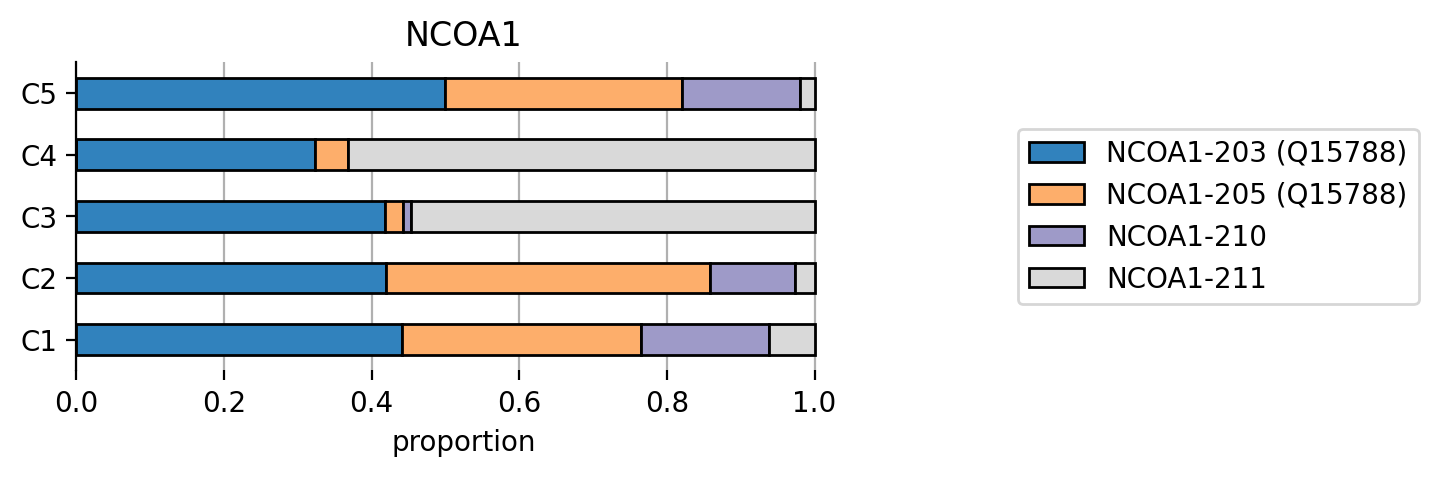

NR4A1


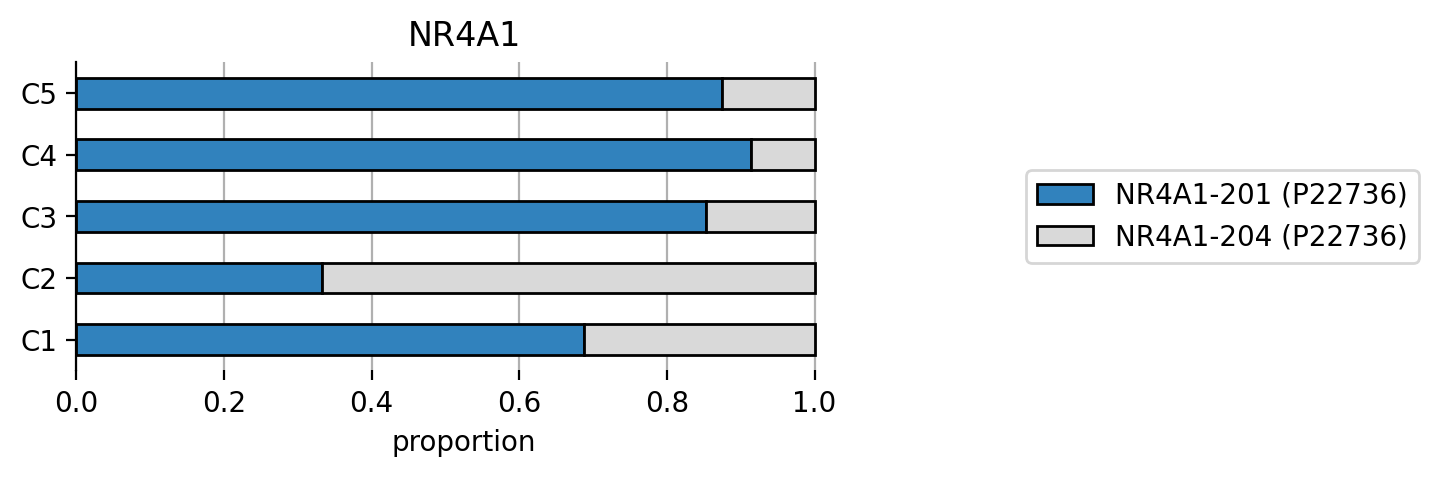

RAB18


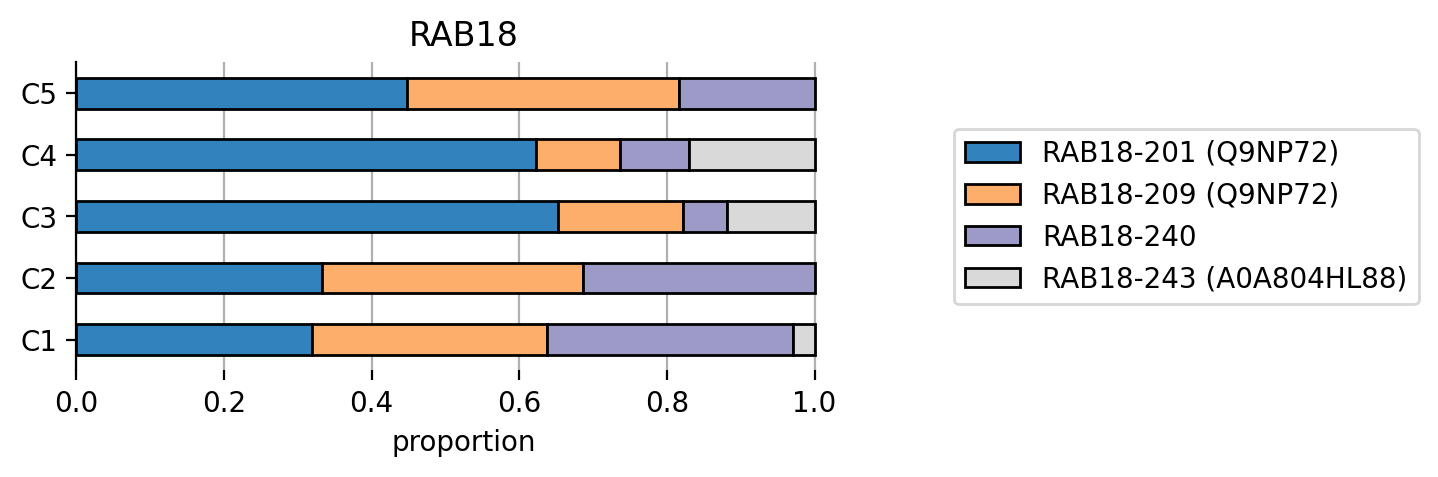

TRIB2


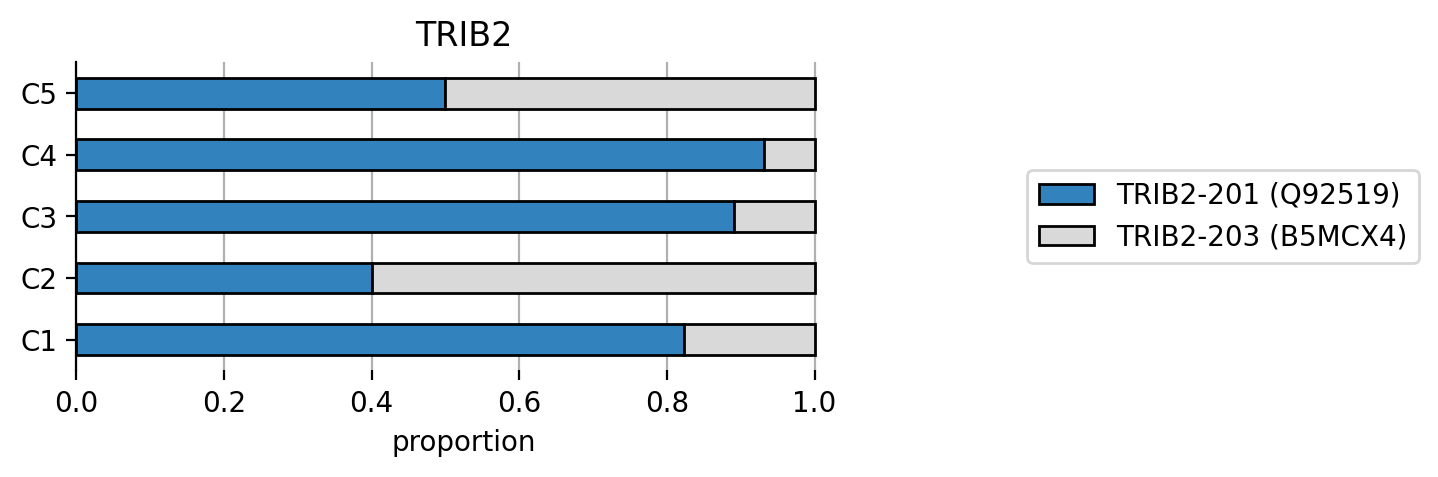

USP39


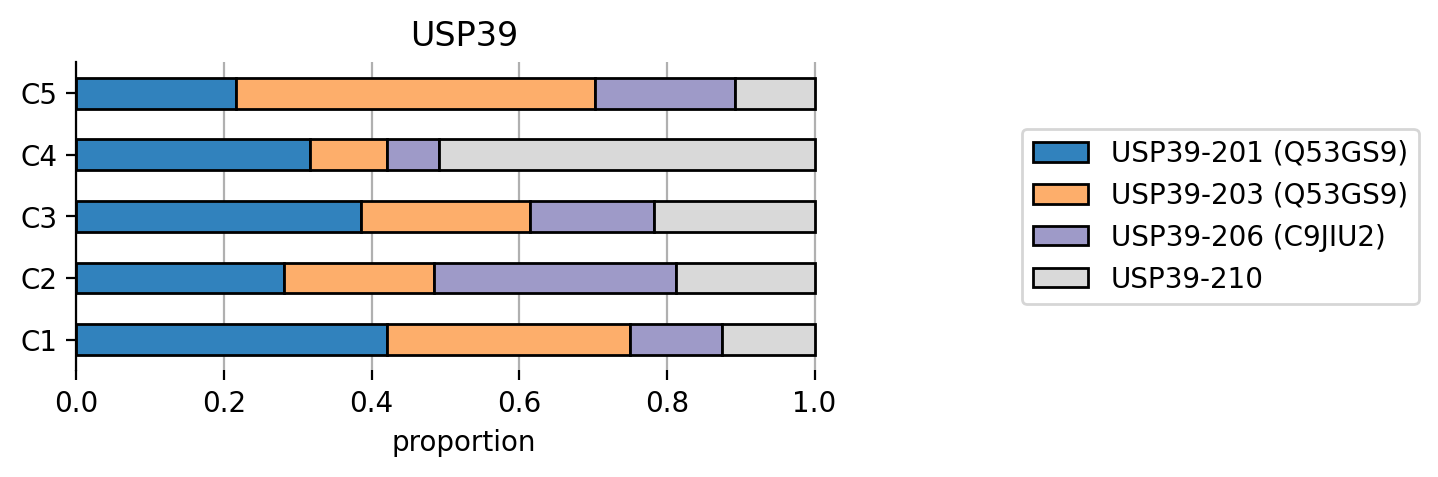

ZNF232


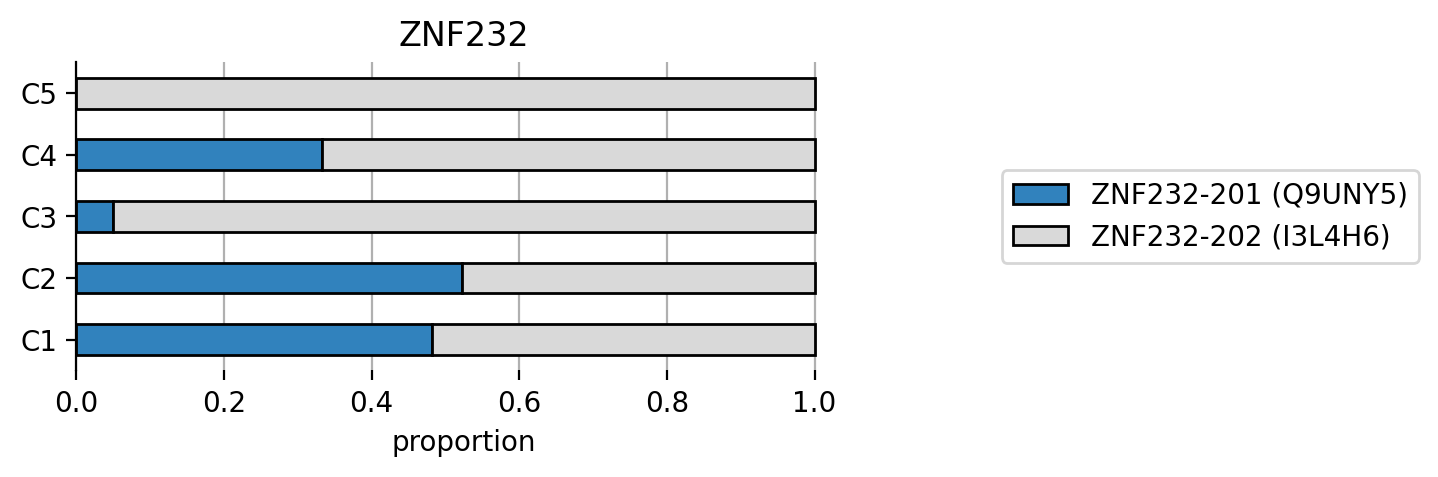

ZNF343


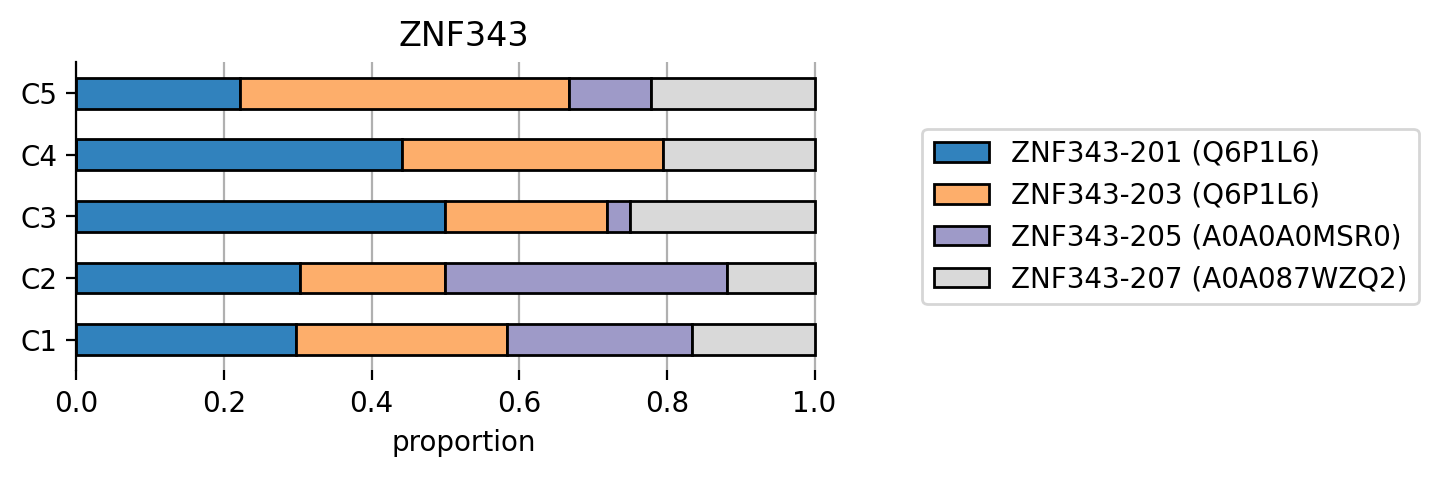

ZNF613


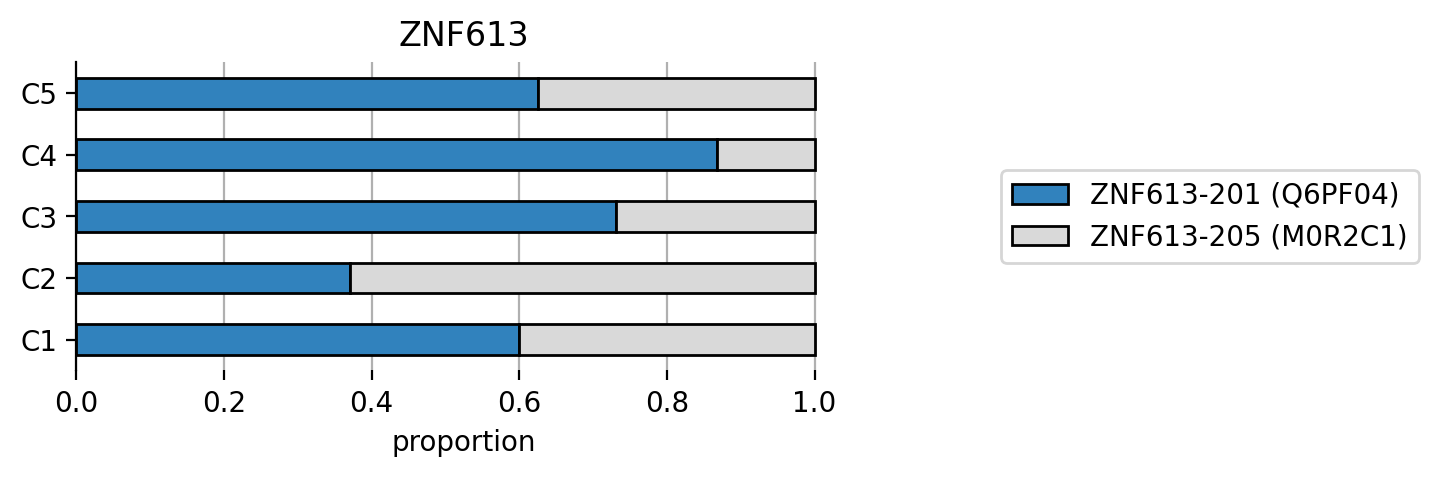

ZNF682


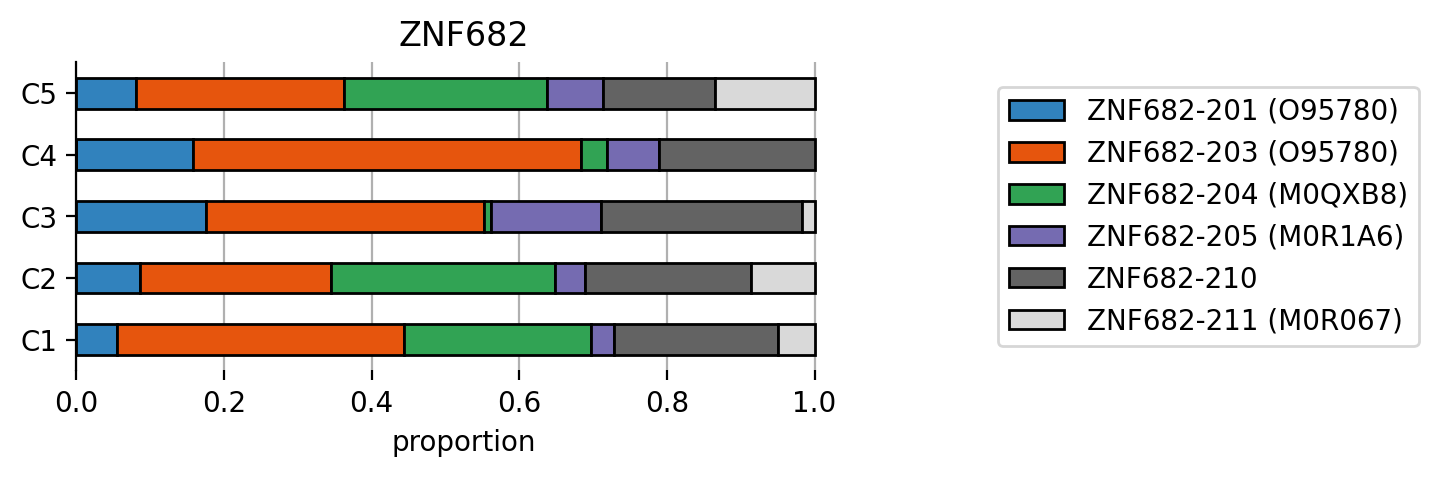

ZNF700


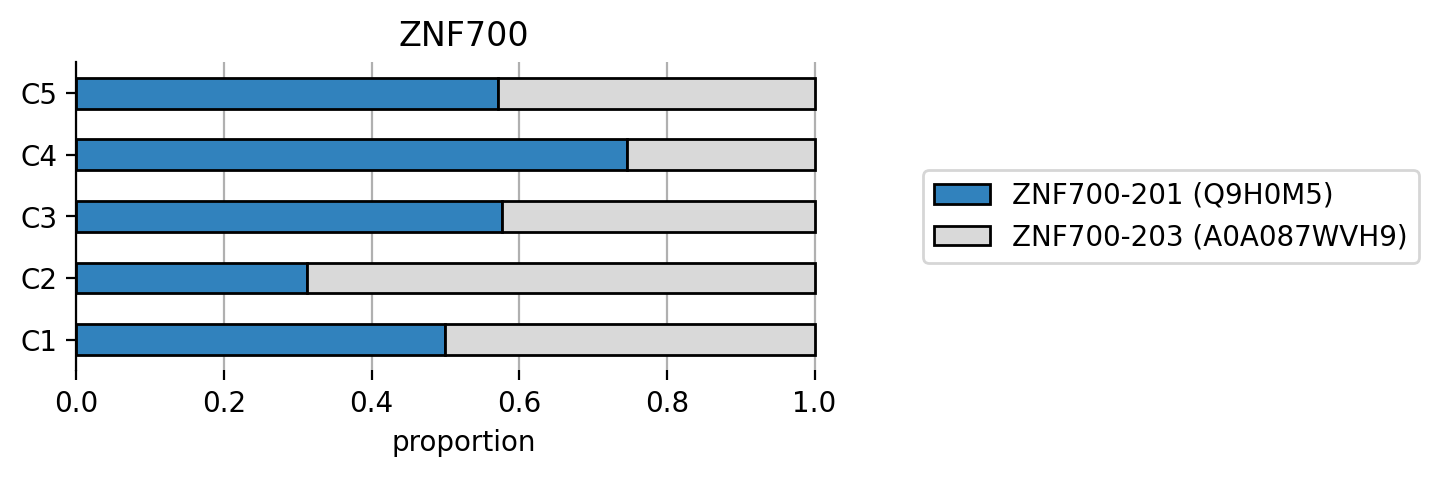

ZNF780A


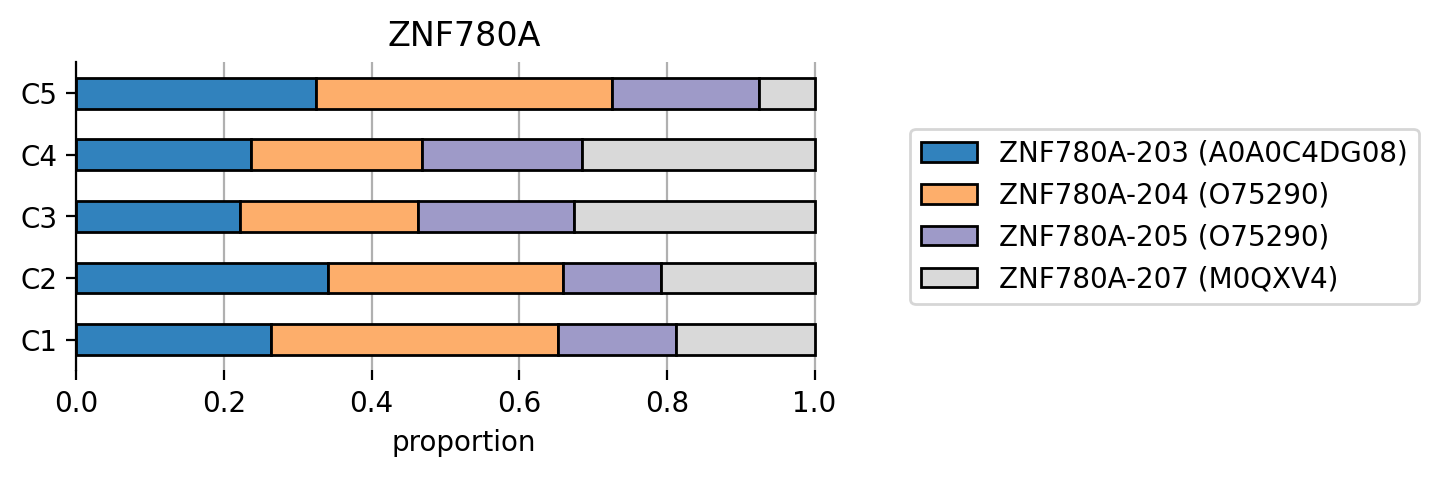

ZNF821


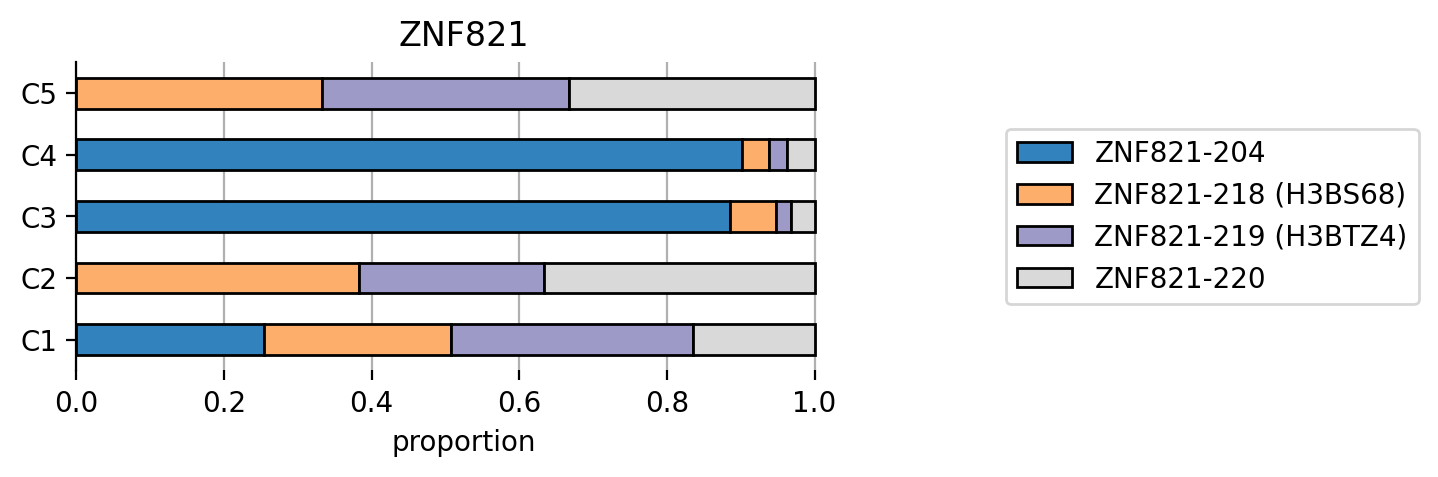

ZSCAN2


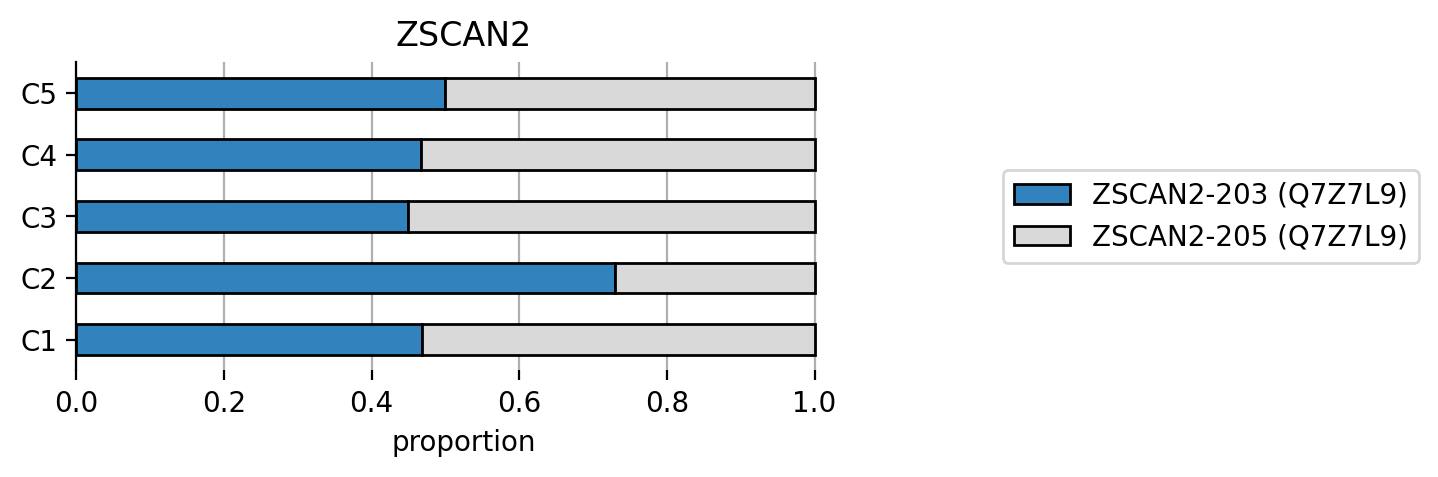

ZSCAN26


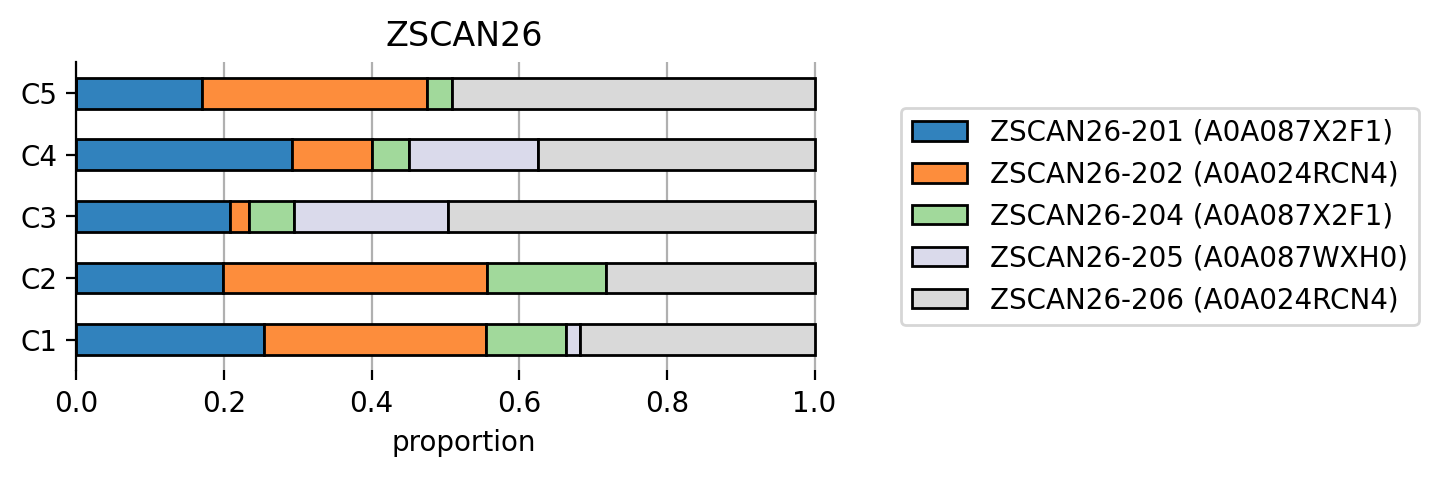

ASCC1


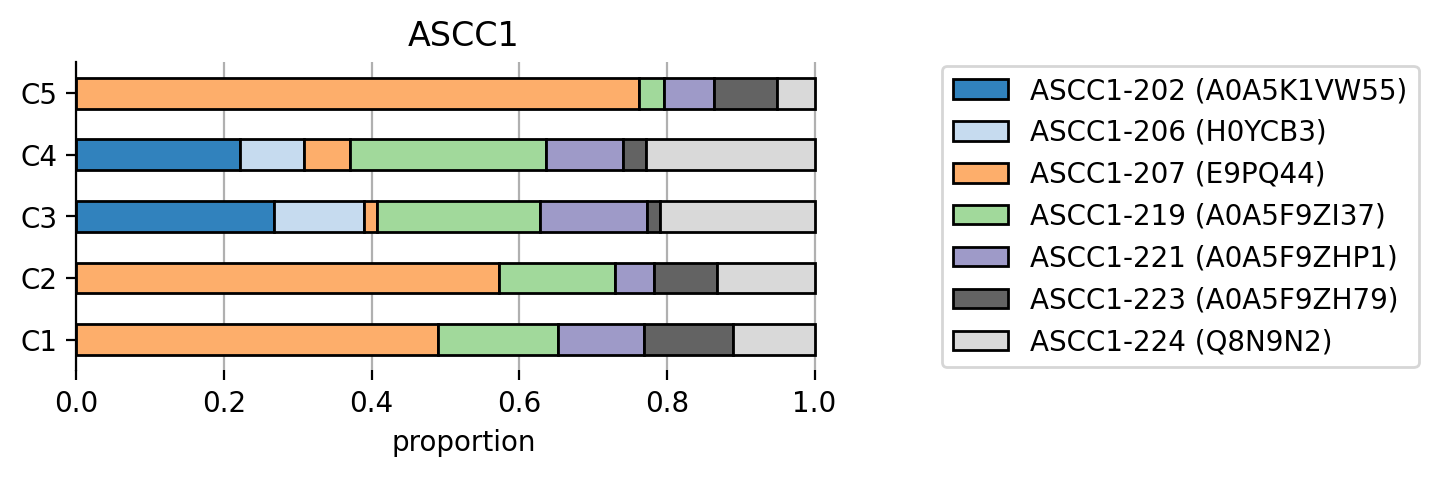

CLK1


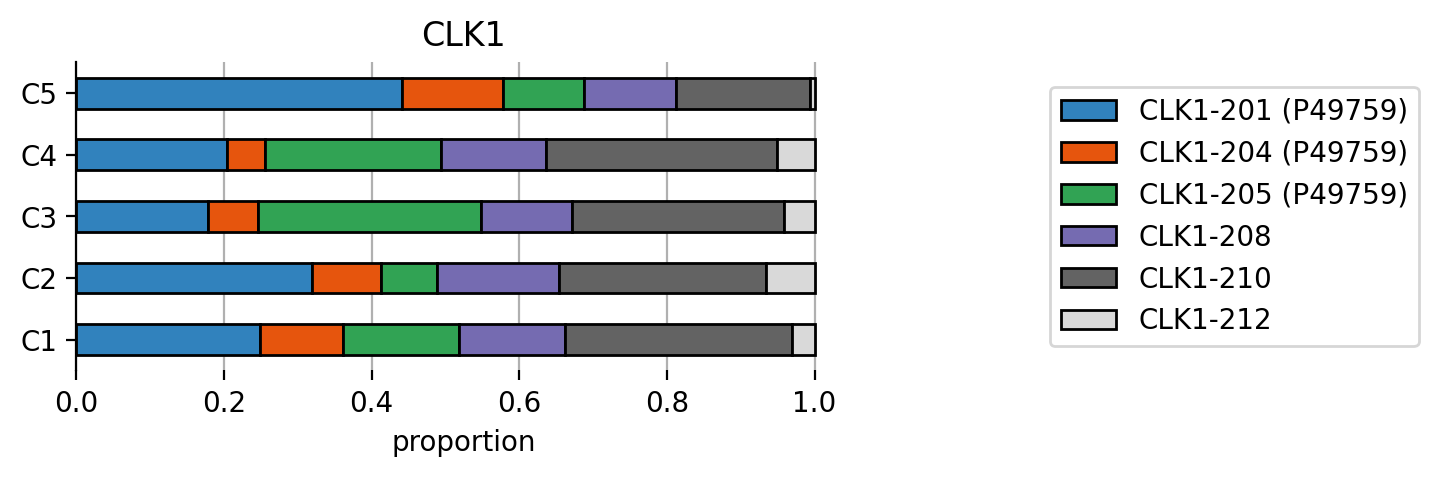

FOXP2


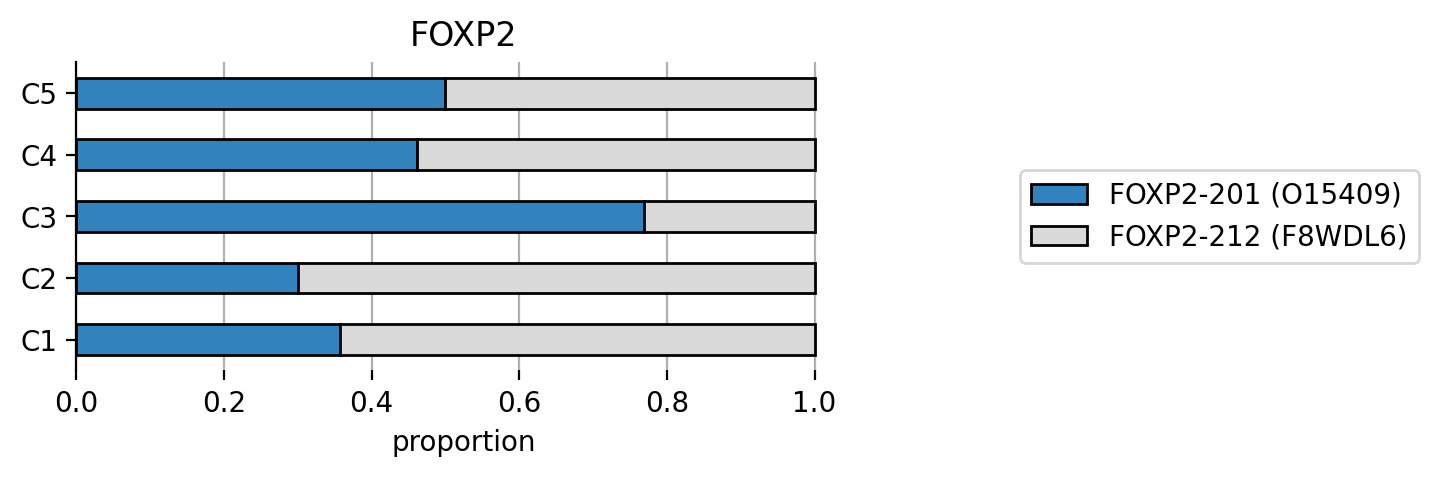

HDAC2


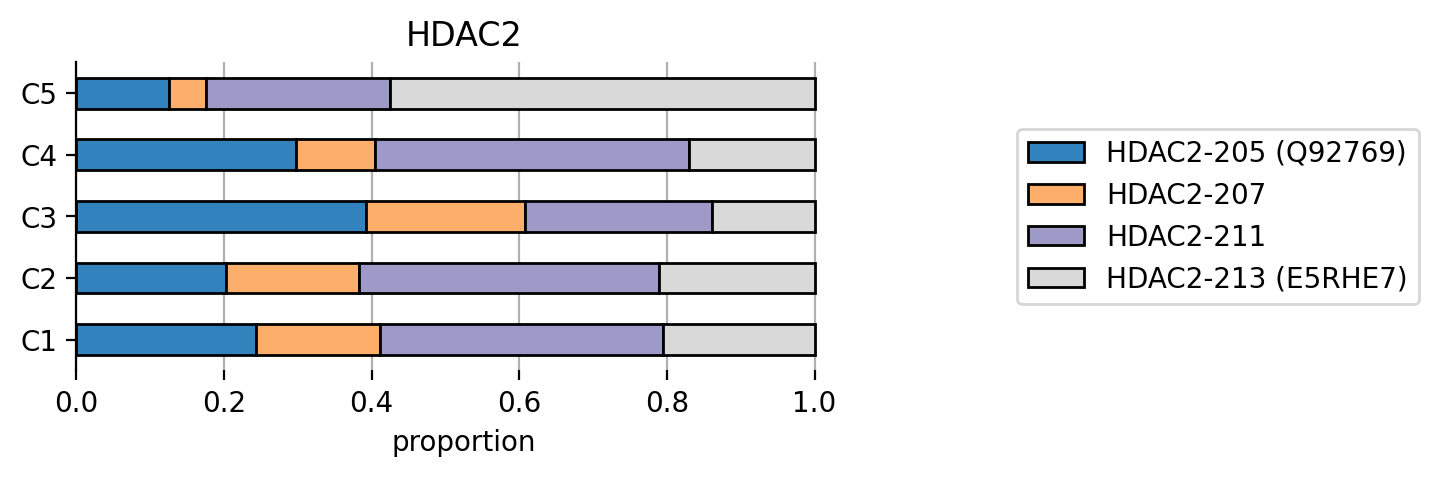

ING4


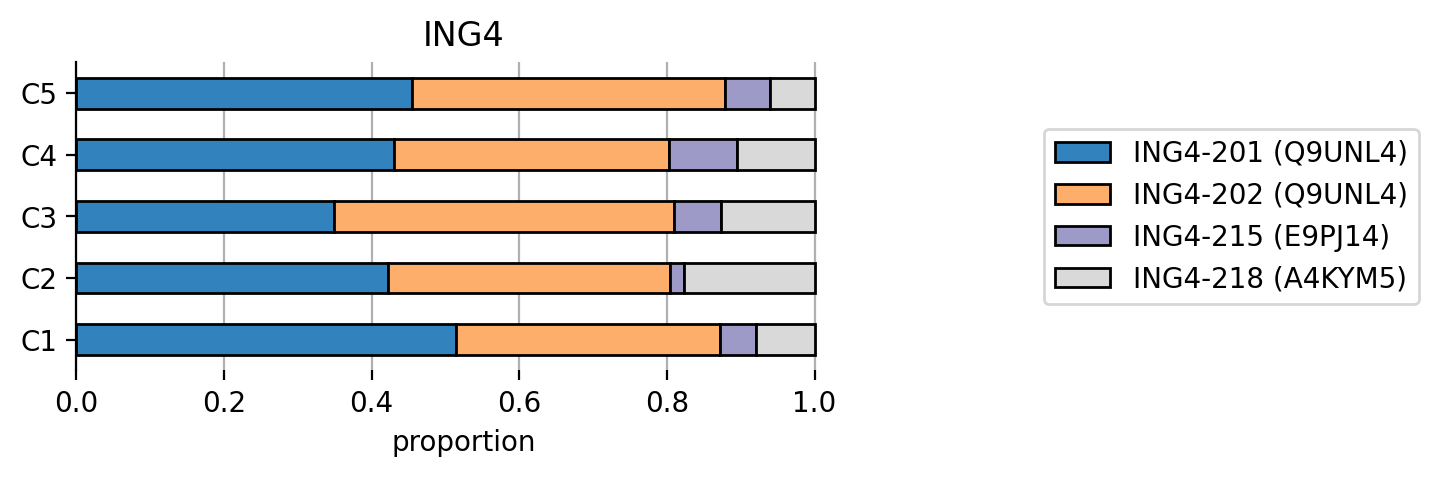

NCOR2


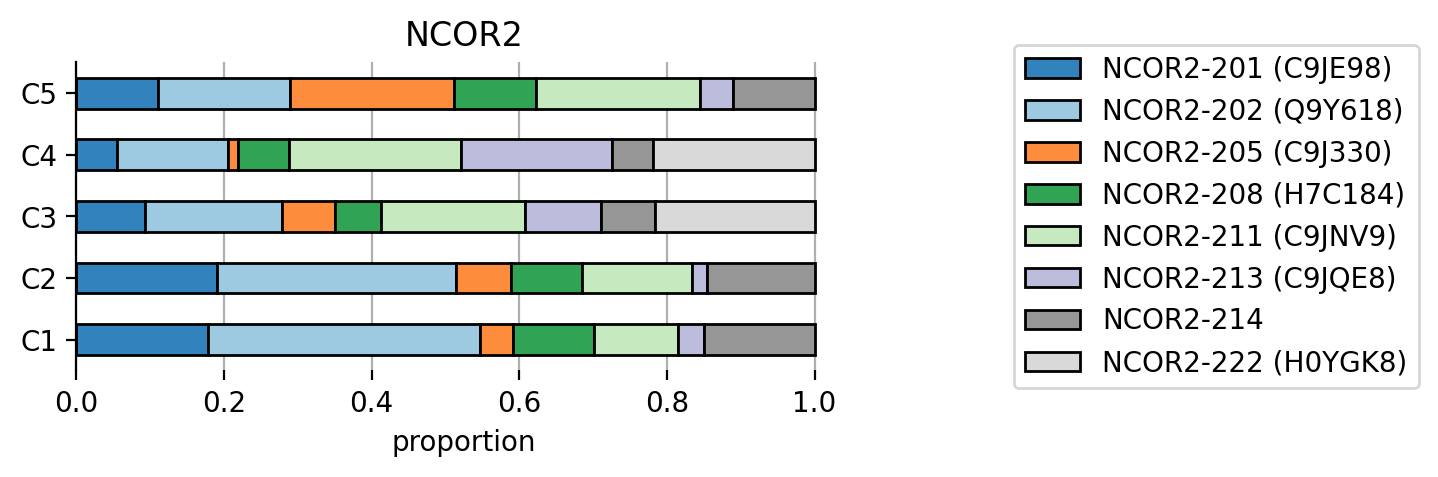

NFXL1


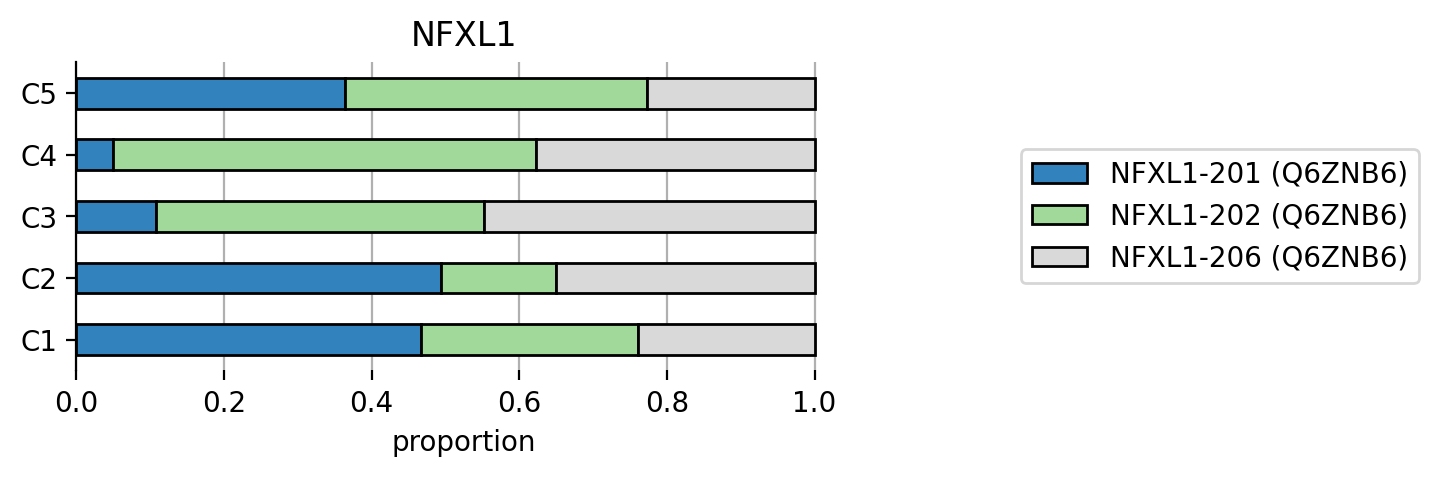

NOC2L


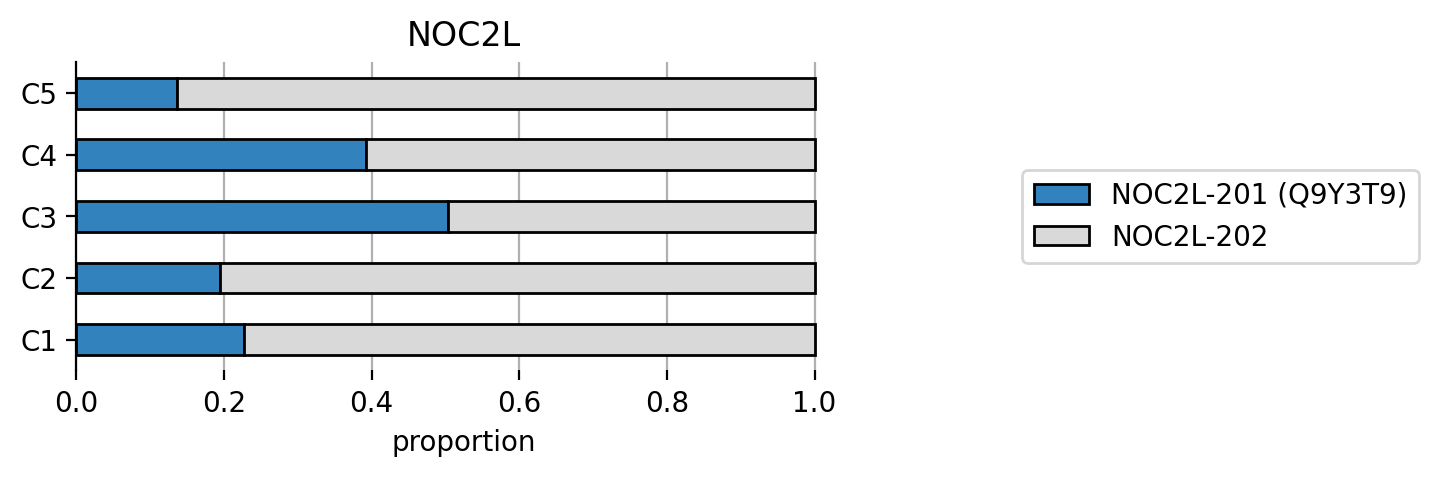

NR2C2


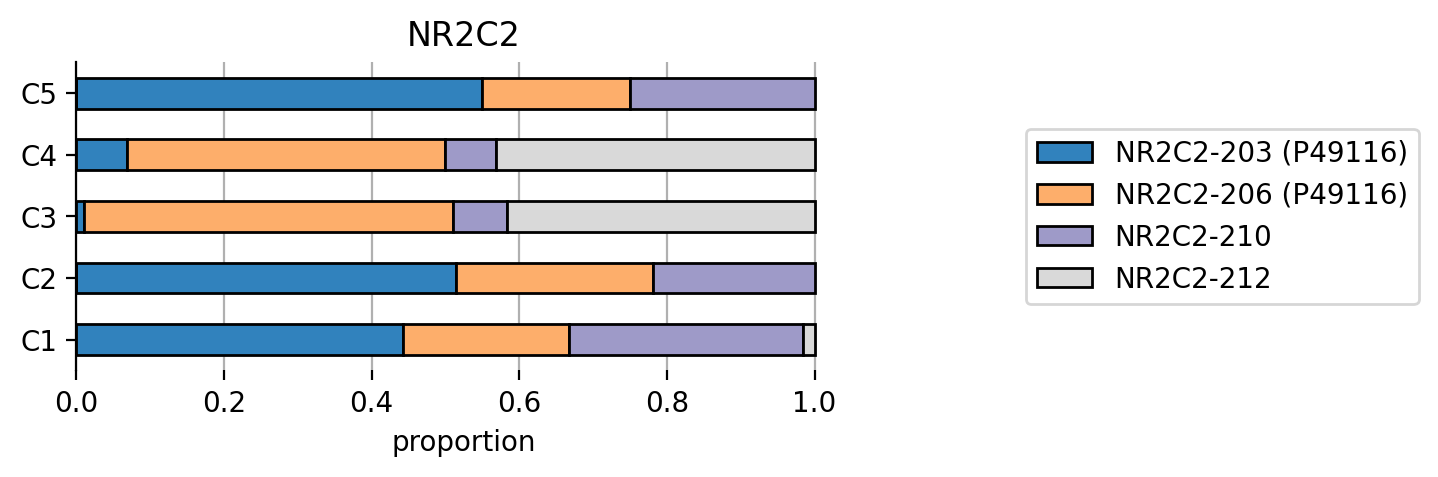

NR3C1


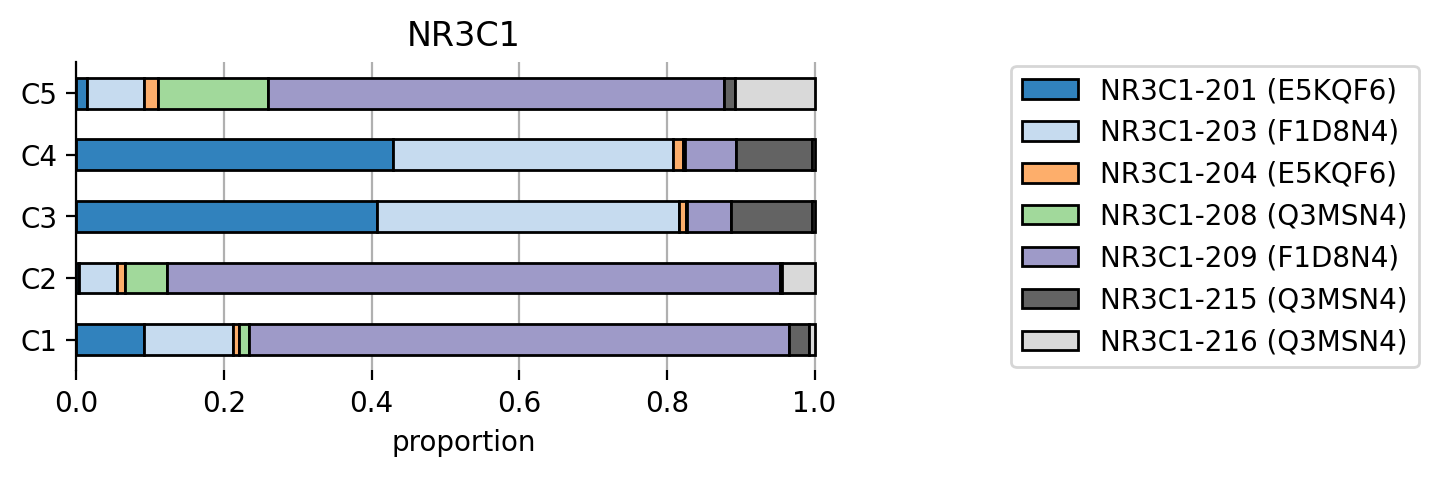

NRF1


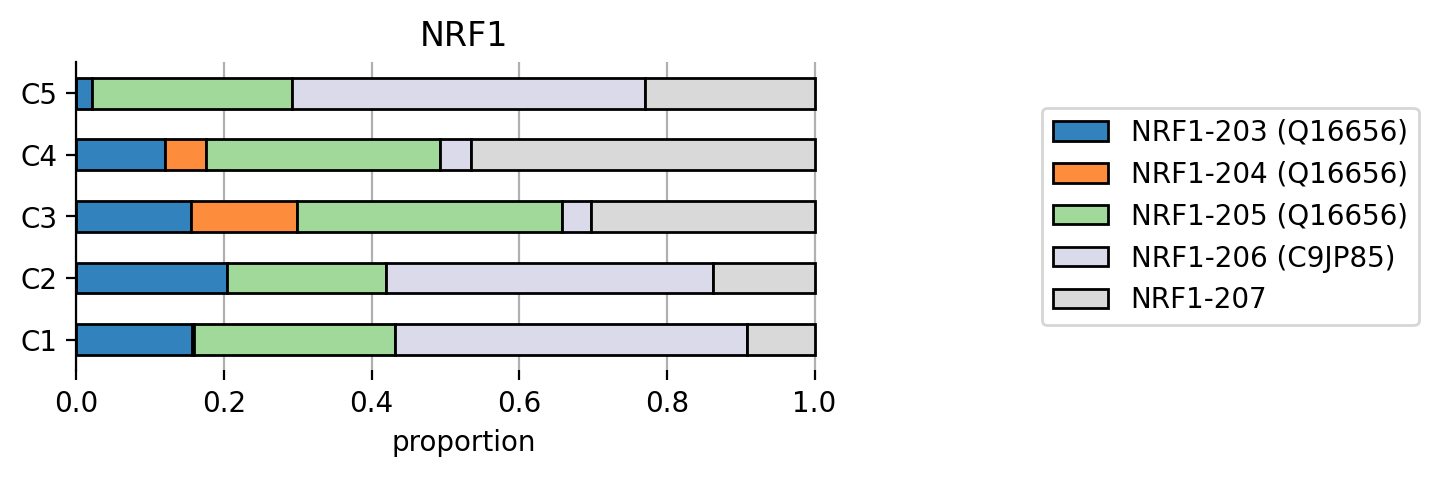

PAXIP1


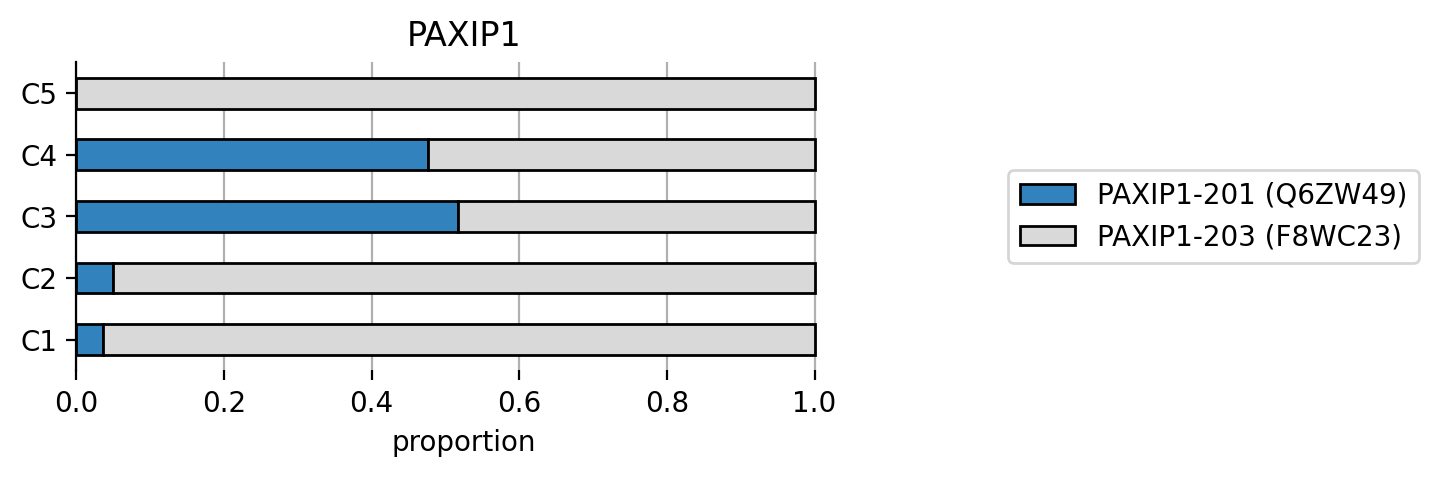

RBM7


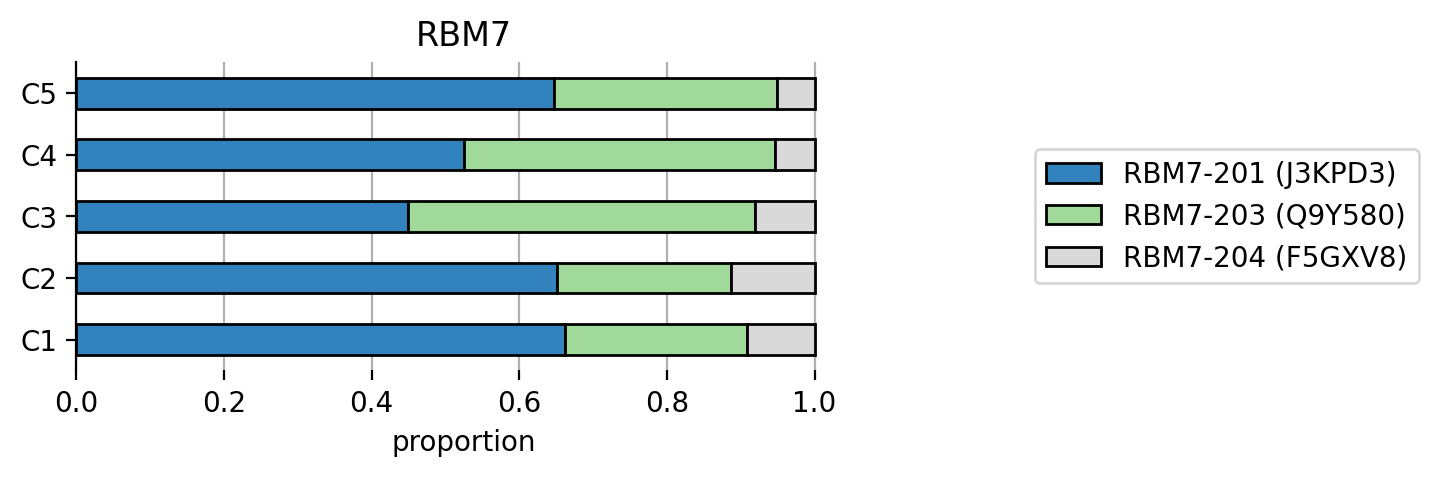

SIN3A


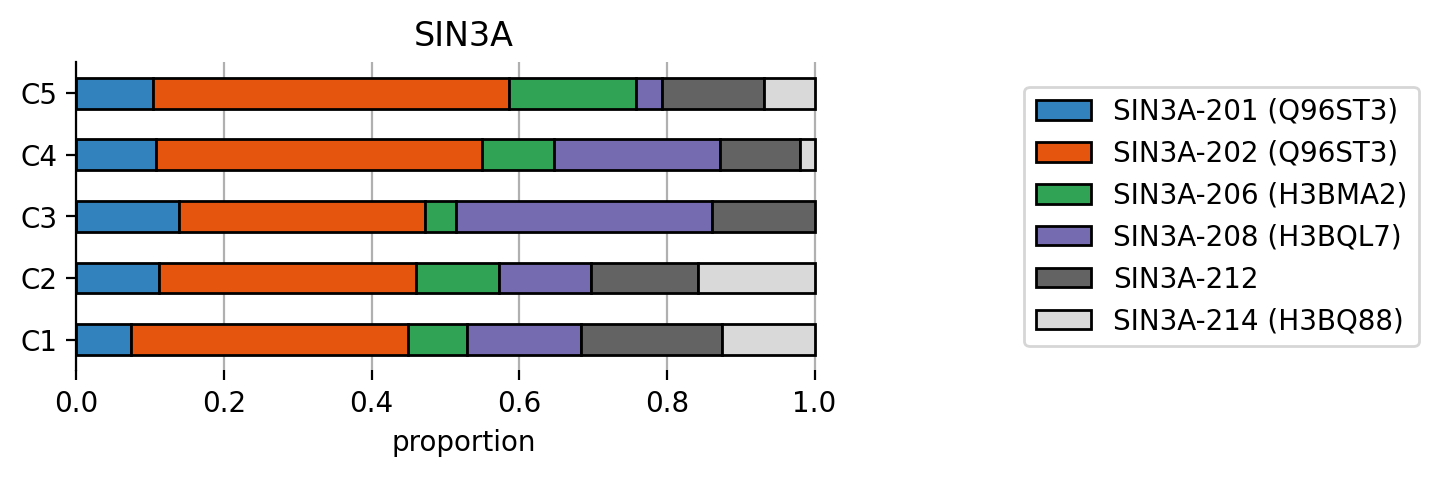

ZBTB4


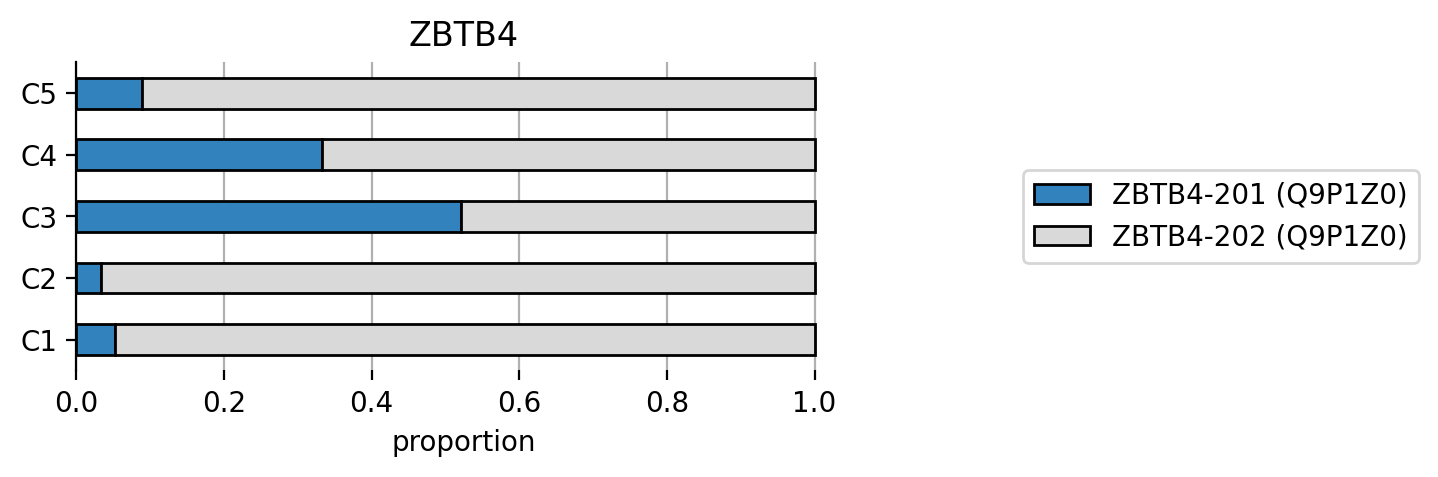

ZBTB48


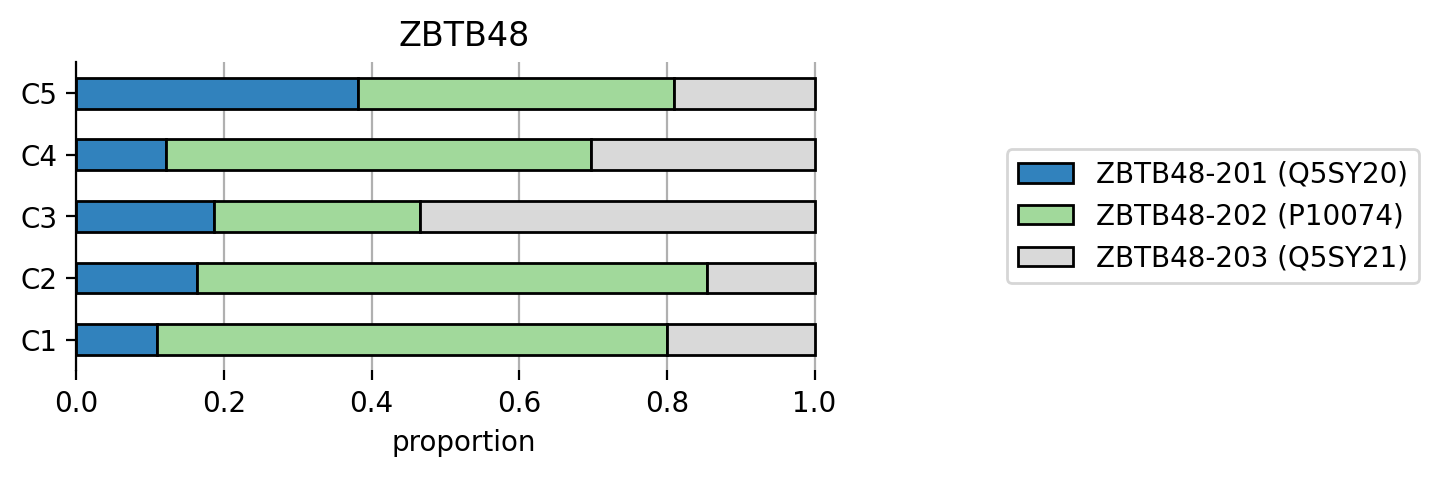

ZNF107


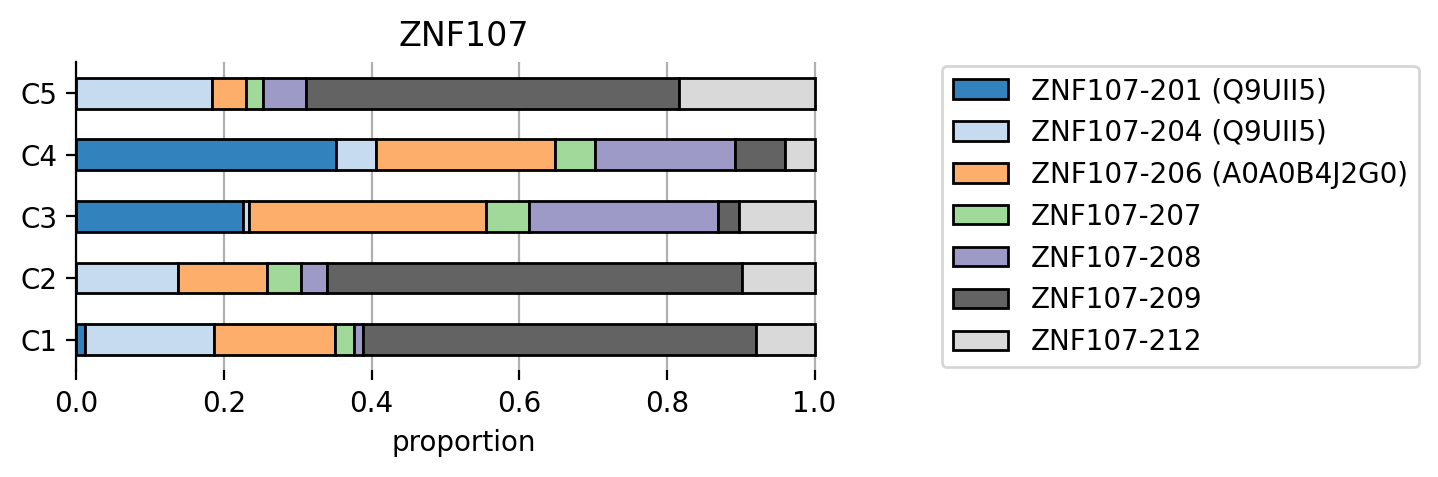

ZNF155


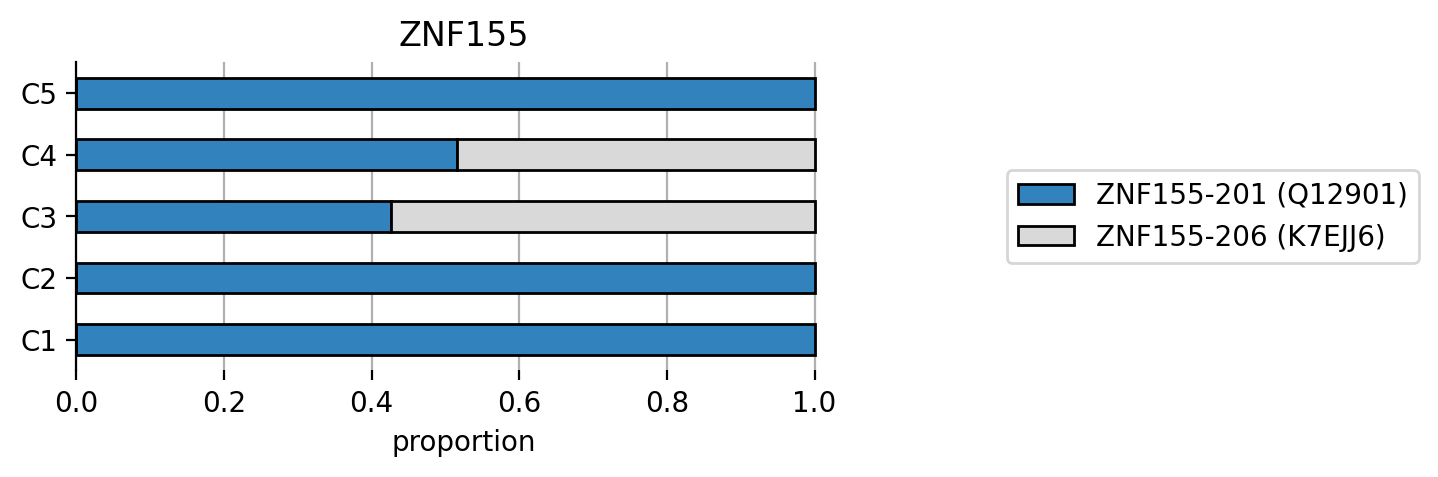

ZNF195


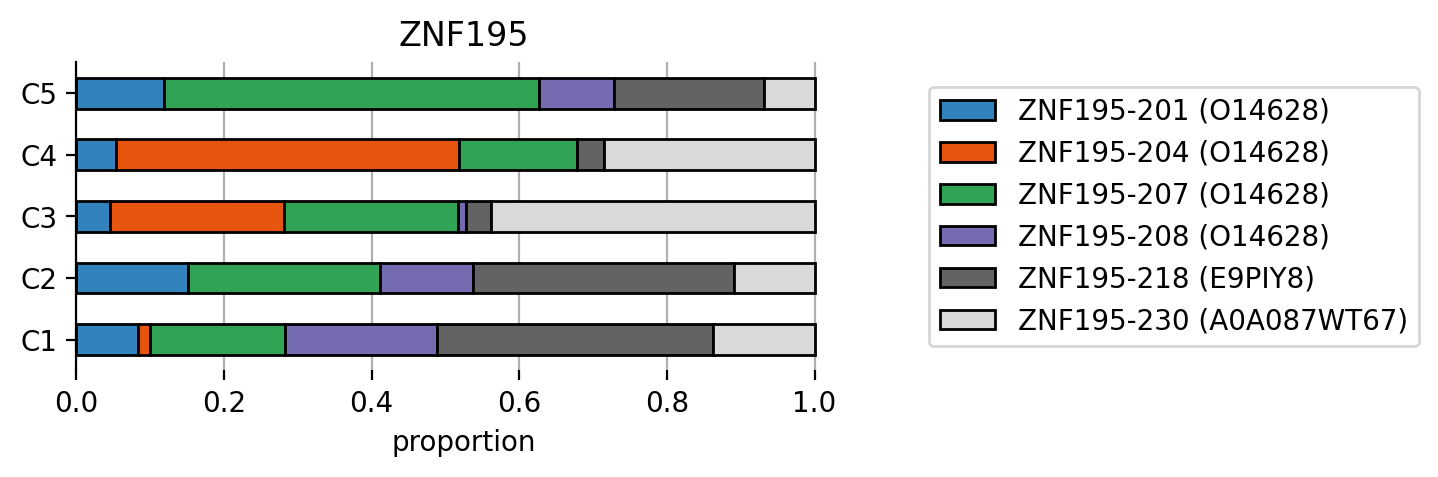

ZNF239


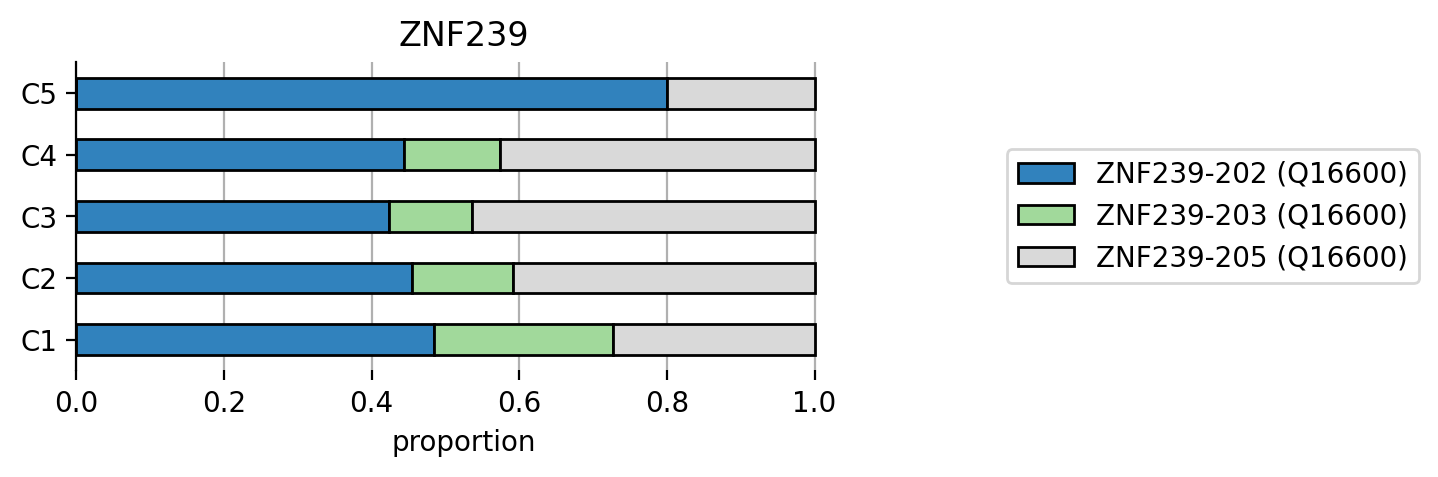

ZNF254


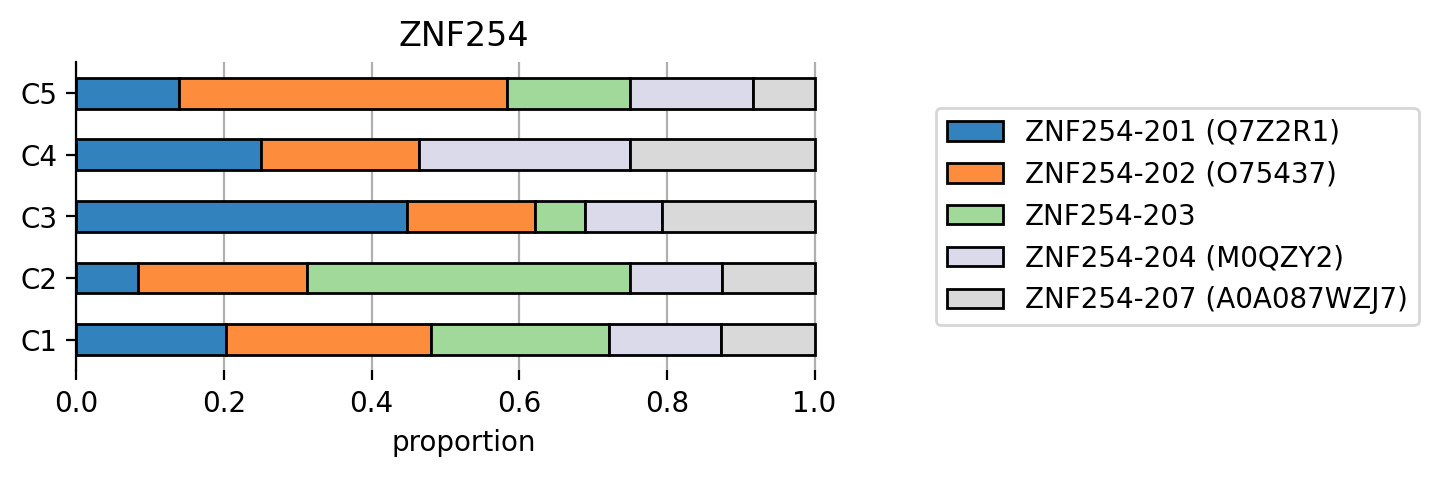

ZNF286A


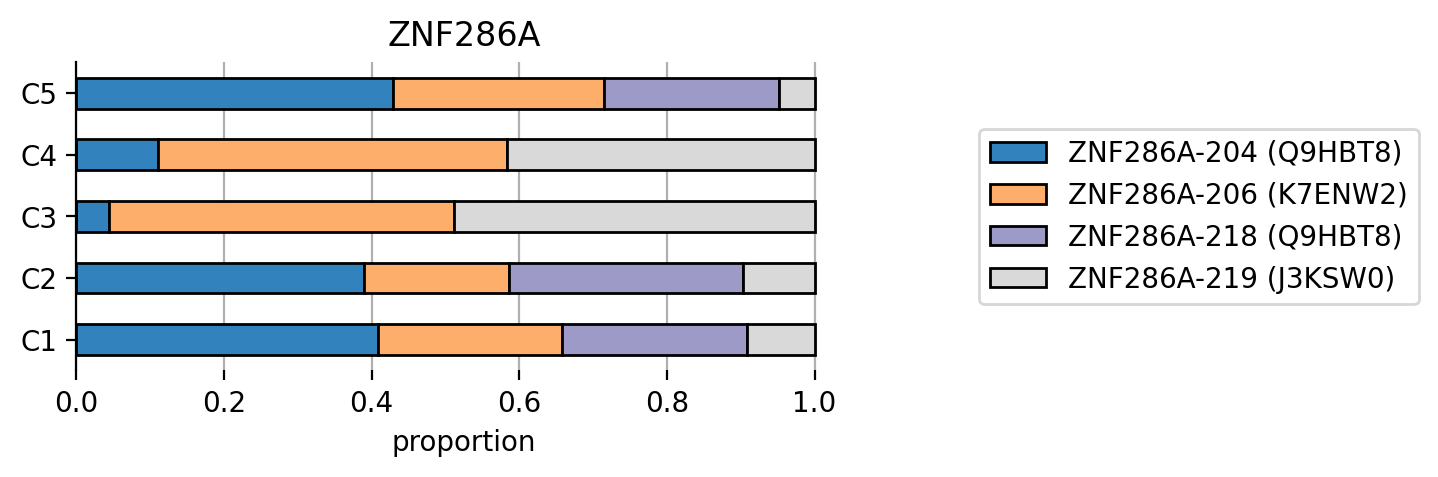

ZNF302


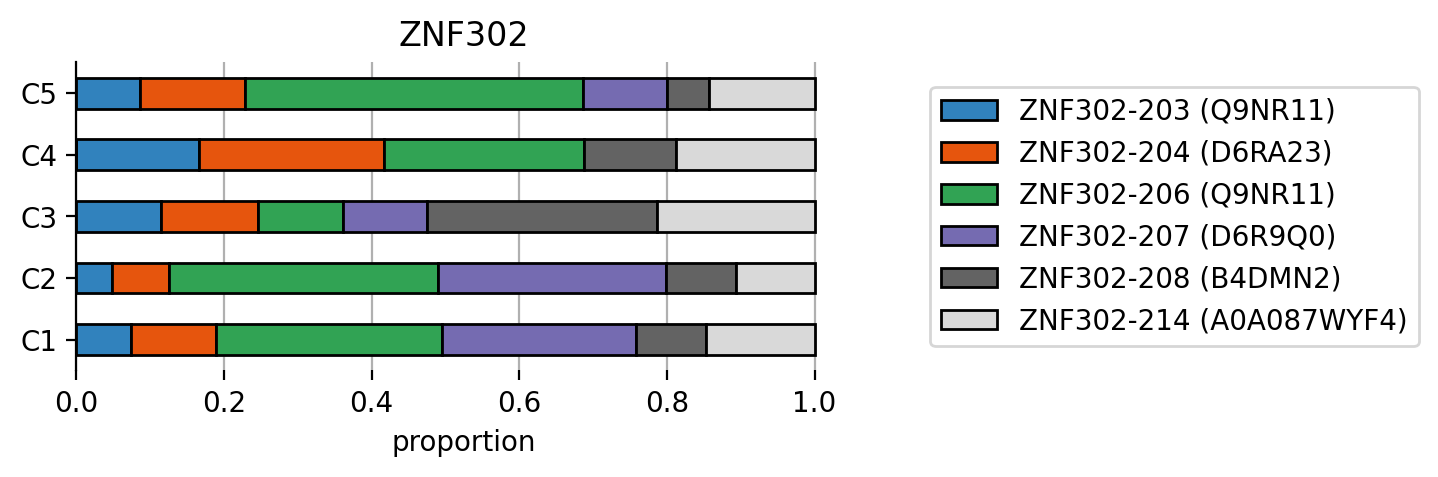

ZNF410


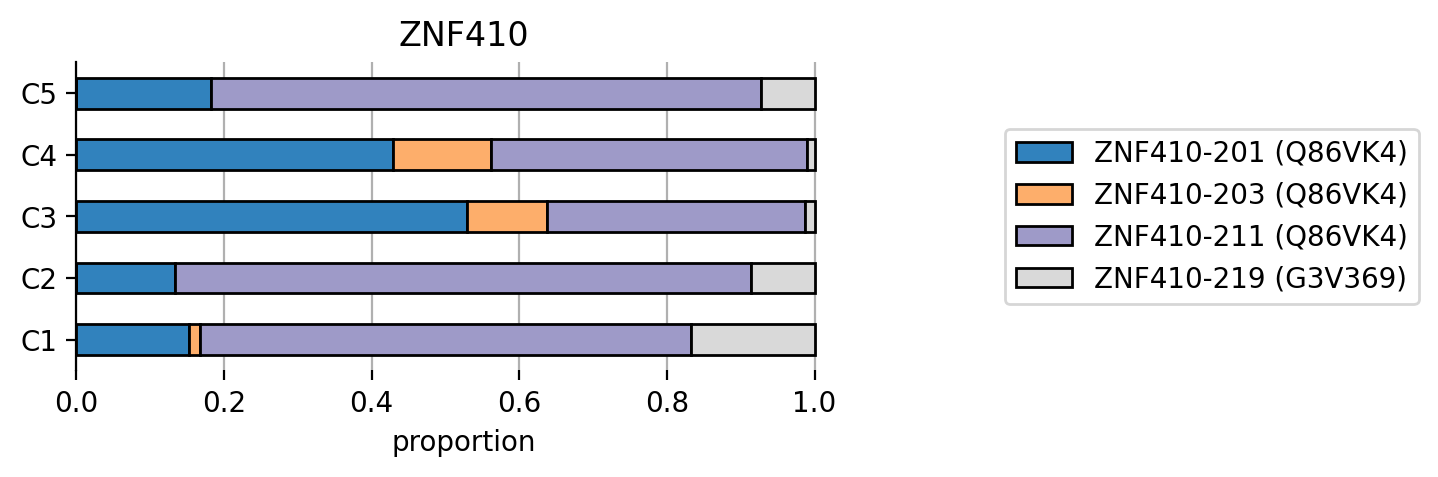

ZNF586


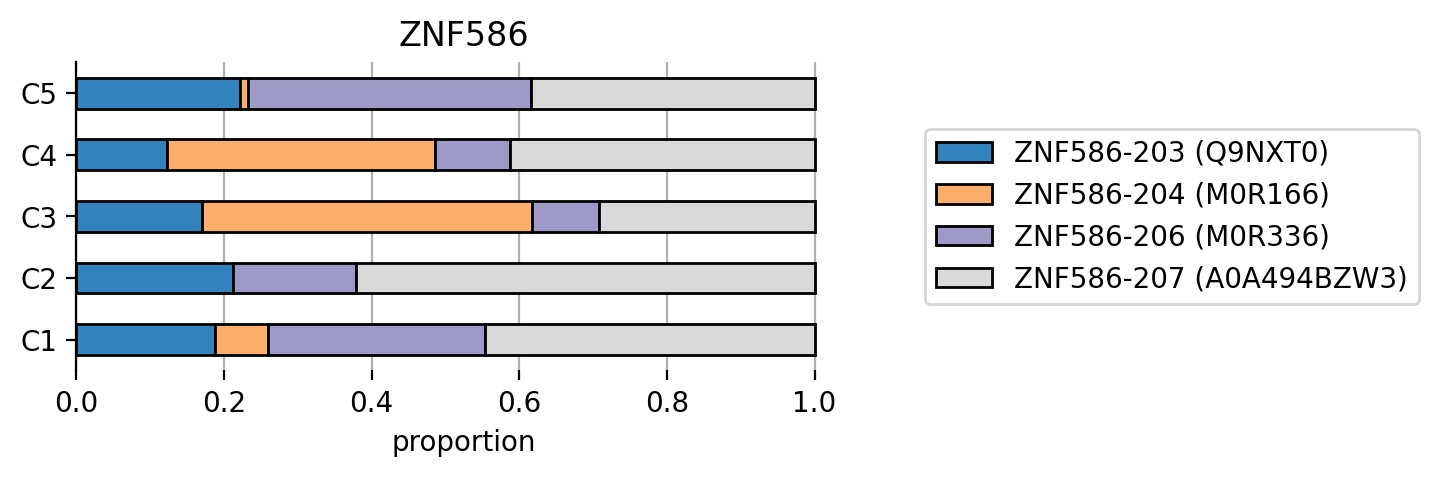

ZNF589


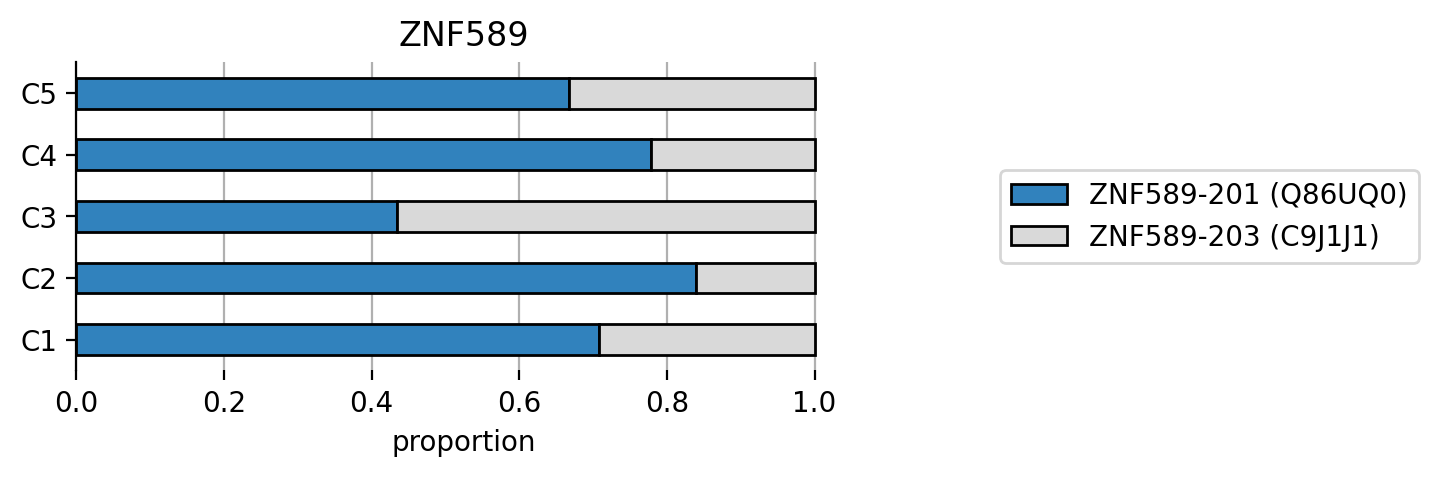

ZNF644


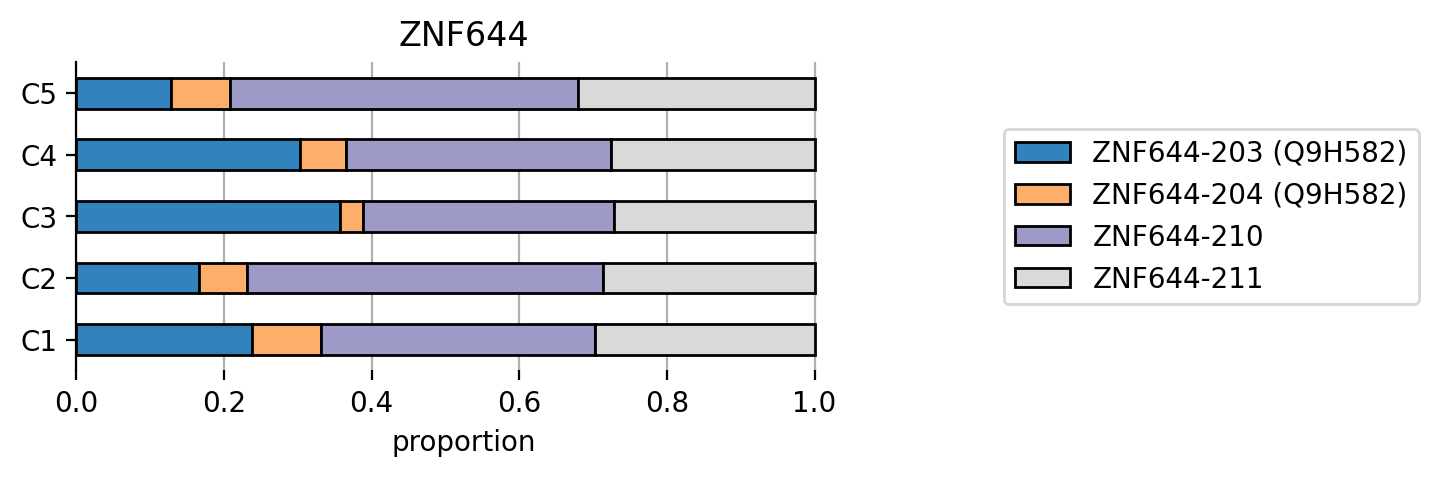

ZNF653


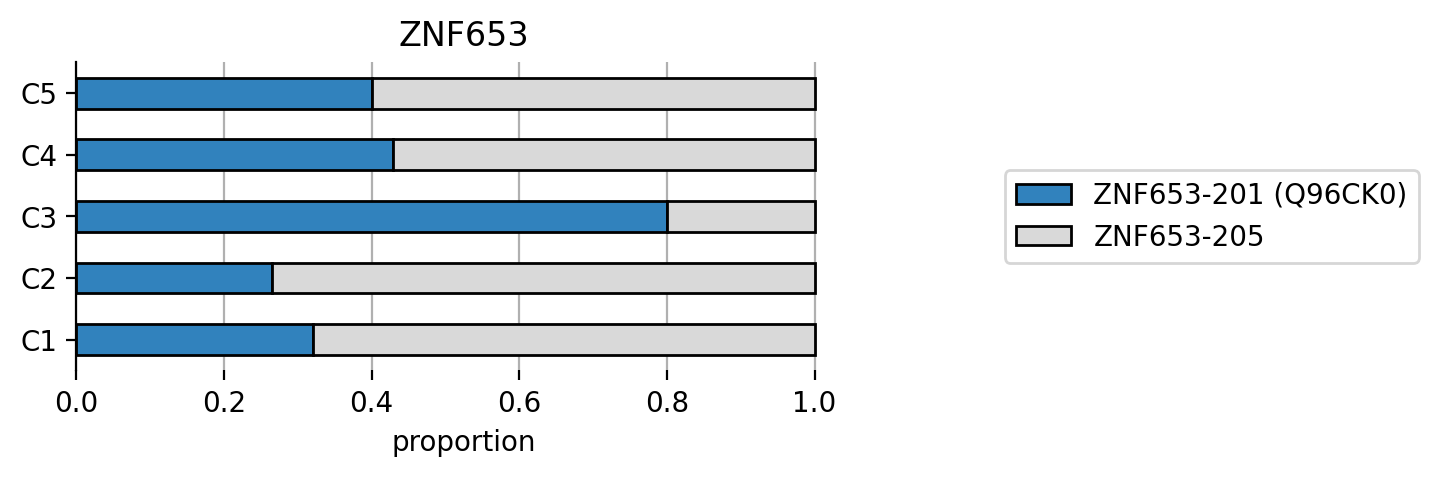

ZNF701


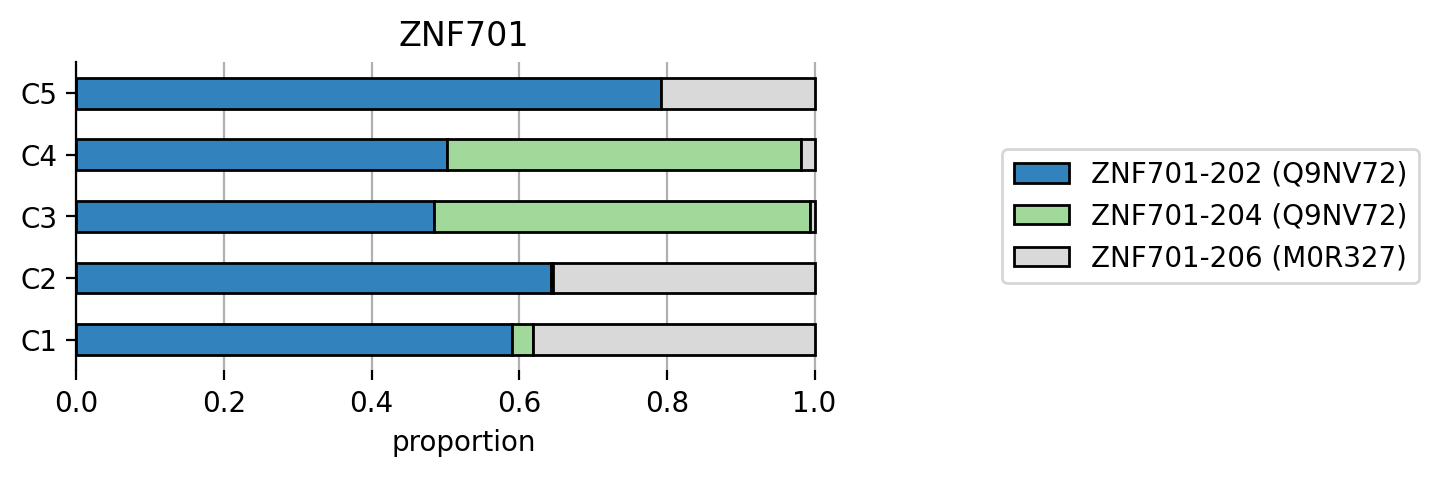

ZNF786


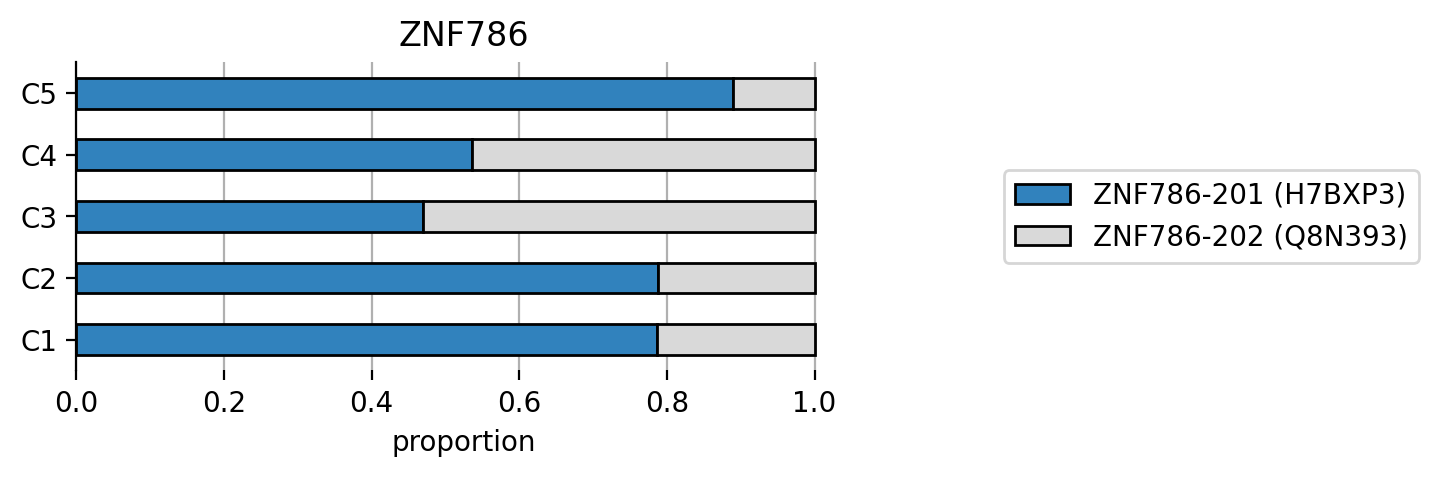

ADARB1


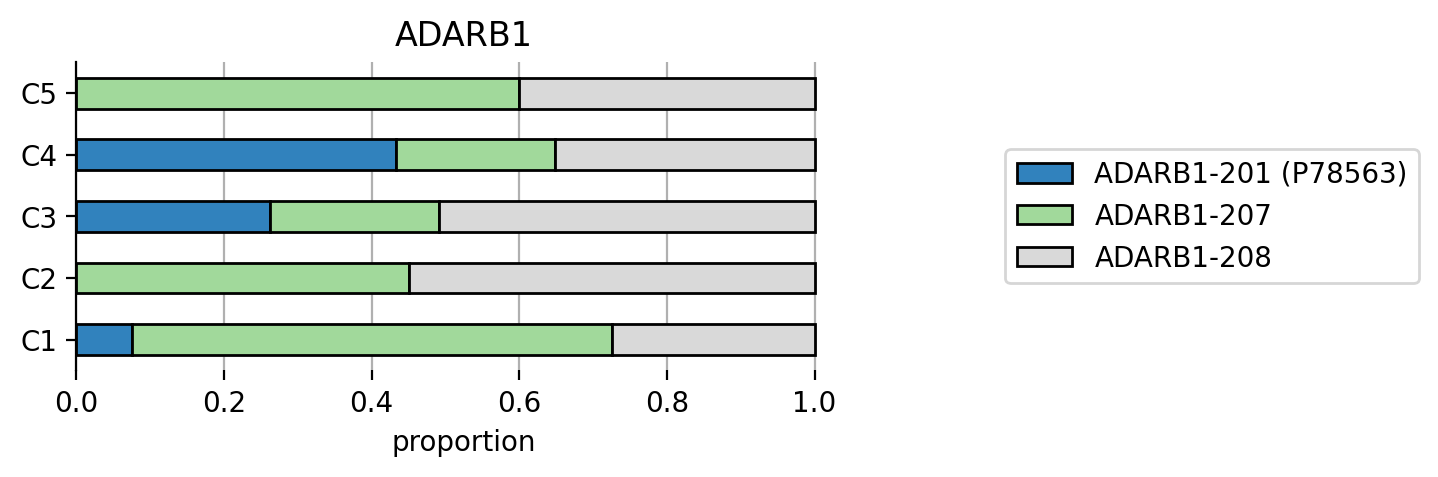

CREM


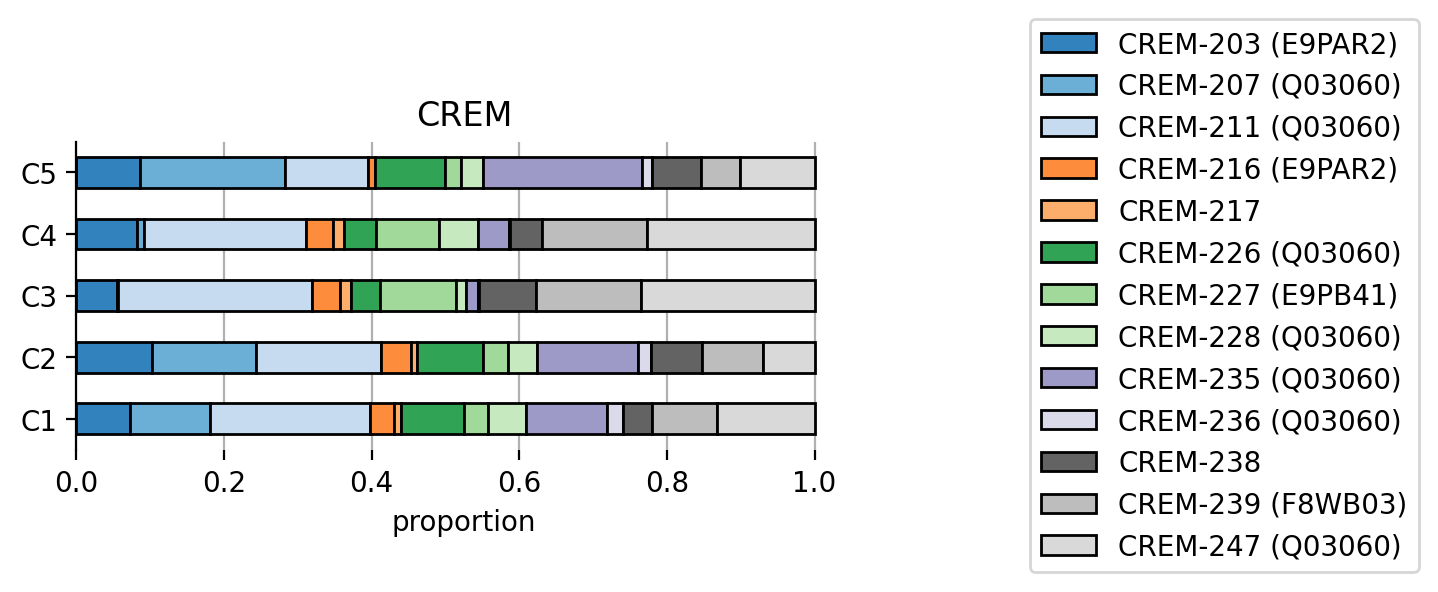

DNAJC21


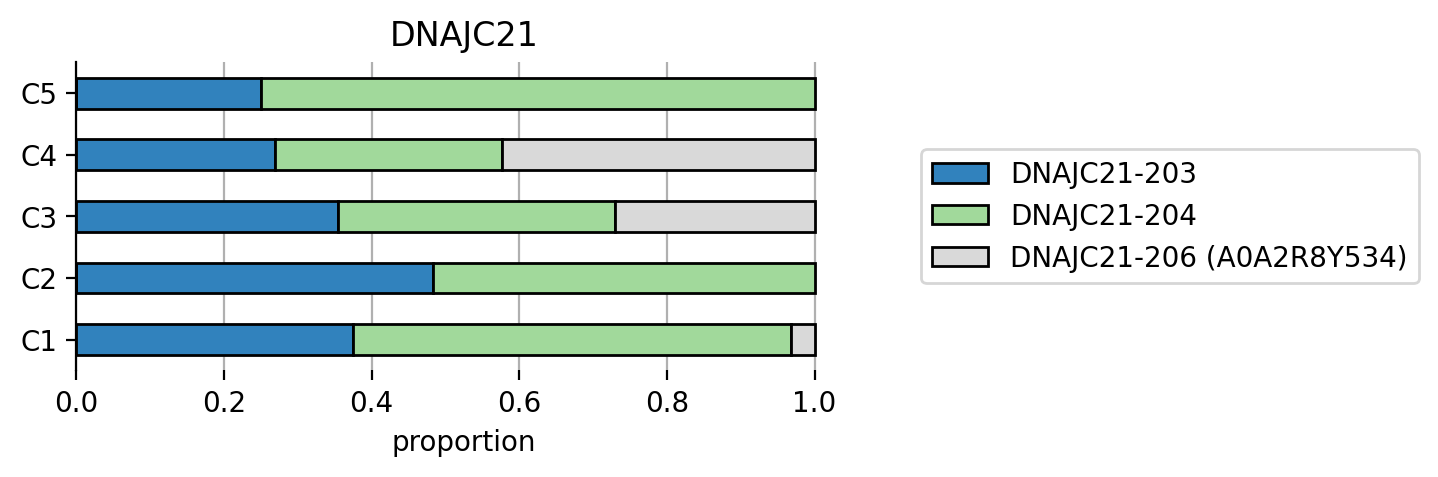

FIZ1


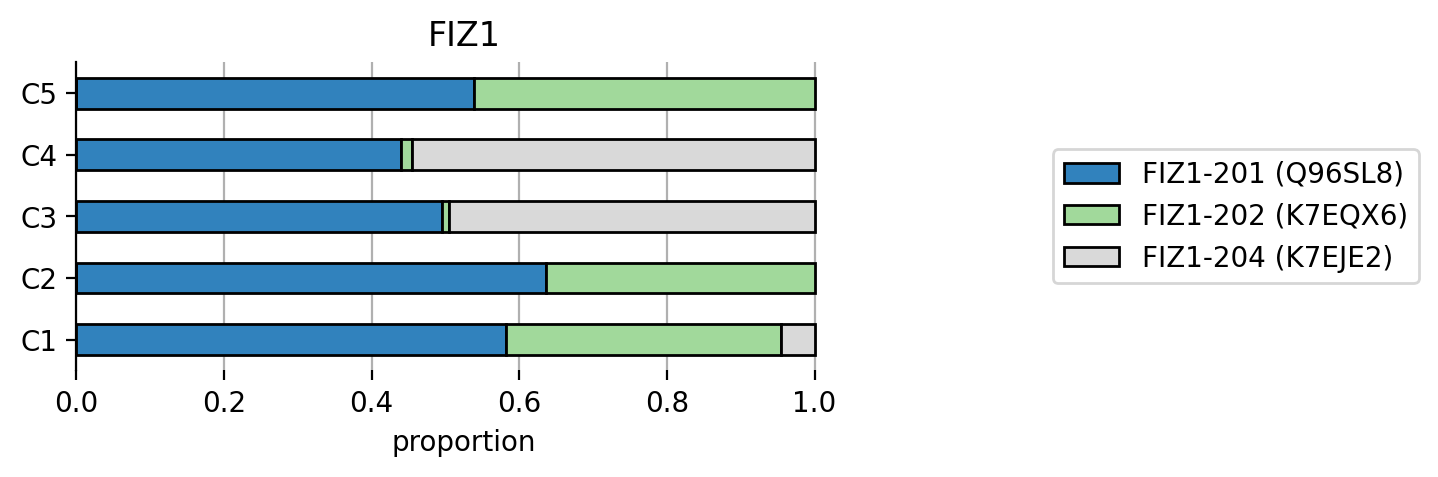

GABPB1


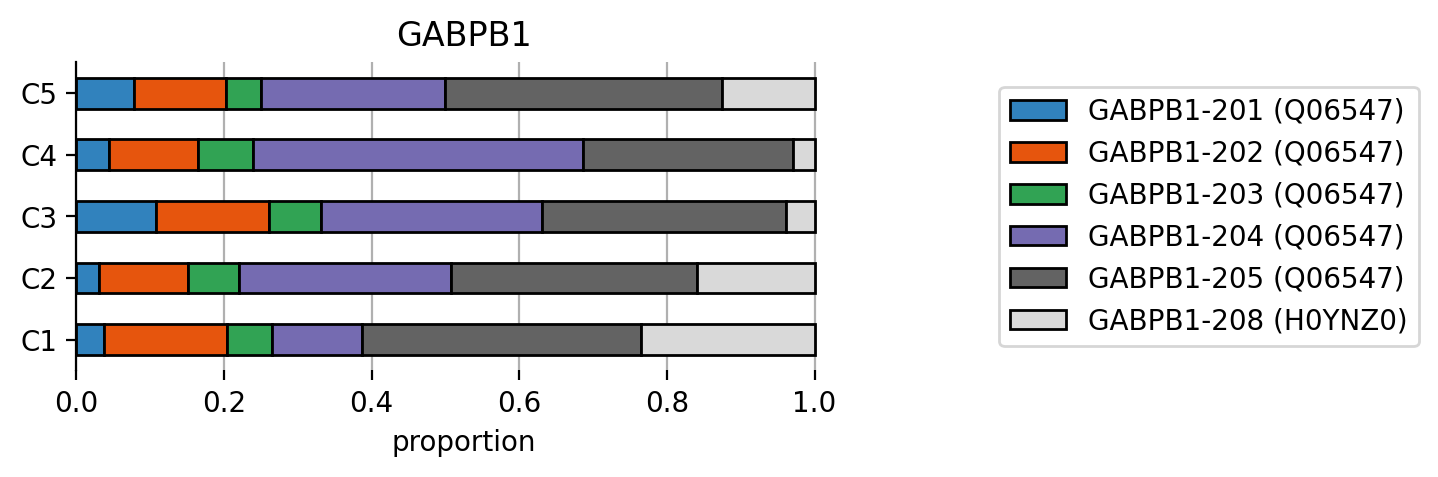

NR1H3


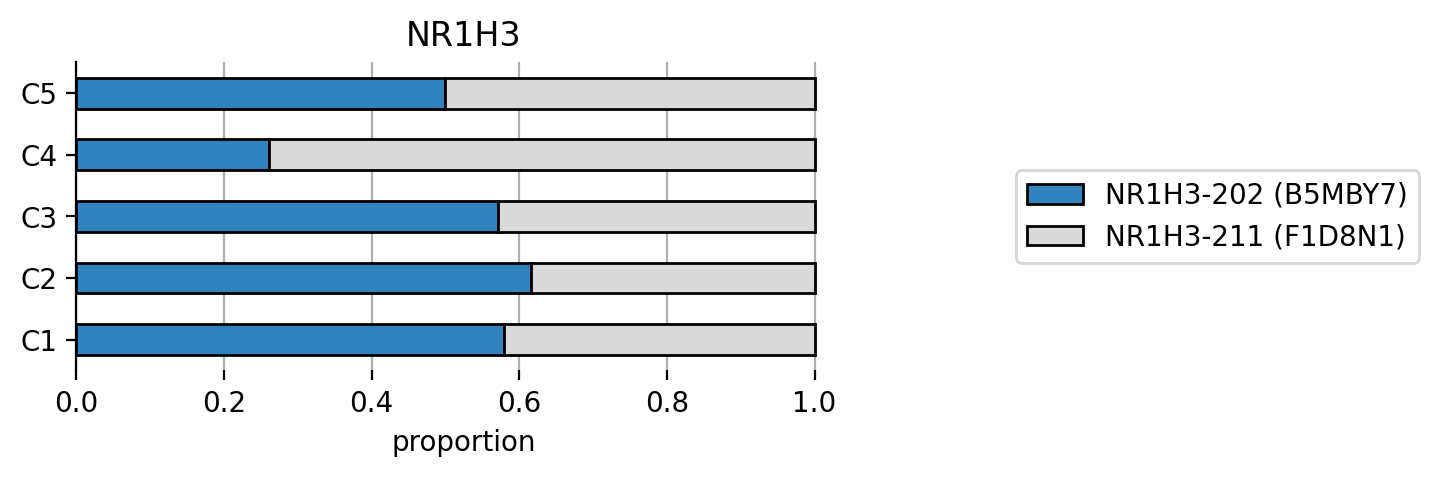

POU2F2


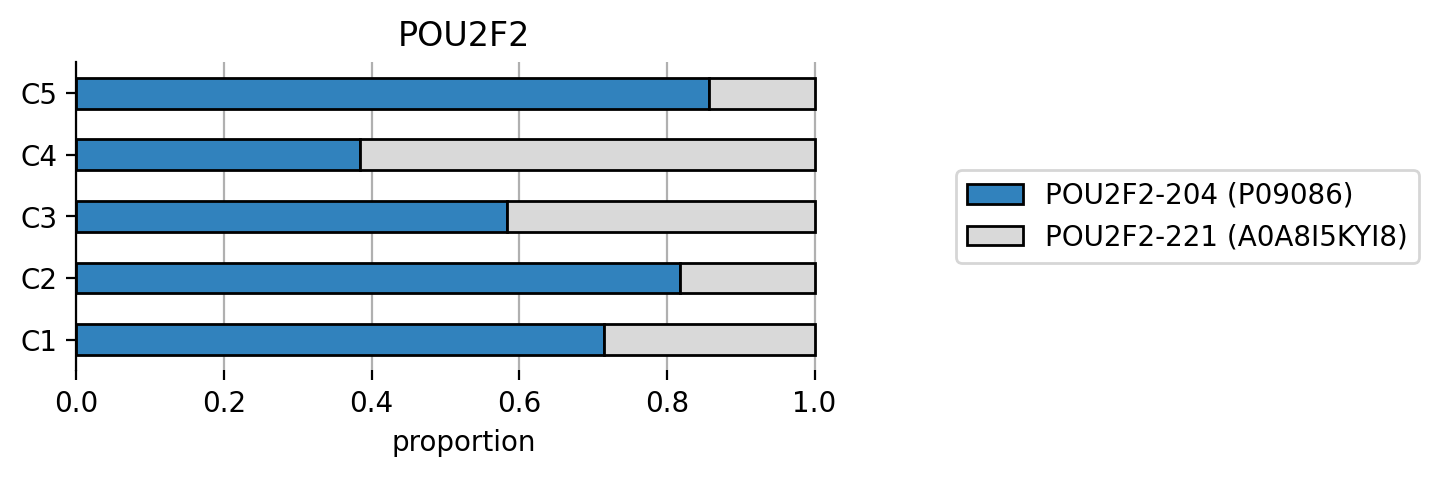

PRDM5


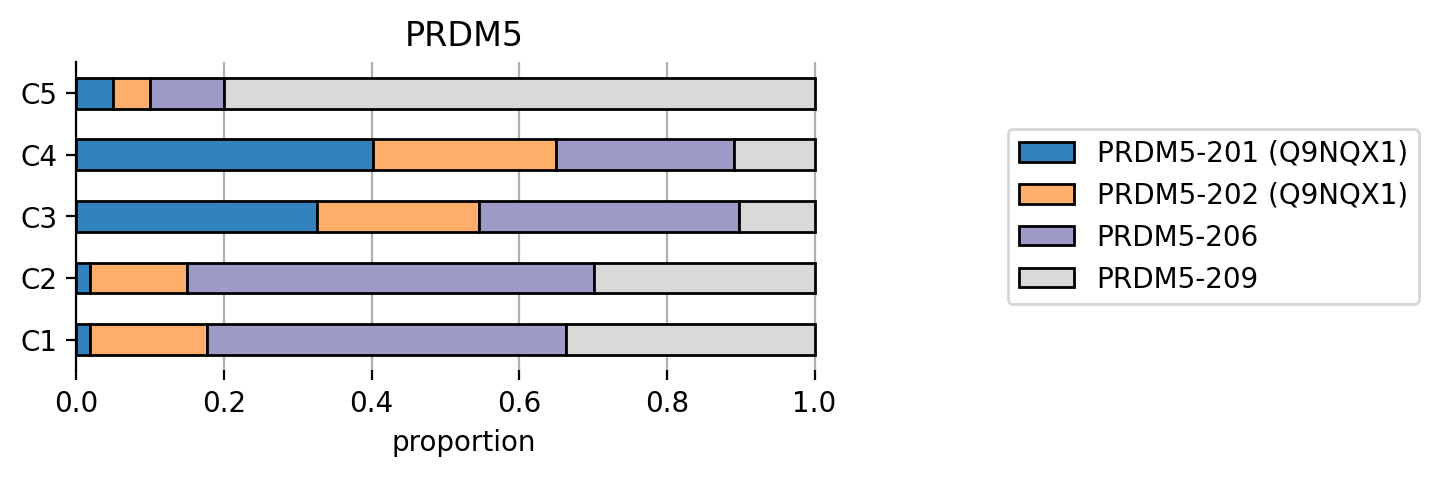

PRDM11


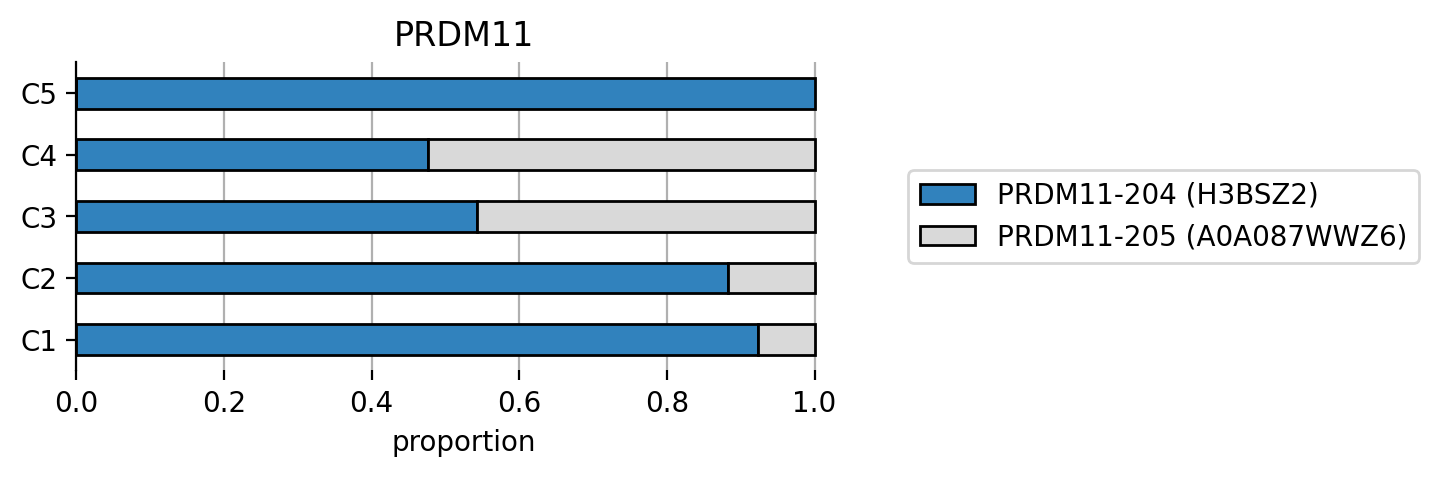

RFX3


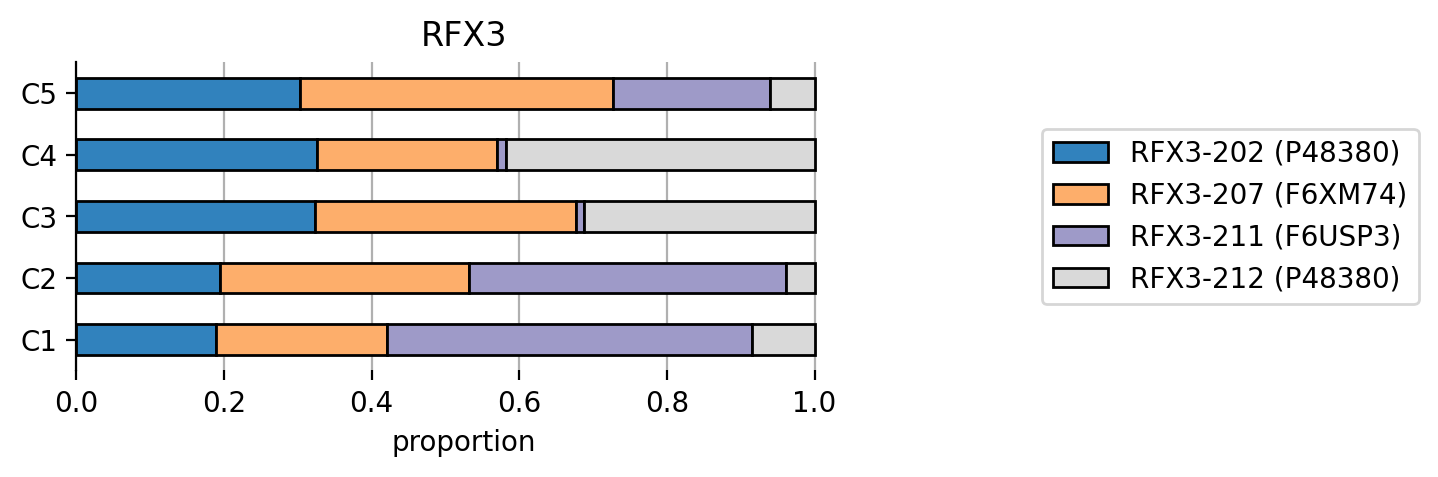

ZFX


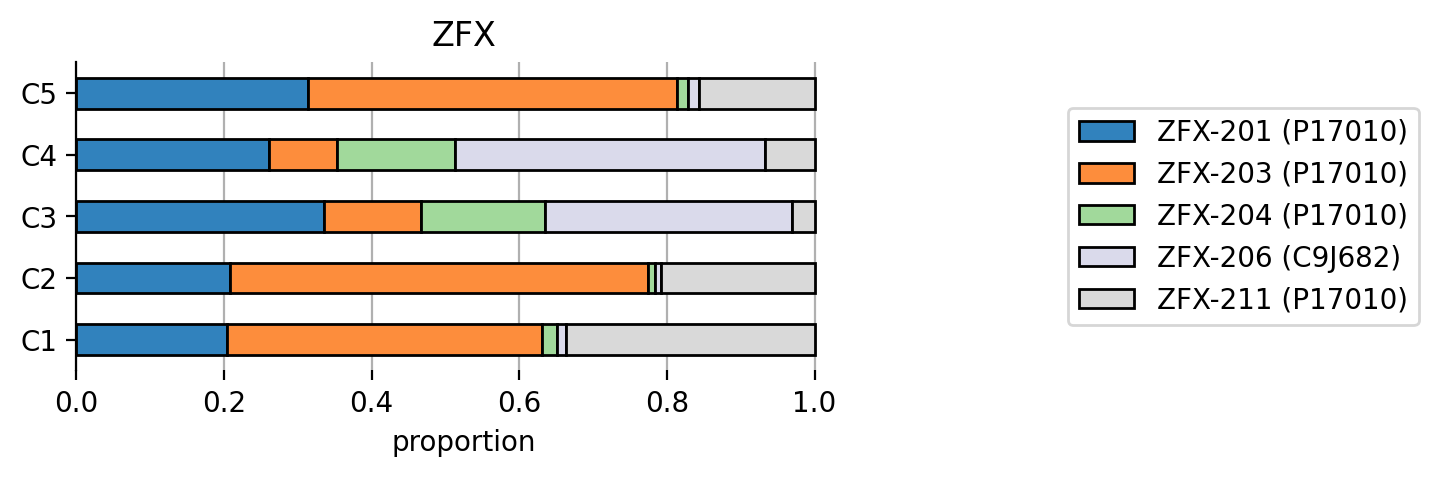

ZNF81


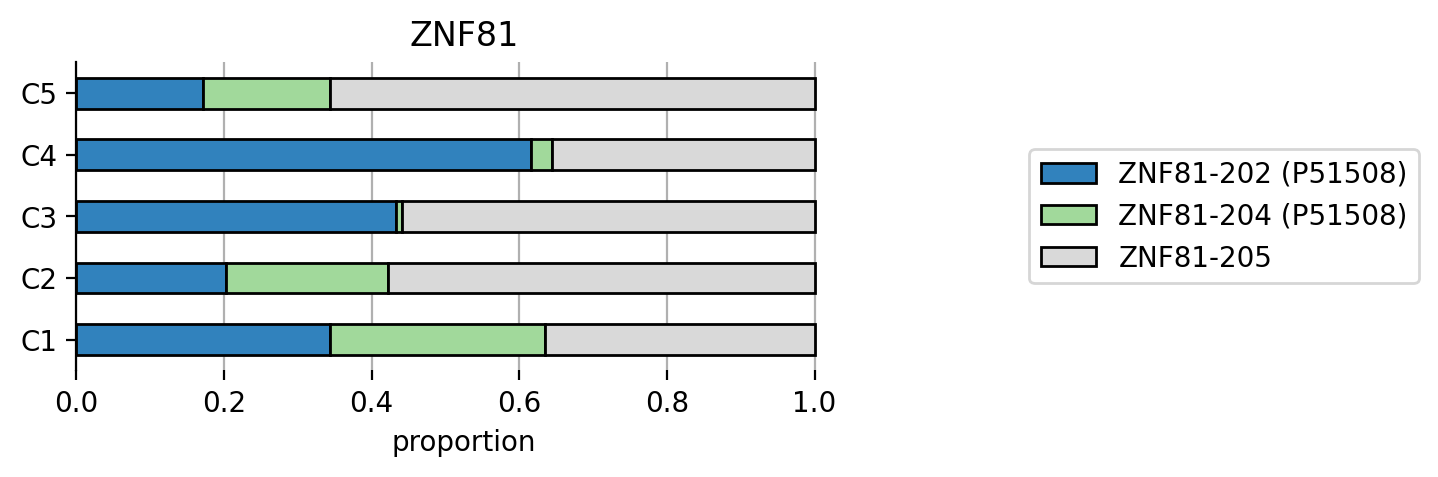

ZNF182


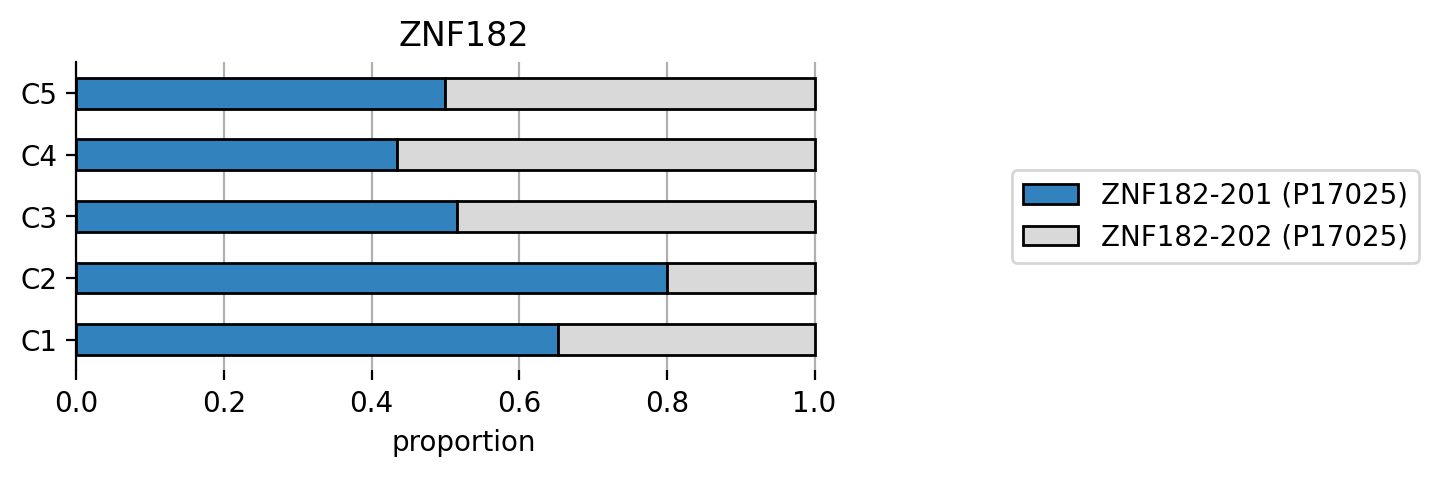

ZNF235


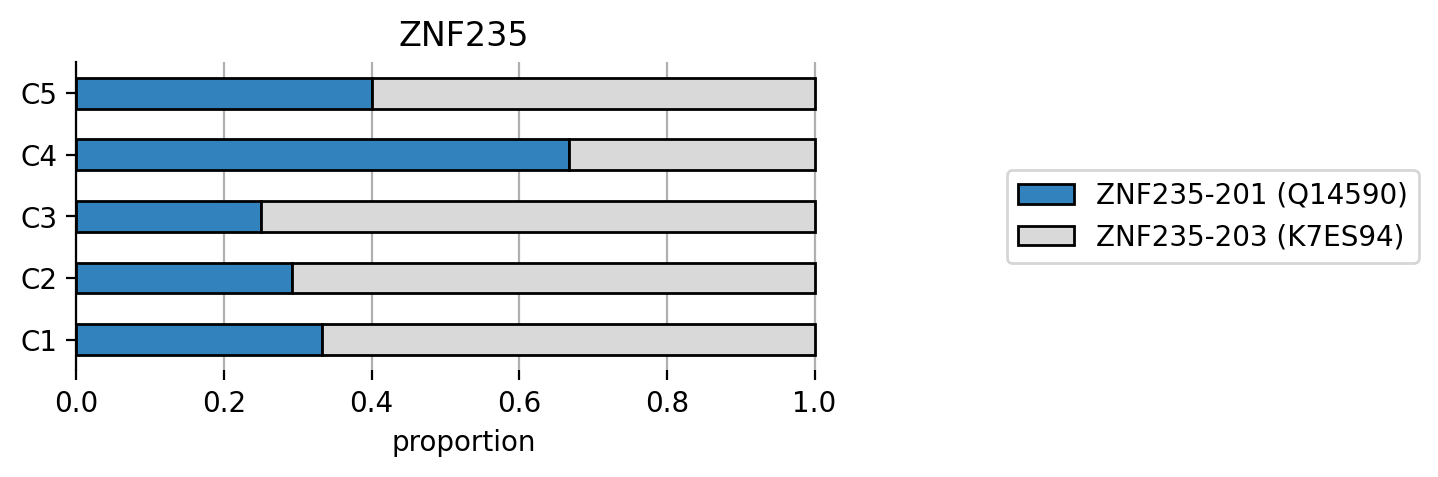

ZNF384


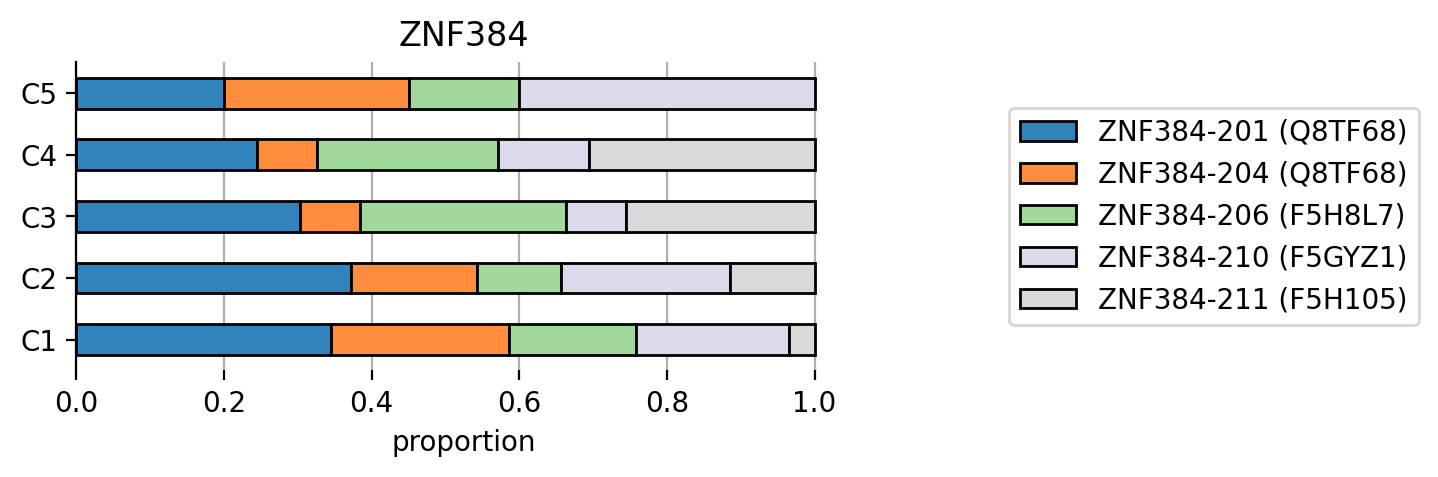

ZNF398


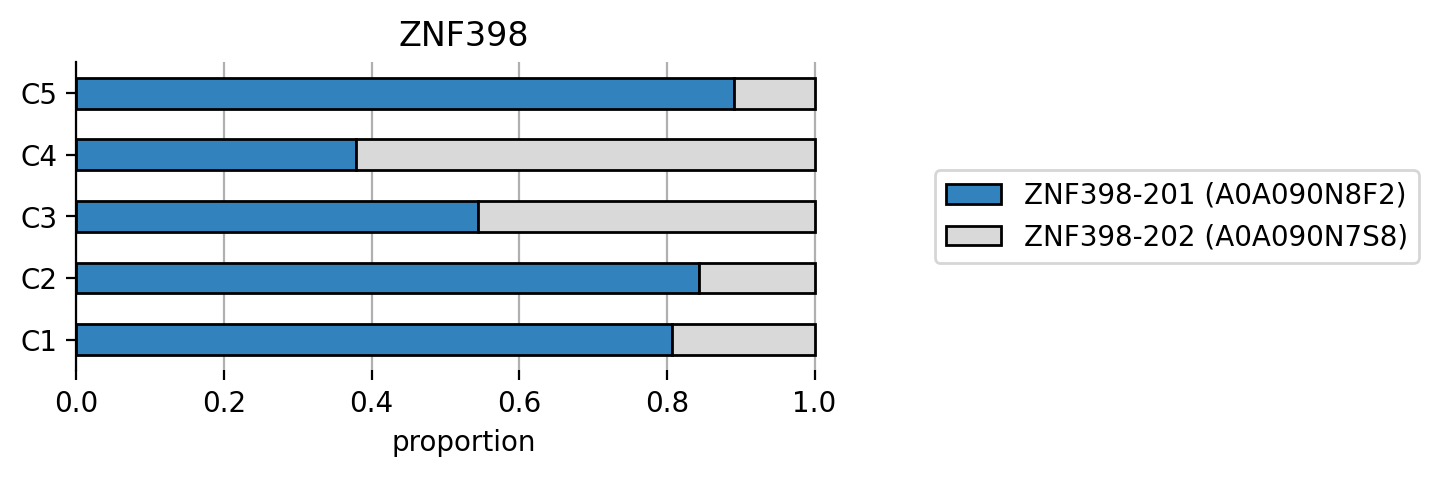

ZNF483


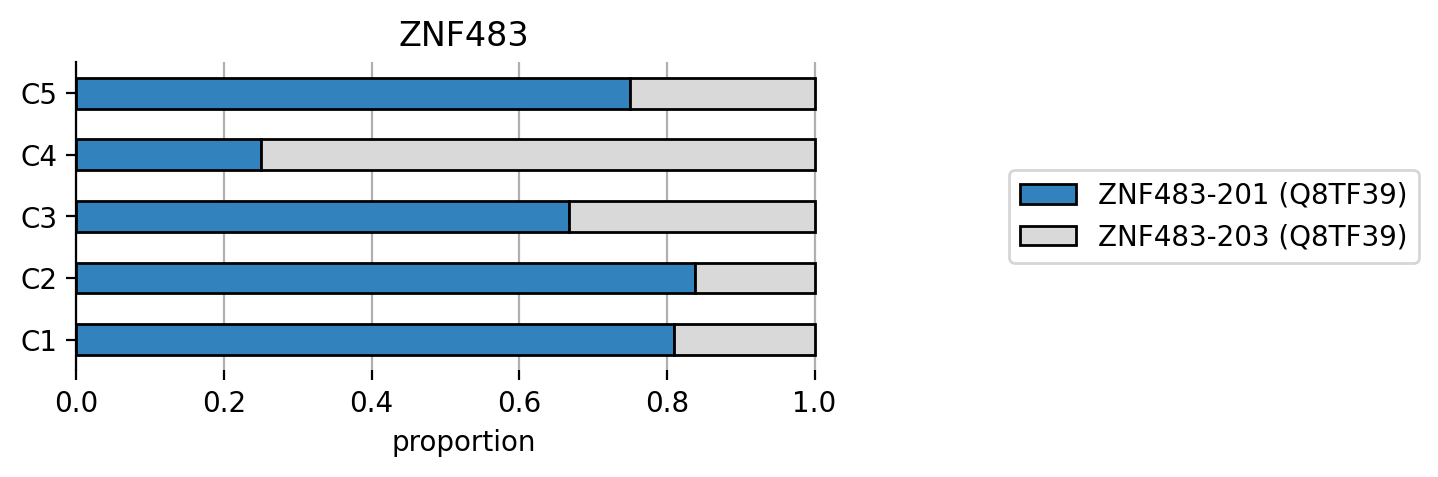

ZNF567


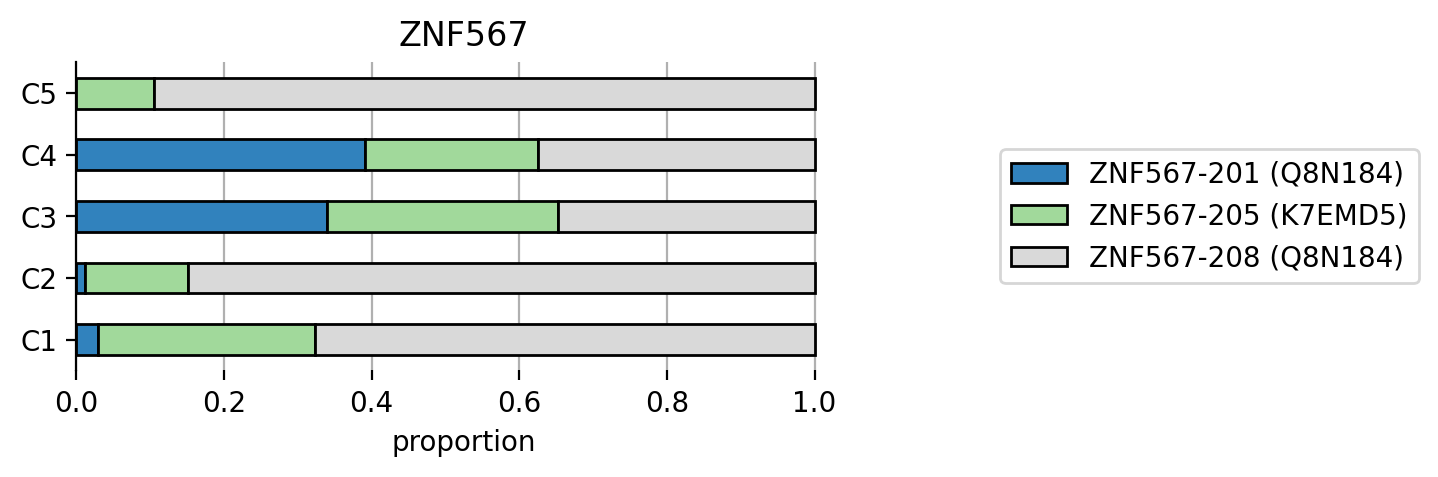

ZNF577


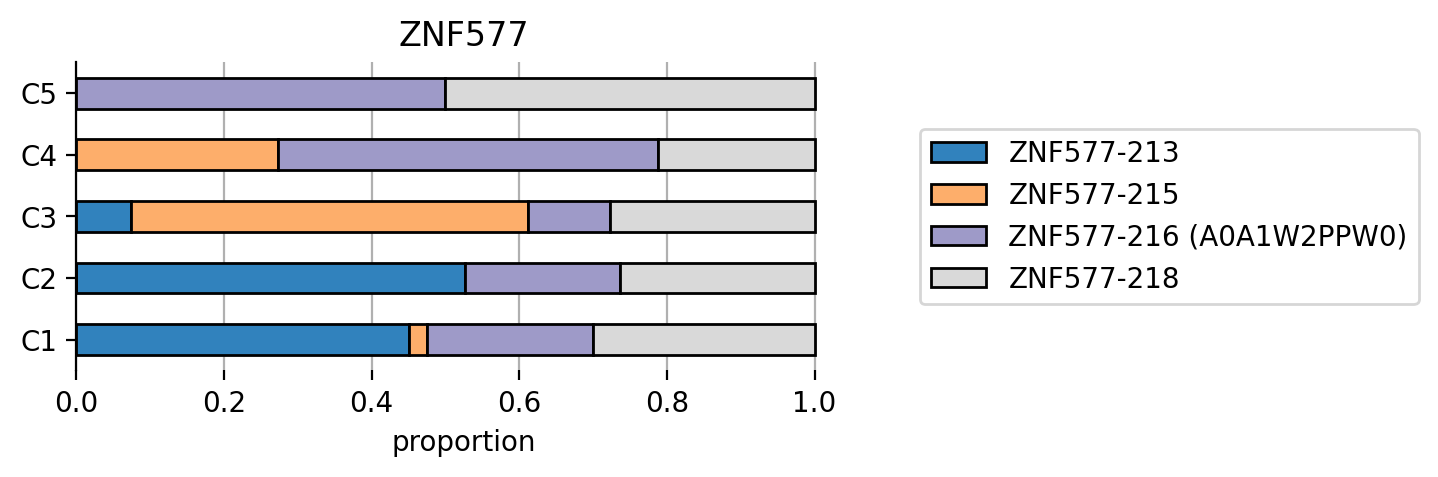

ZNF706


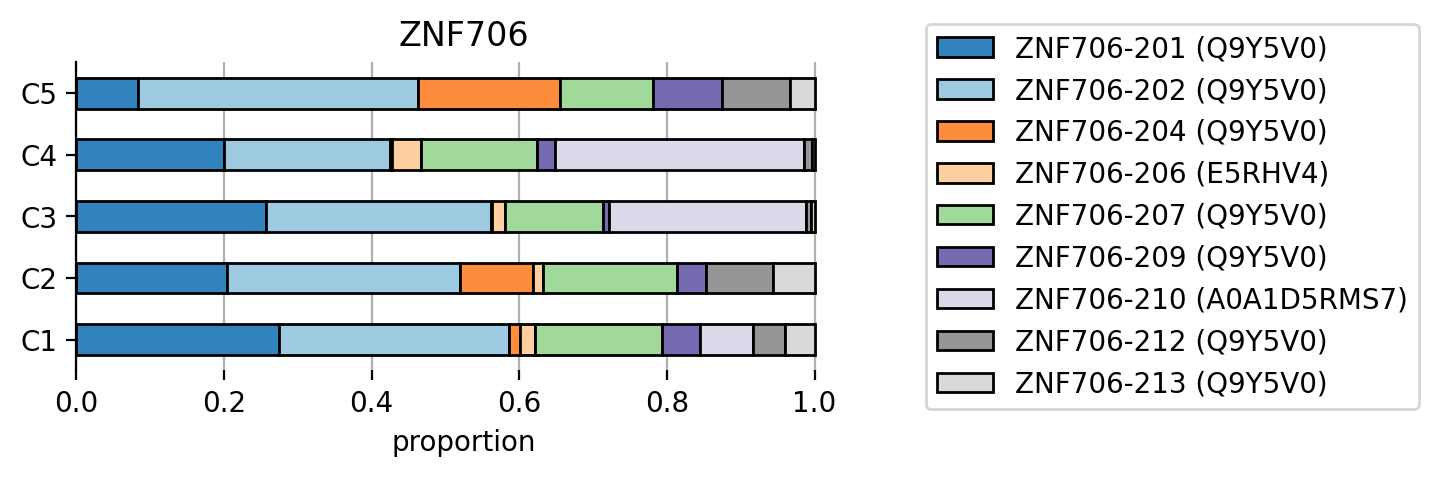

ZNF773


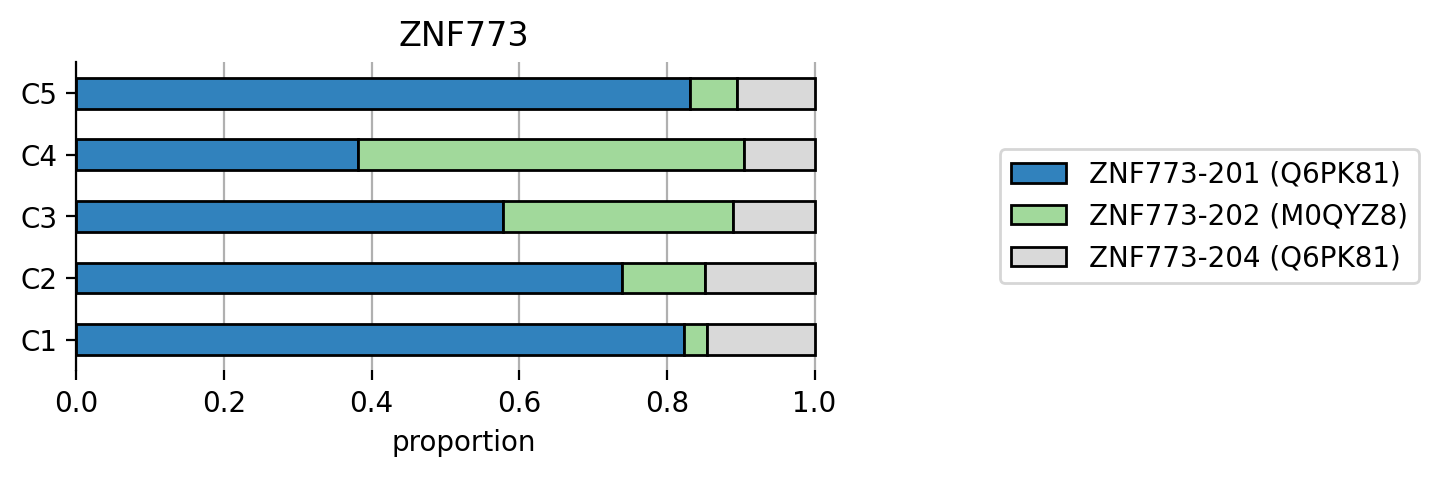

AHDC1


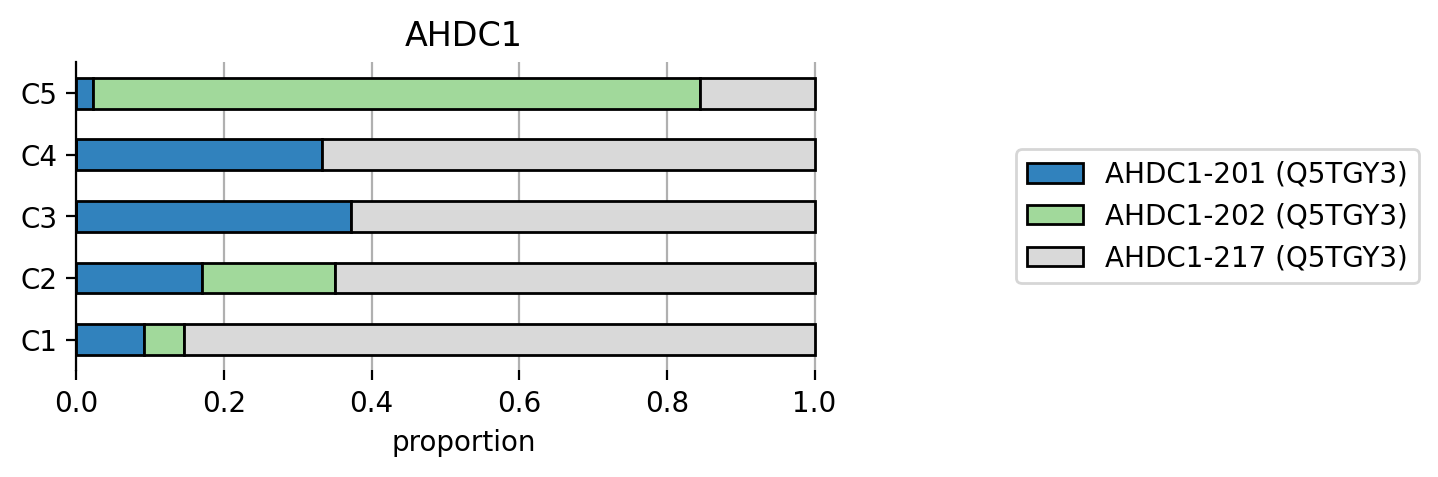

BACH1


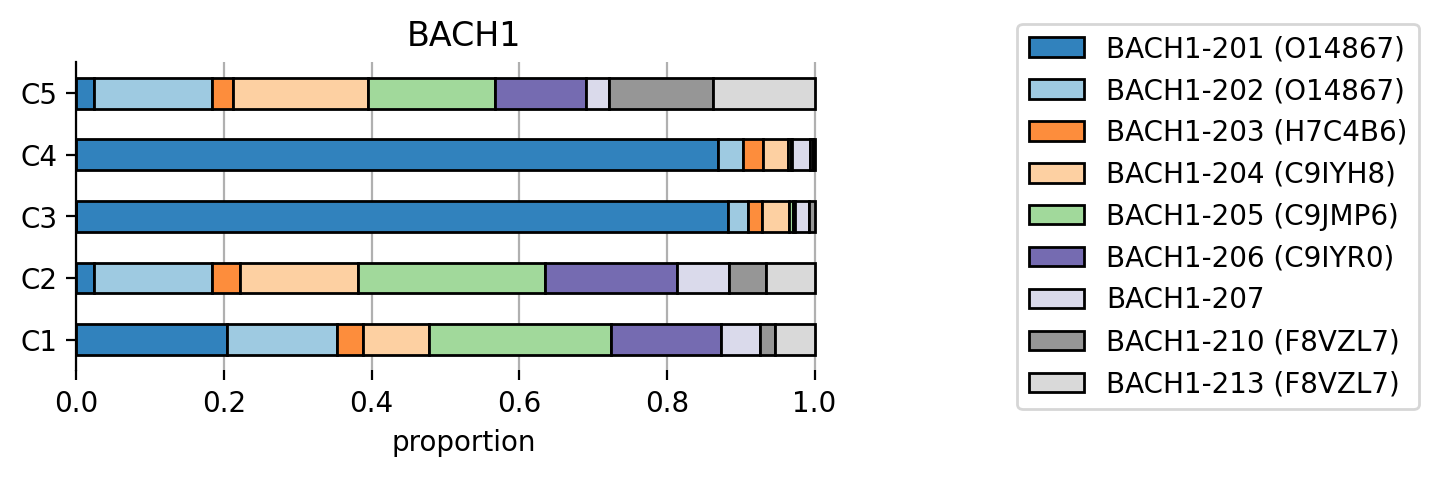

BACH2


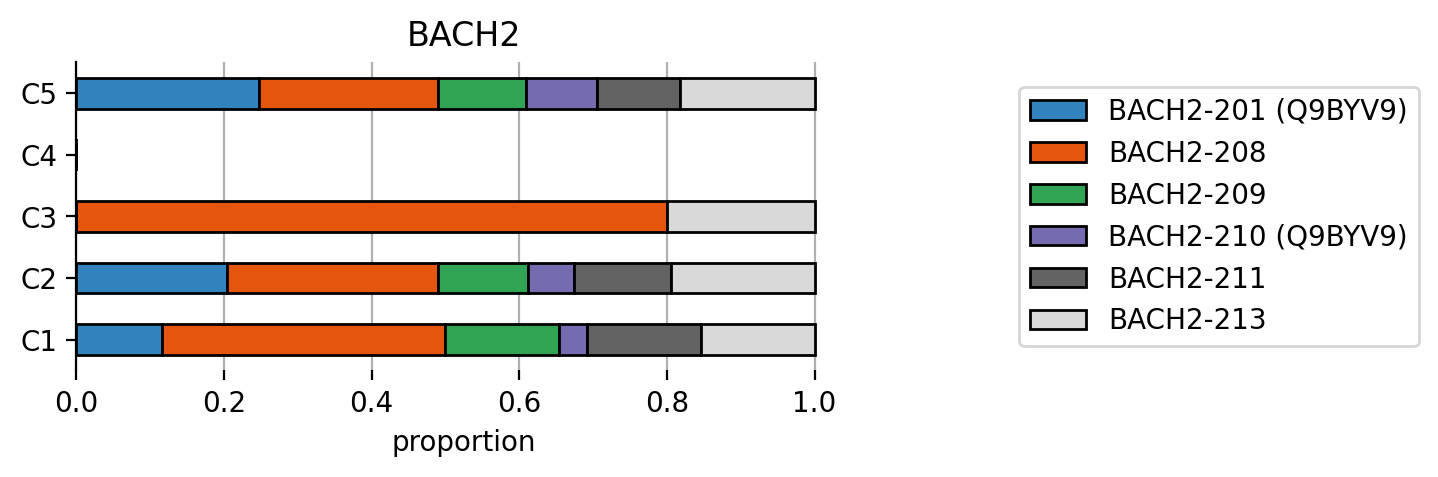

EMX2


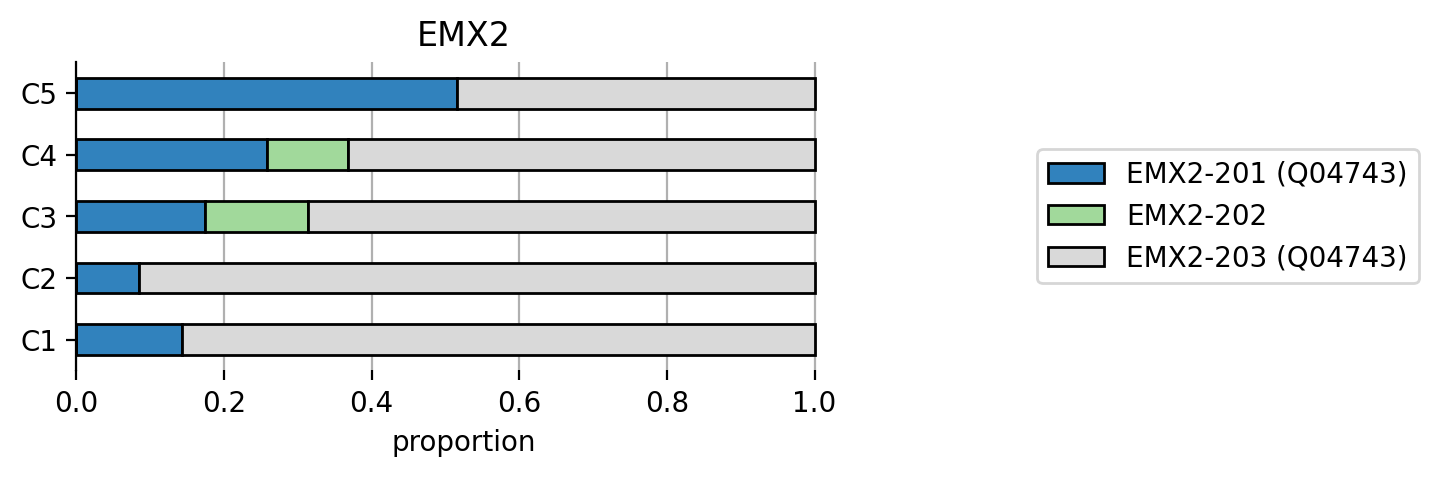

GPANK1


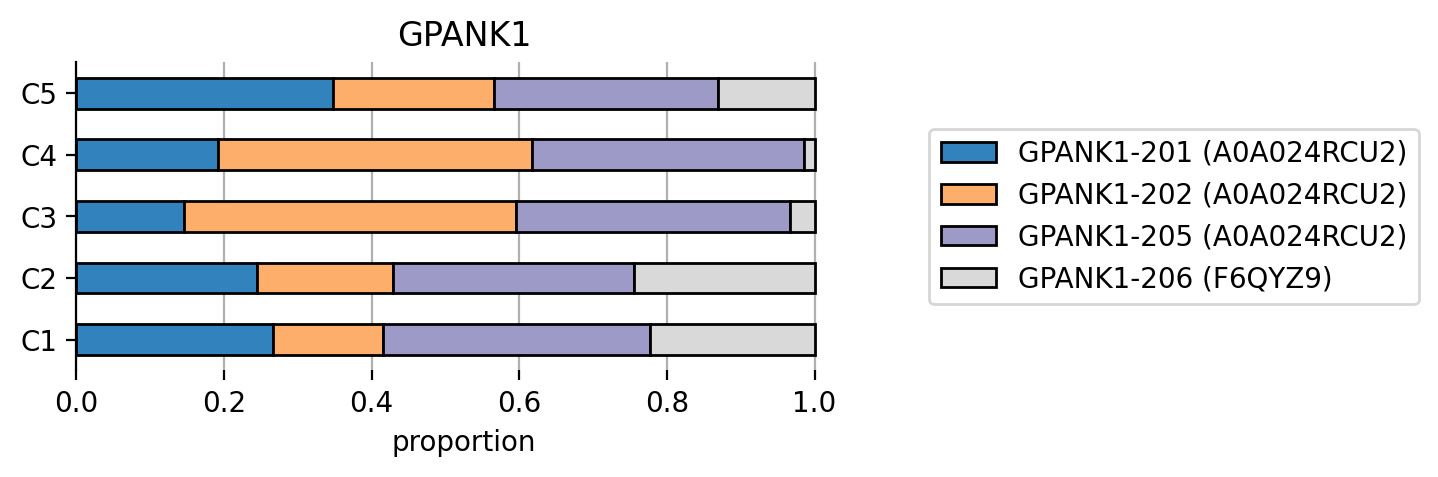

KDM5D


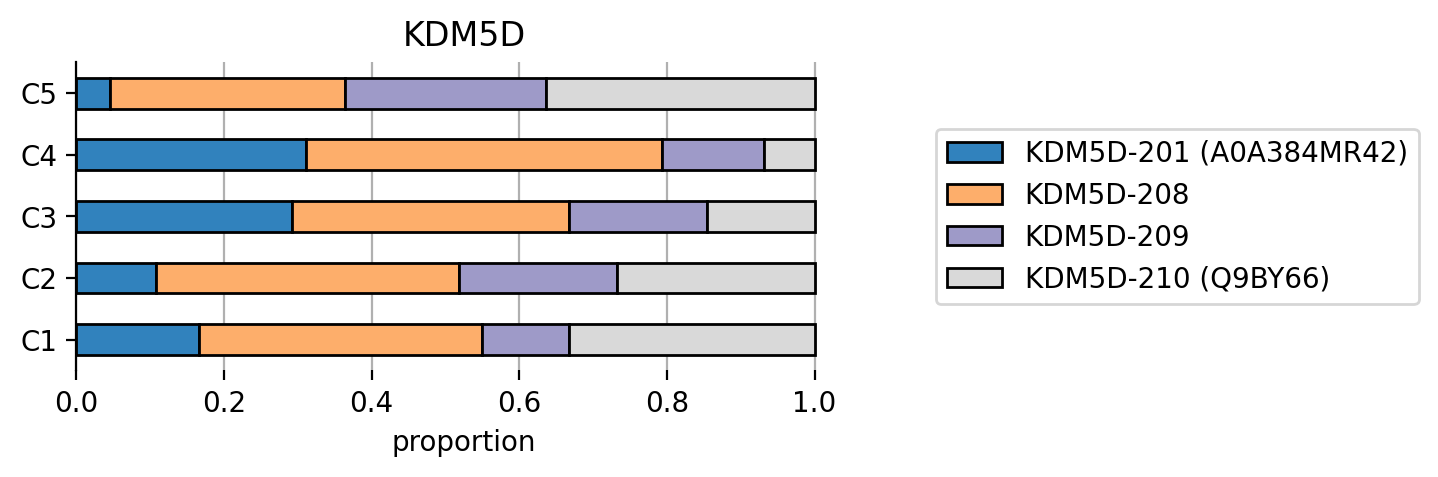

LCOR


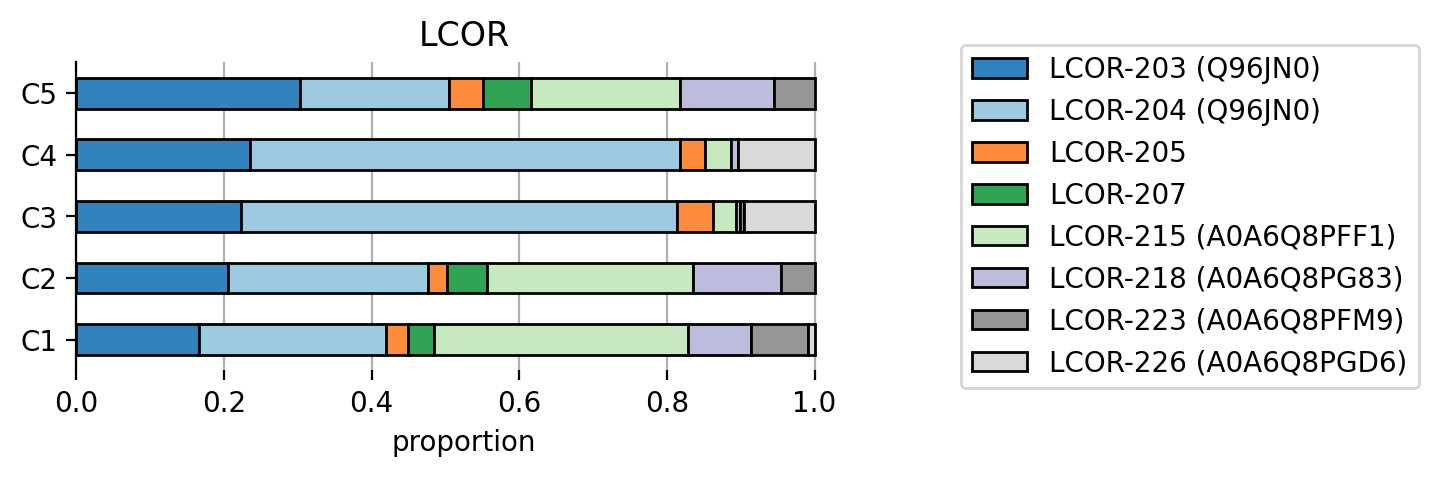

MAZ


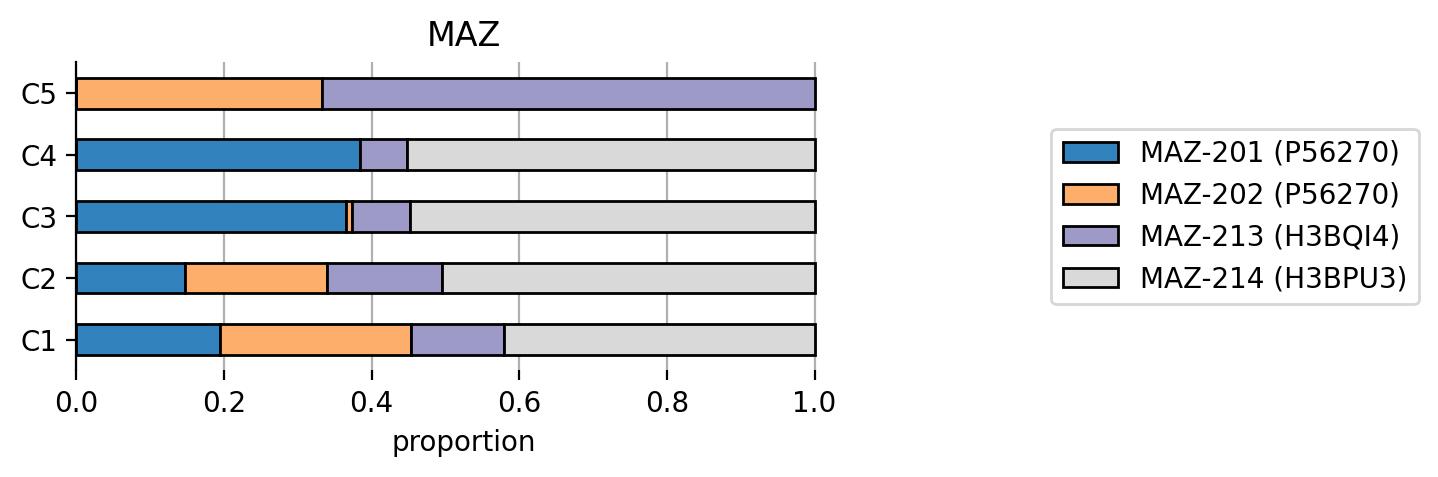

MECOM


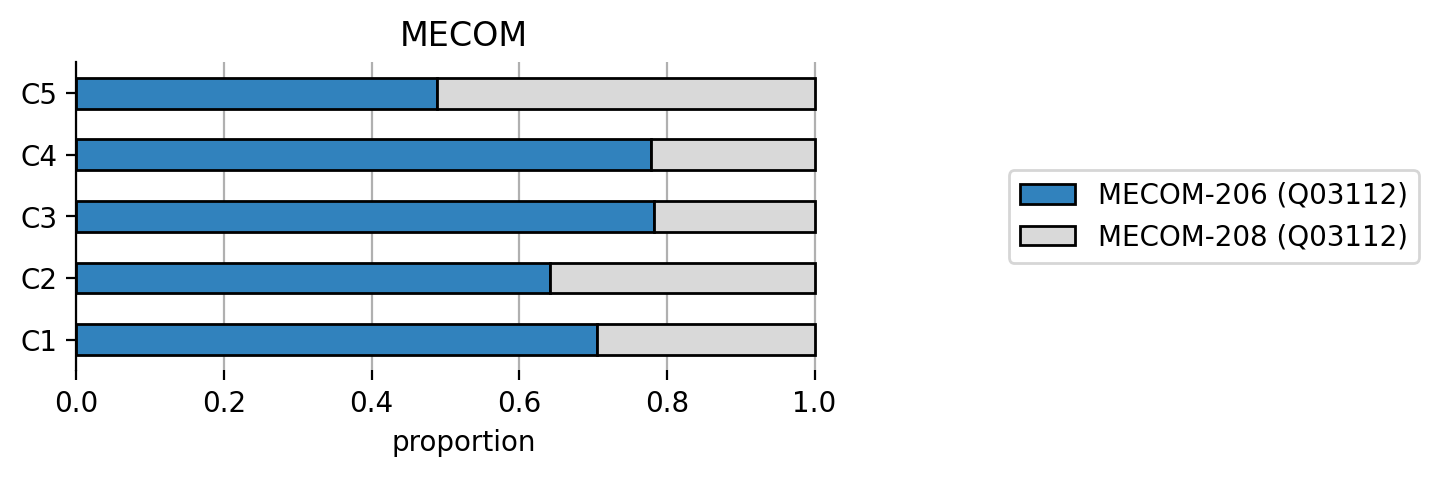

MIOS


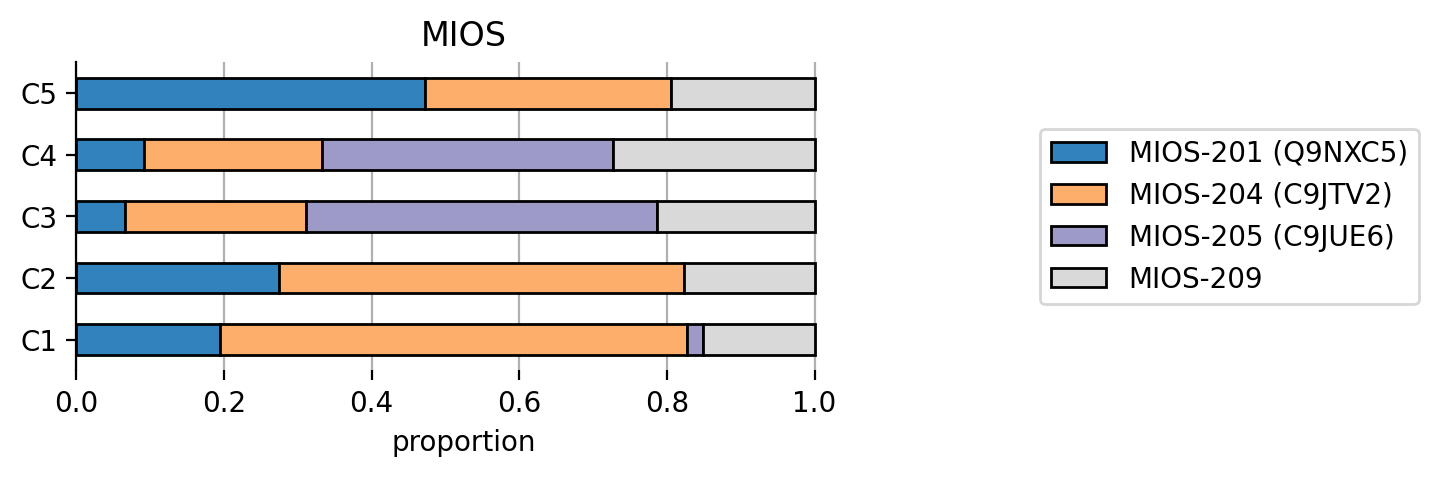

MORN1


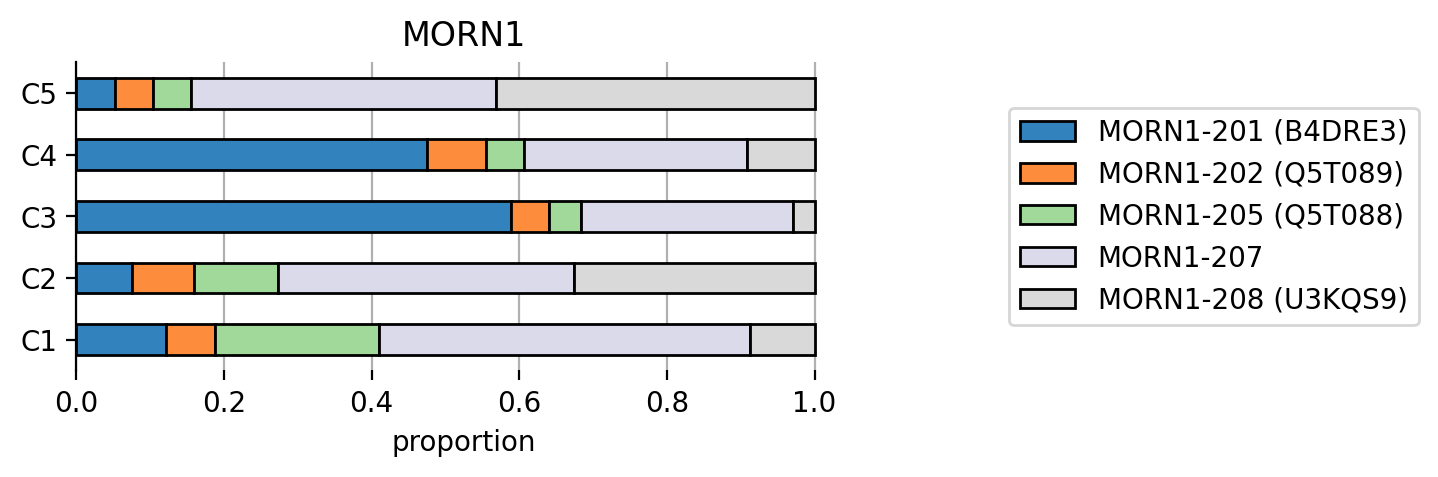

NAP1L1


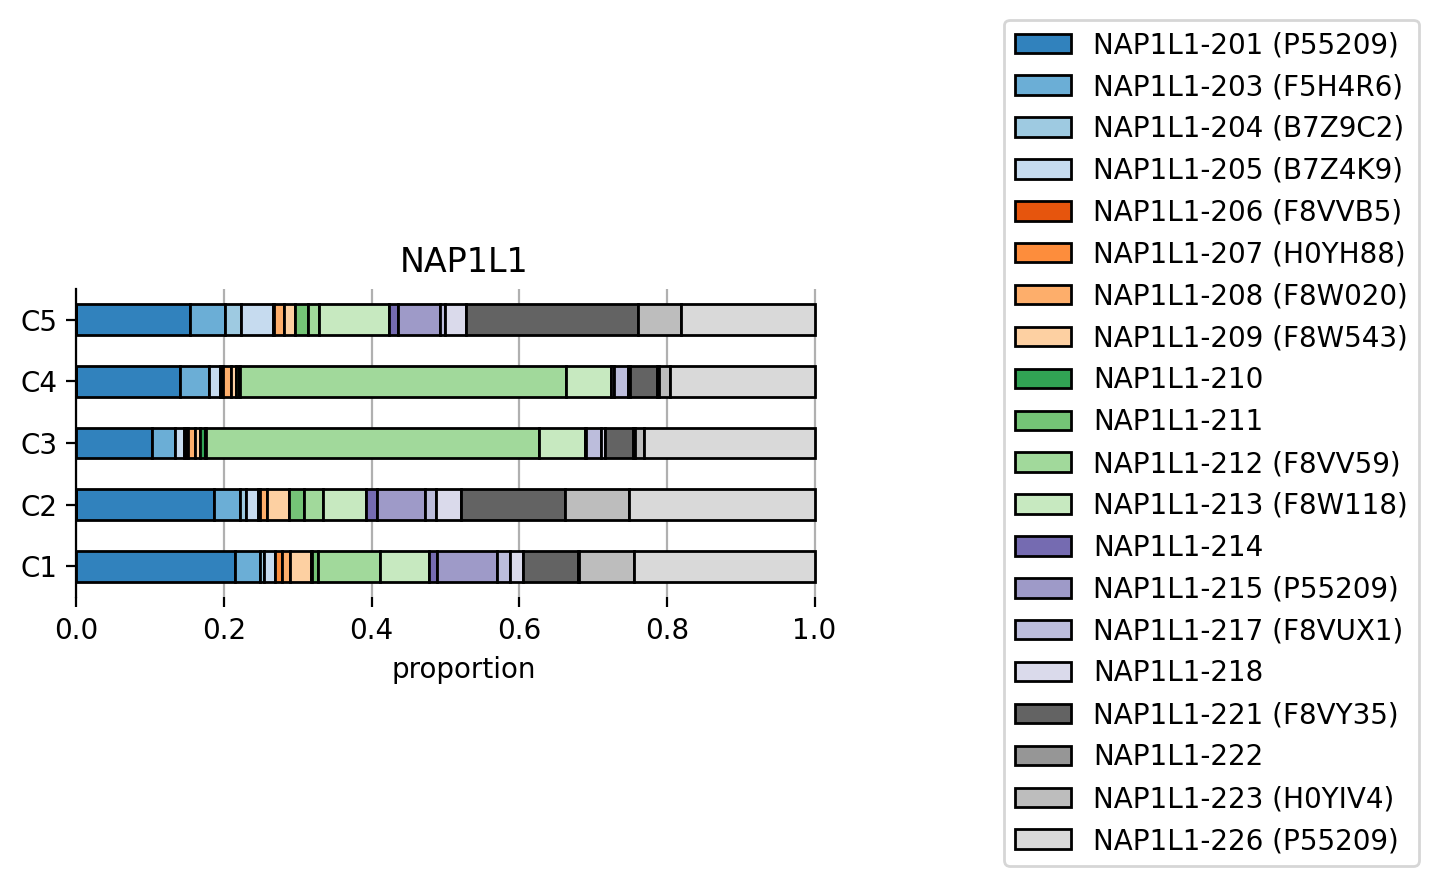

NCOA2


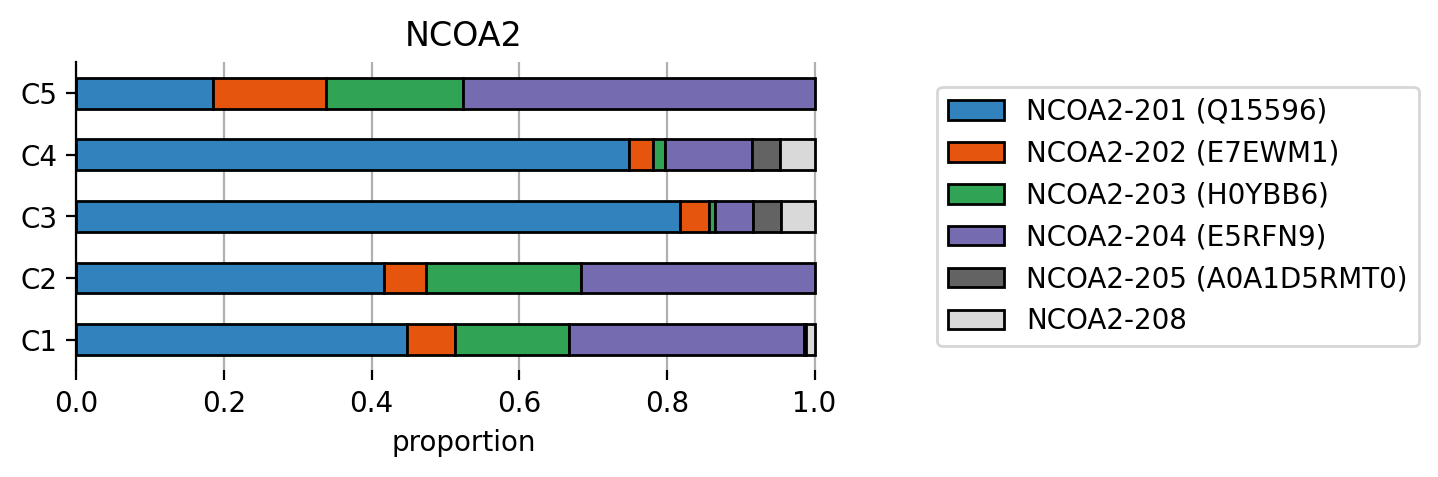

NFIX


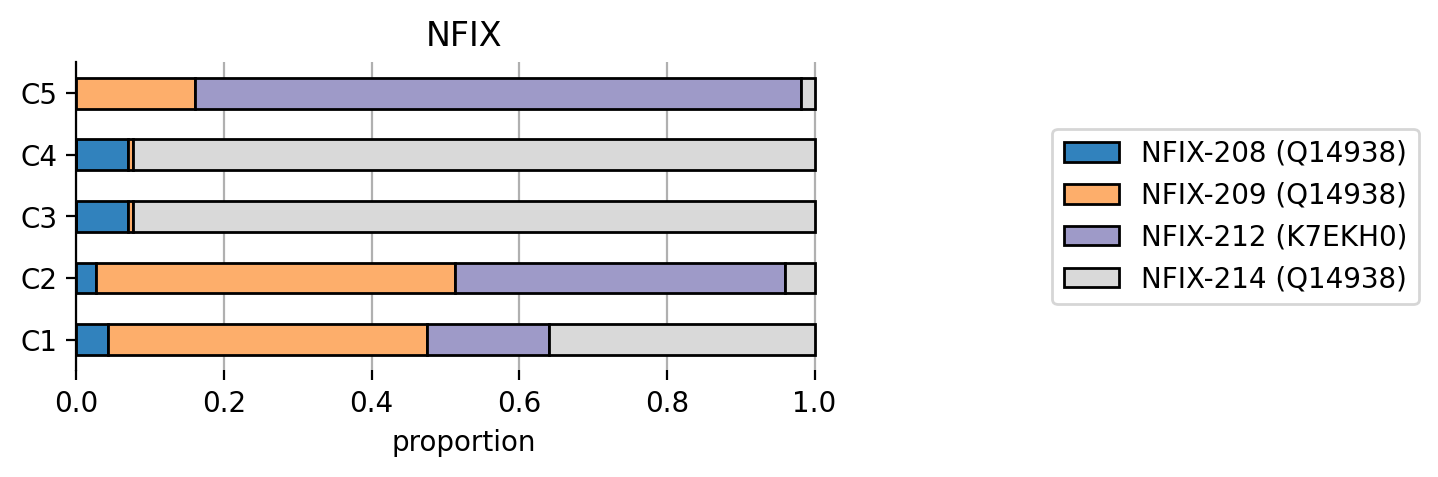

NNT


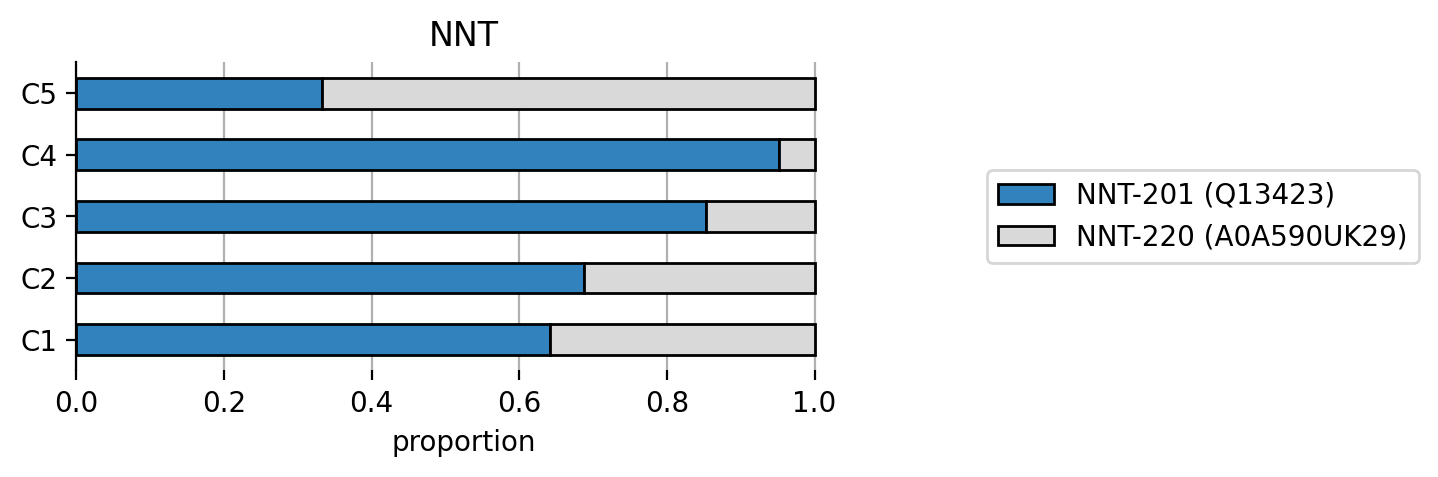

PICK1


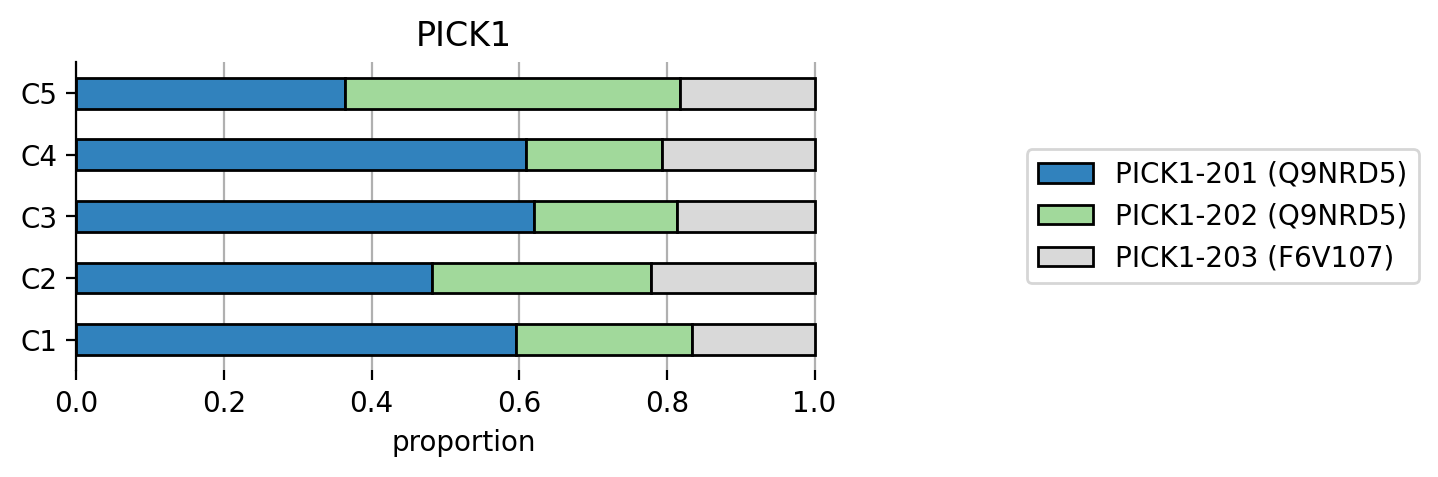

POLI


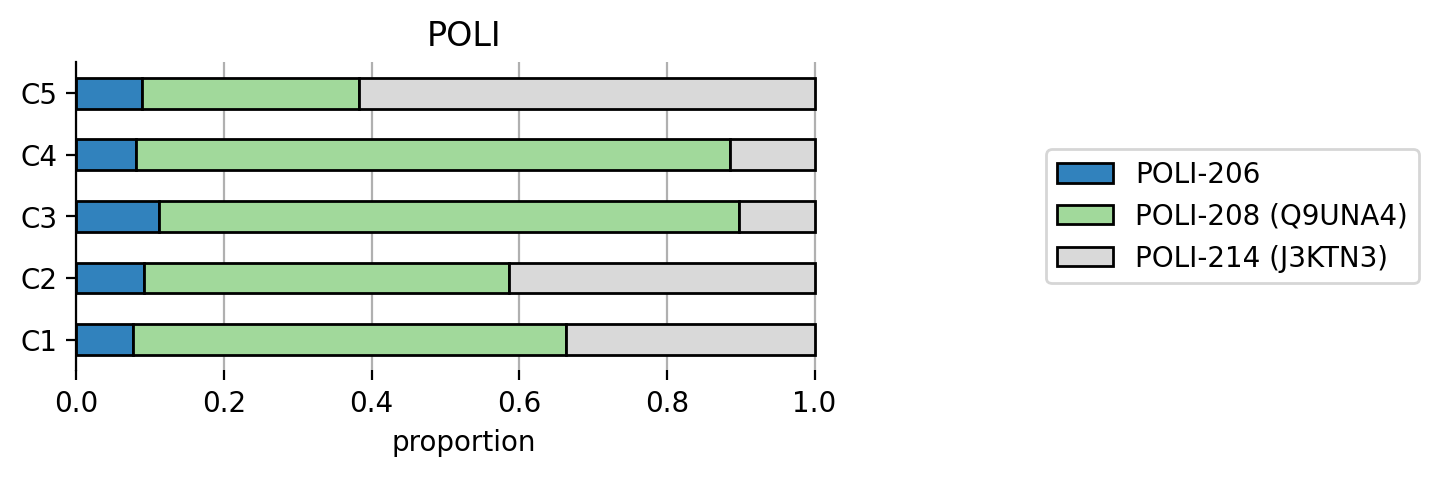

PPARG


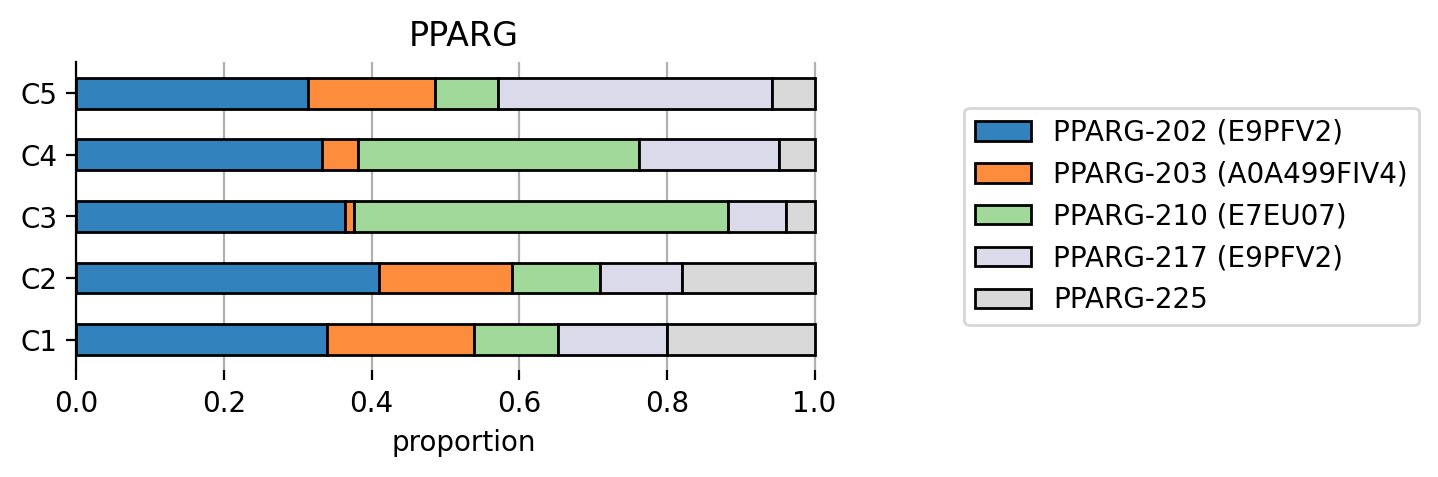

RARB


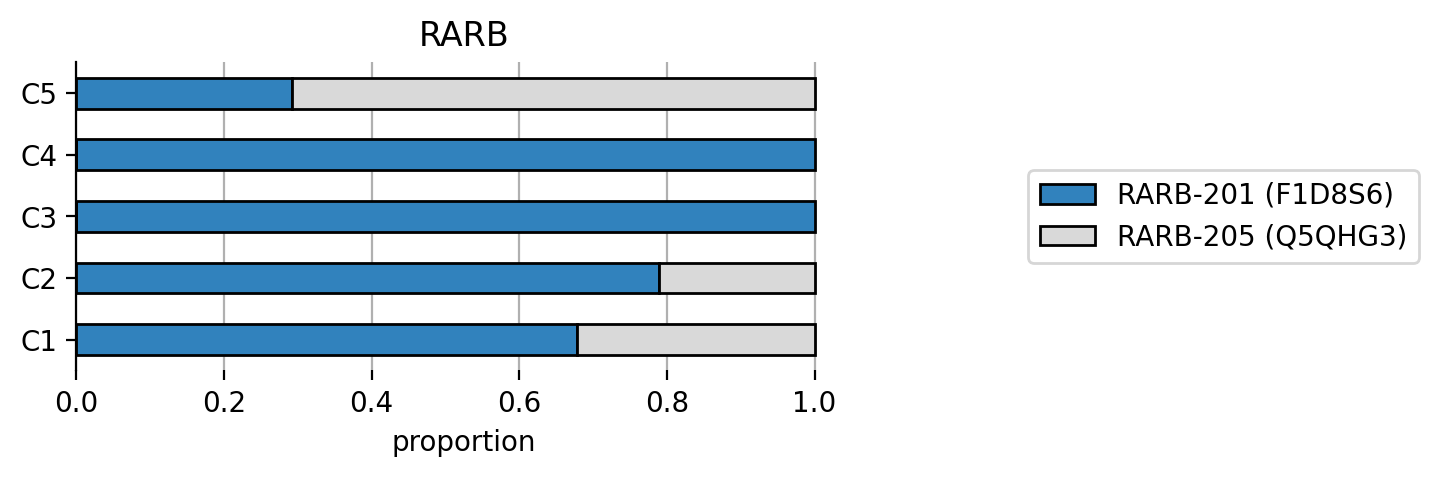

RFX2


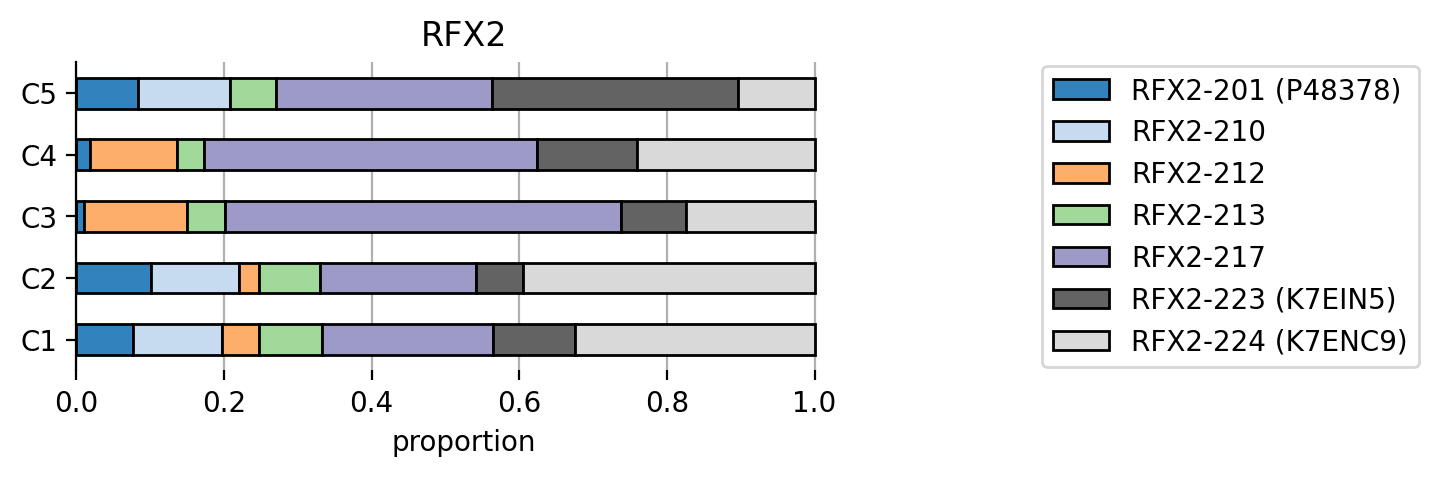

RNASEH2C


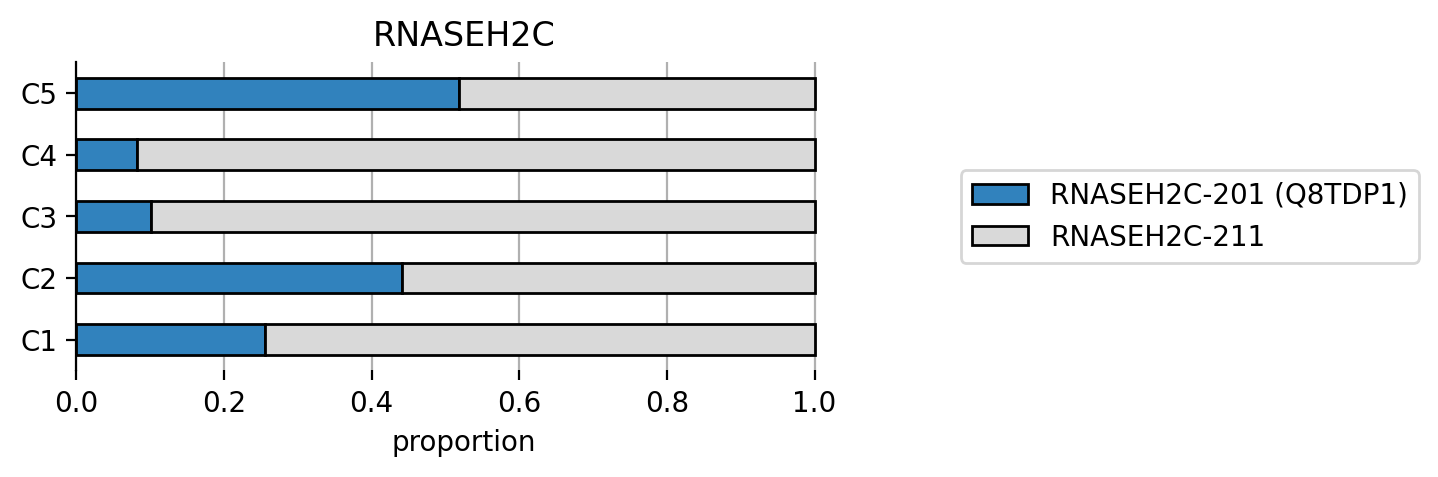

RUVBL1


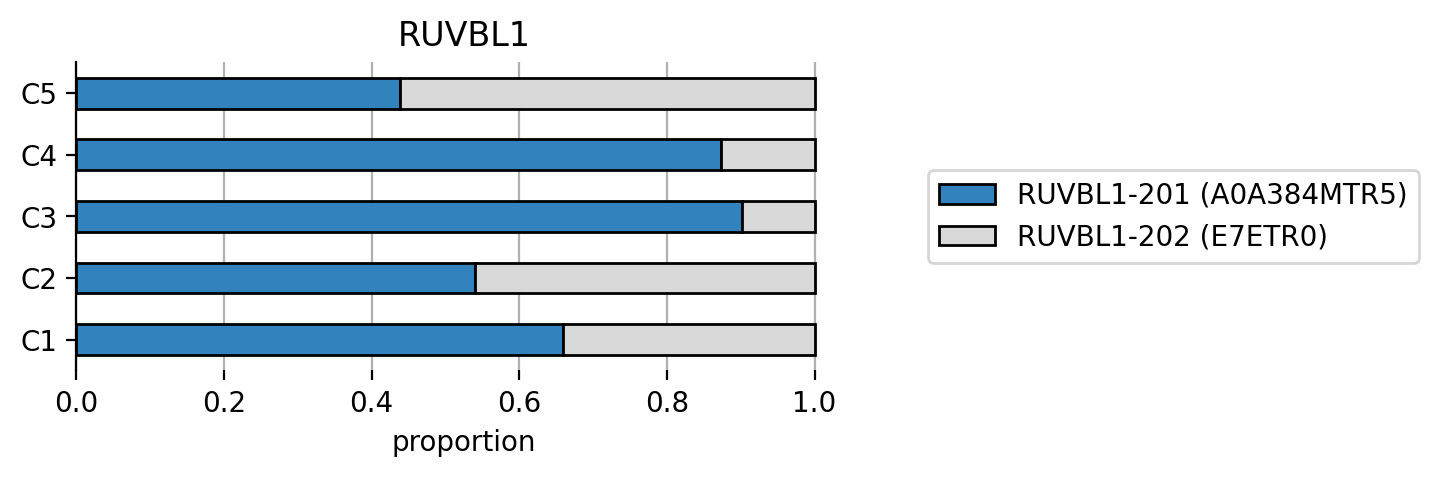

SMAD3


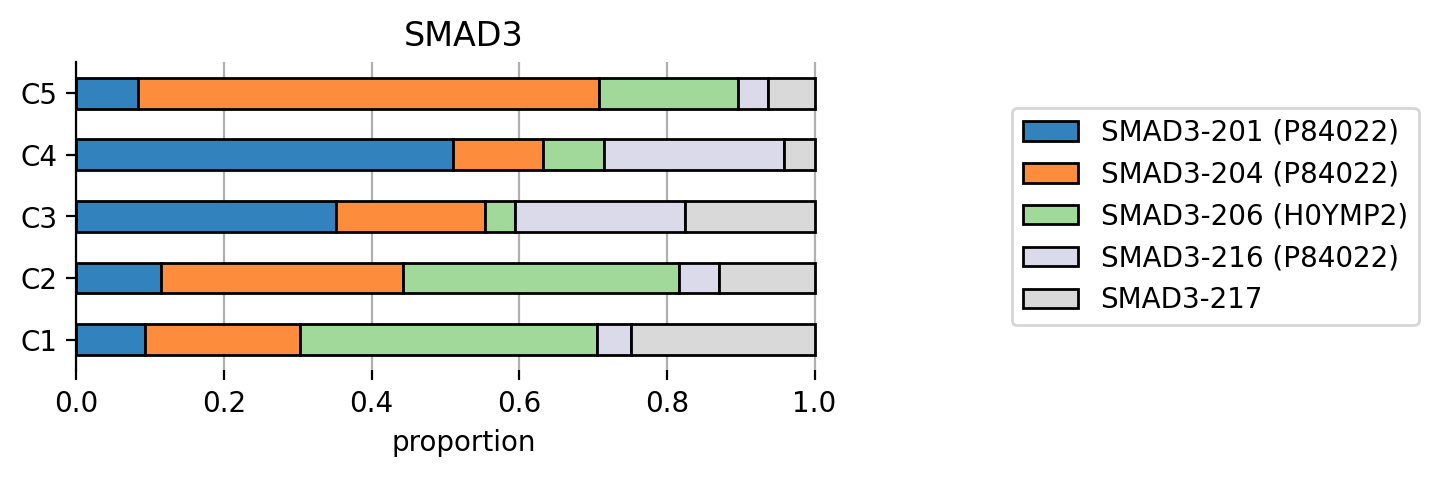

UBTF


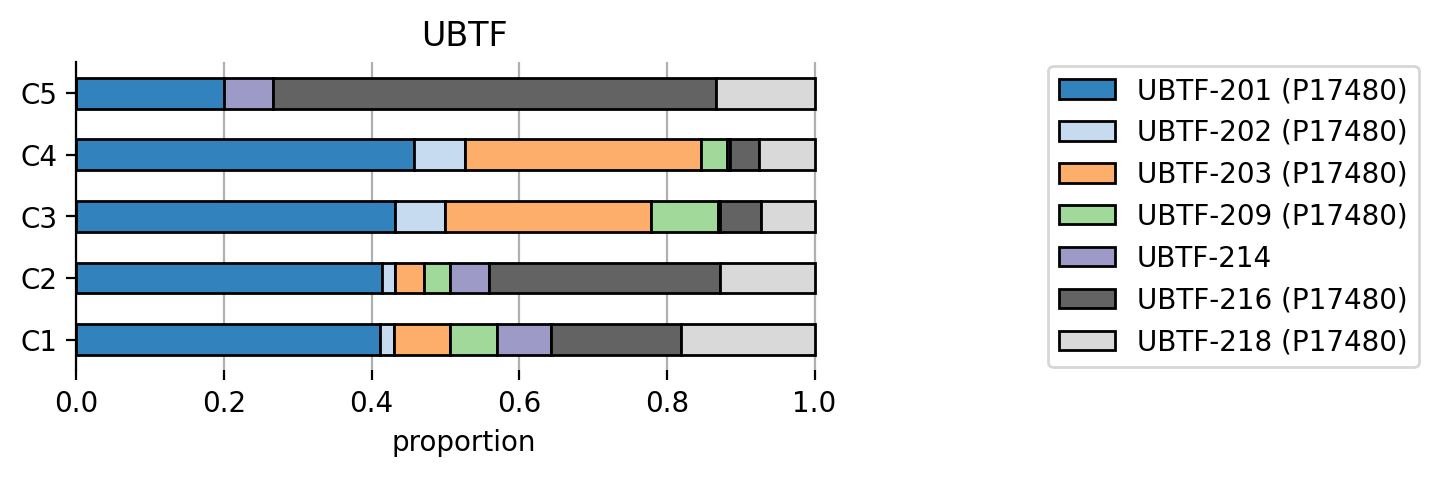

USF2


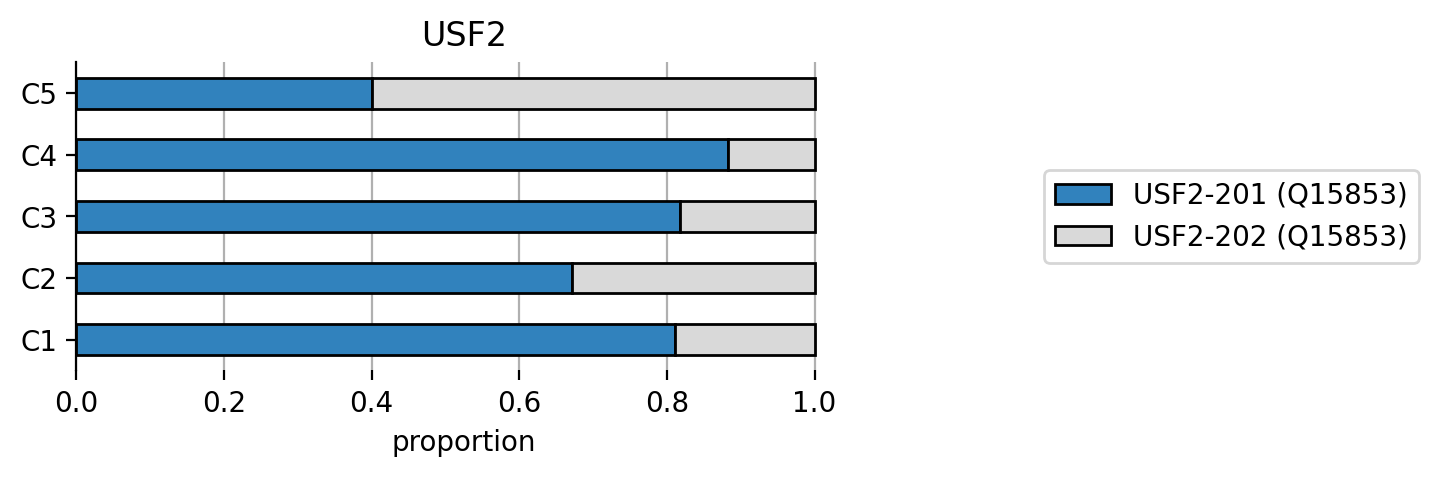

ZFP30


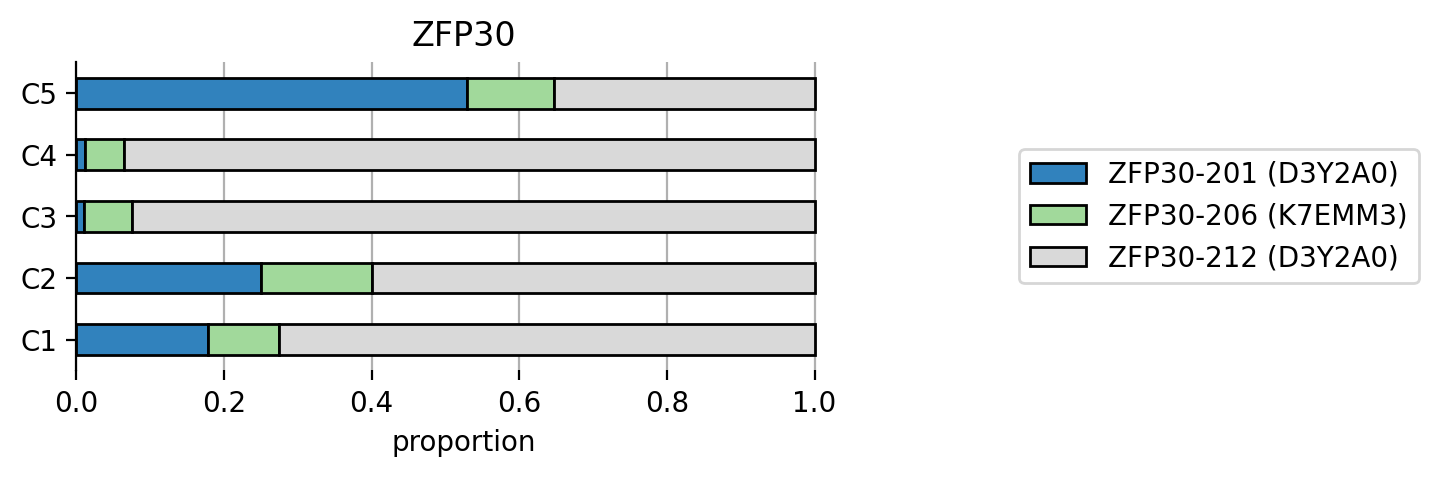

ZFP64


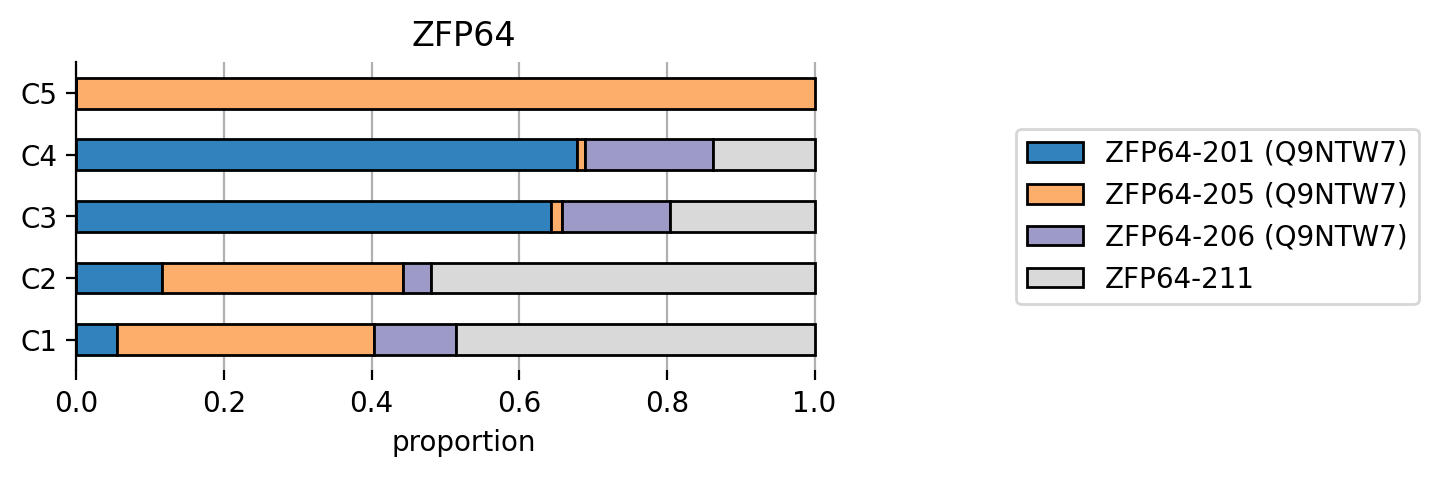

ZFP90


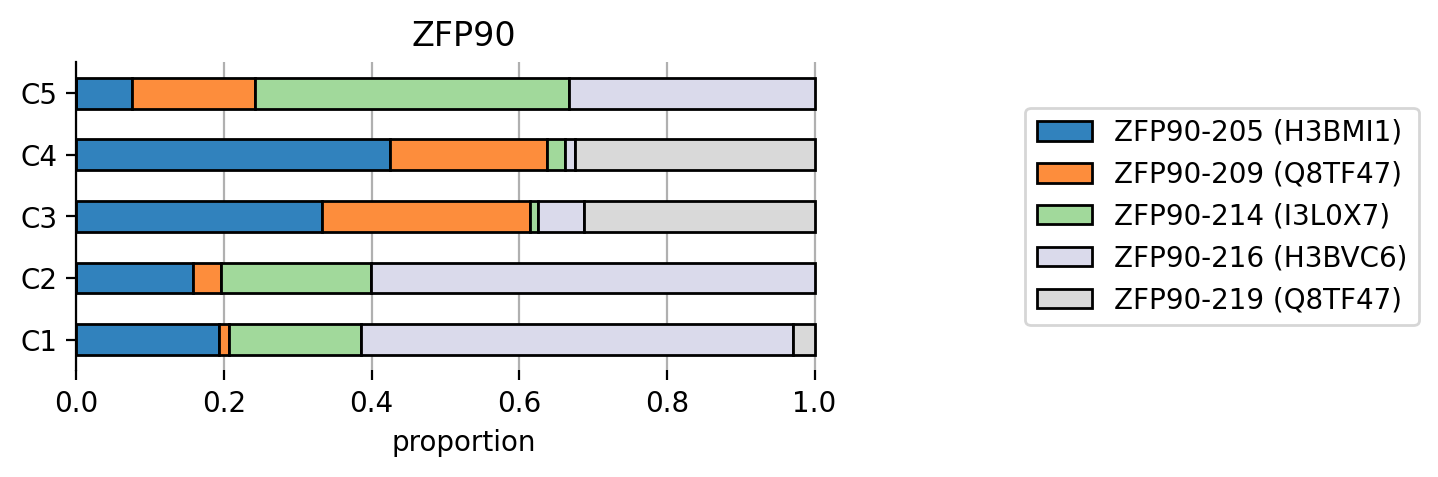

ZKSCAN1


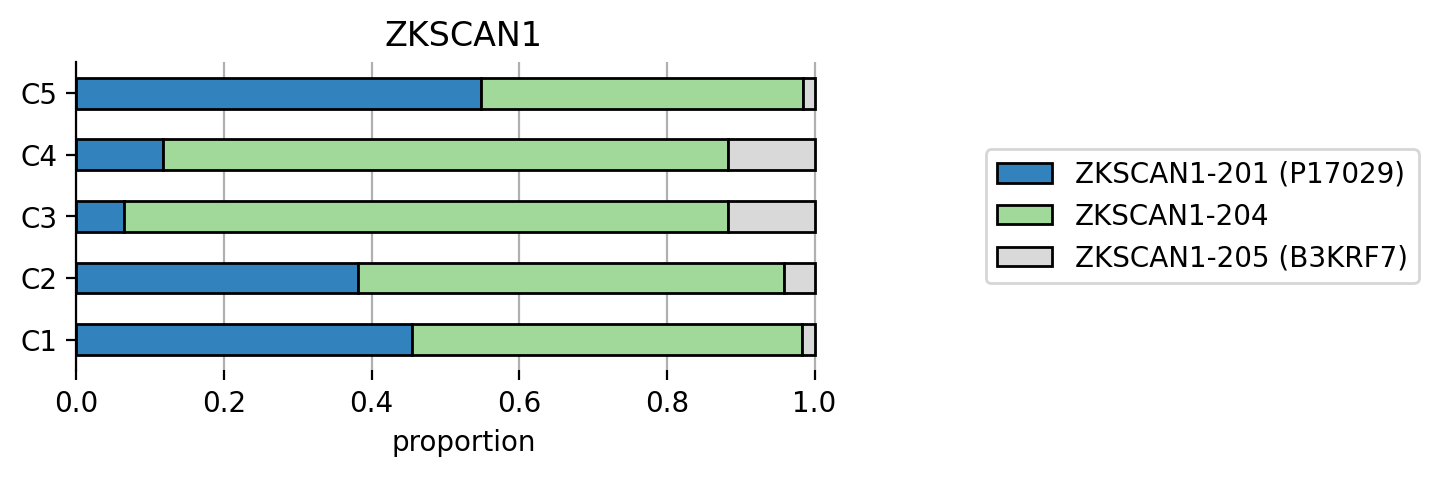

ZNF10


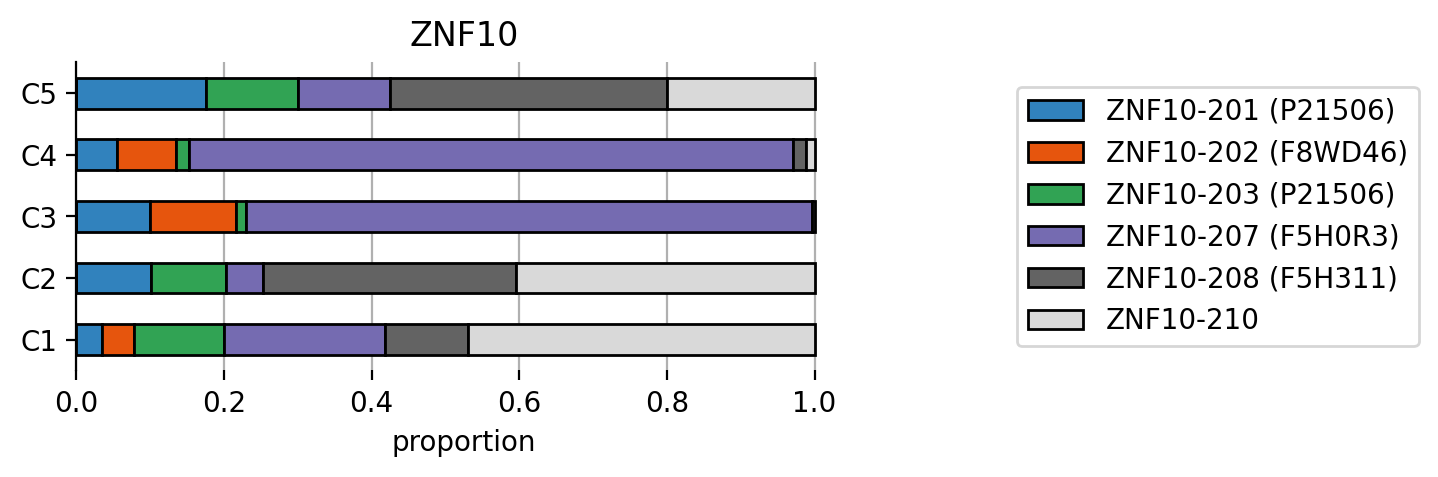

ZNF112


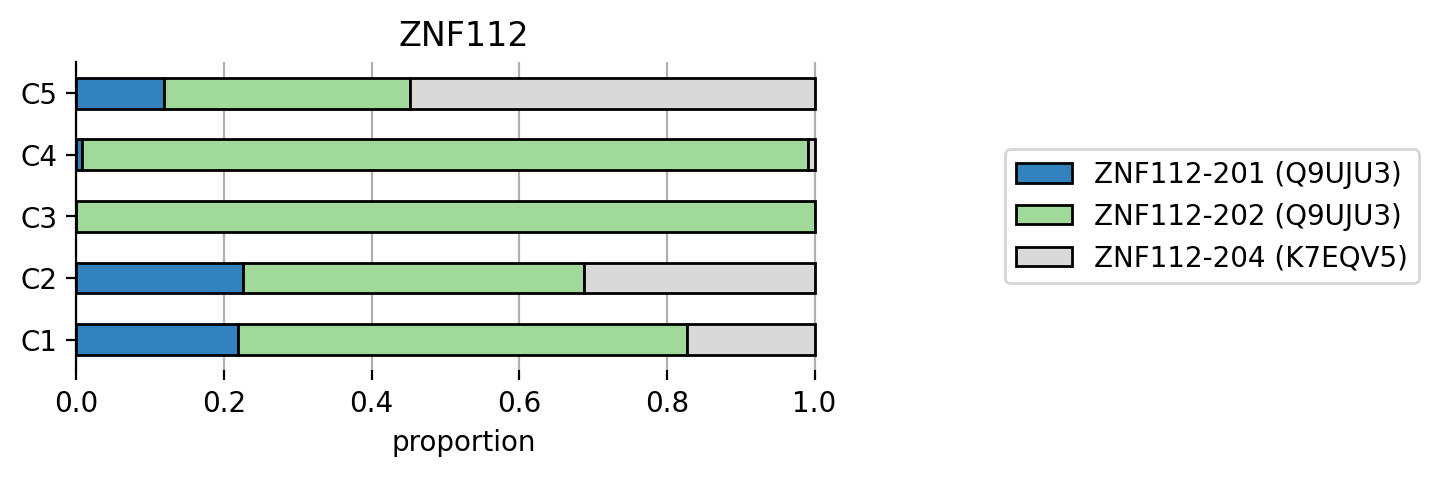

ZNF114


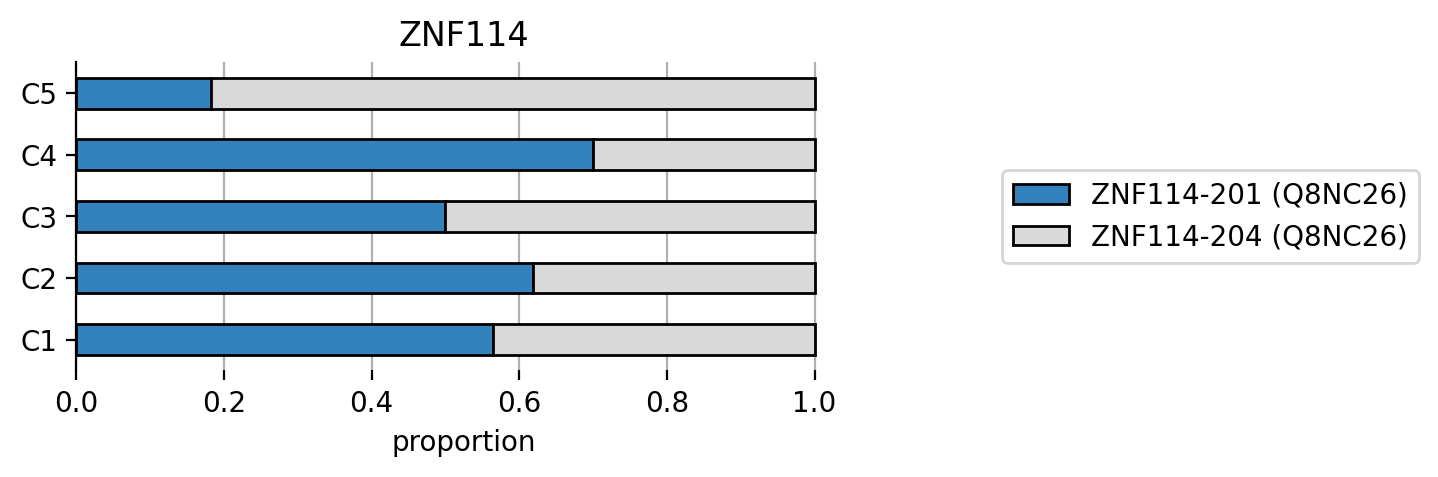

ZNF174


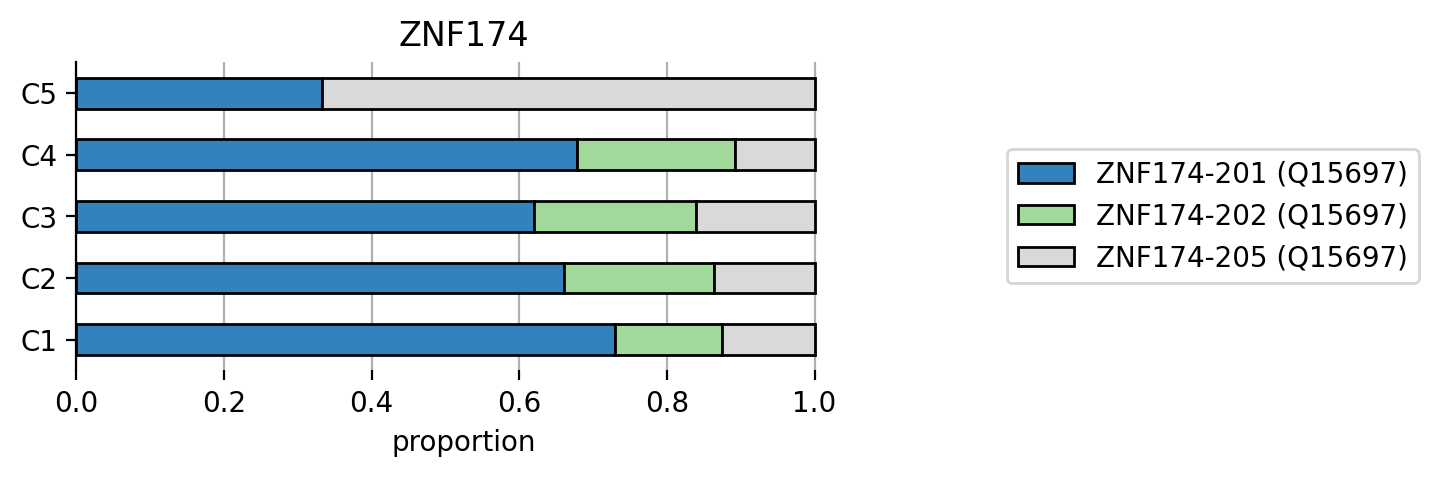

ZNF181


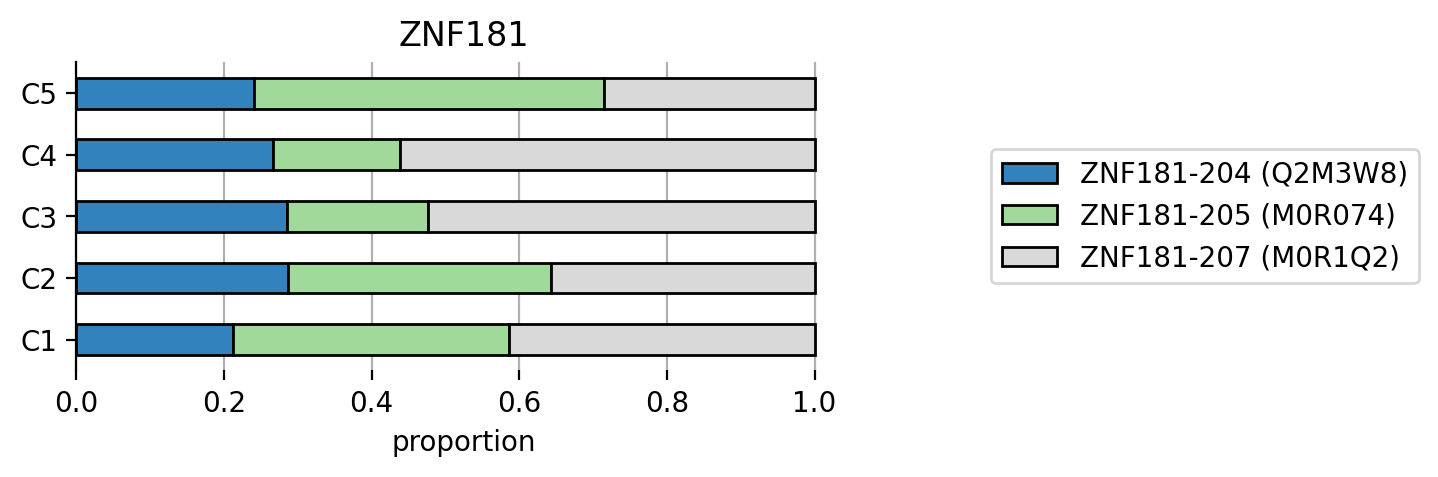

ZNF331


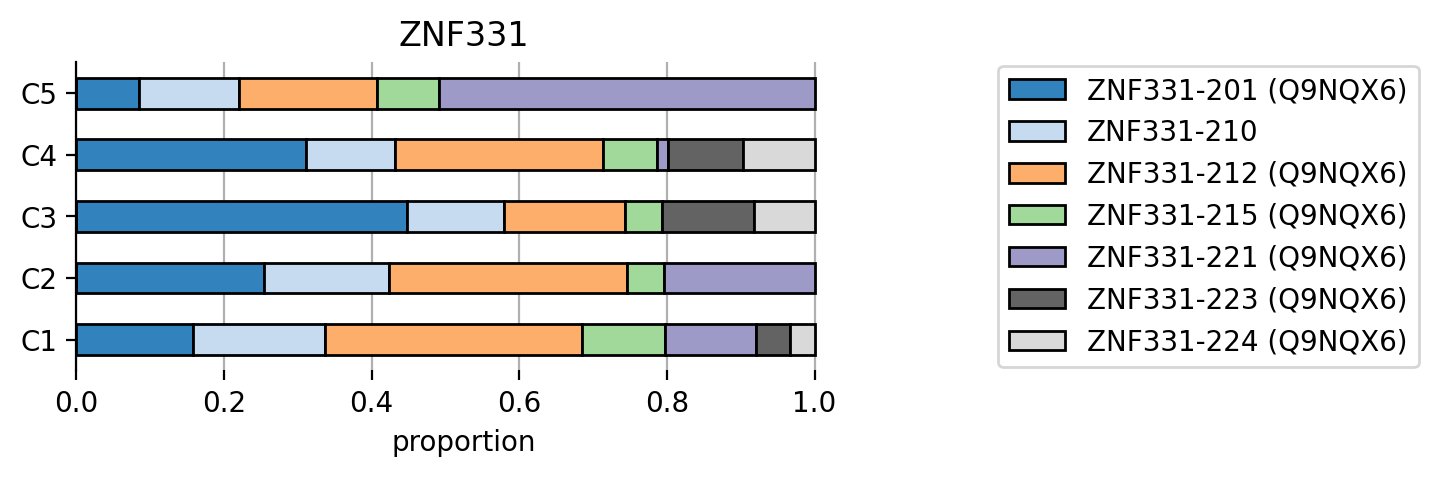

ZNF439


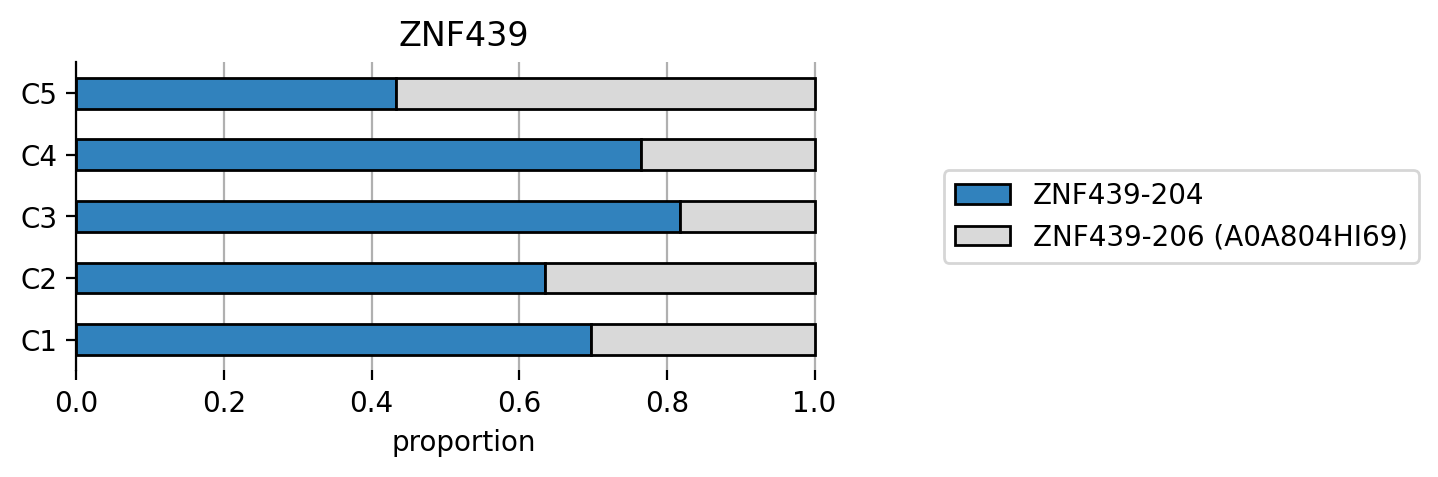

ZNF554


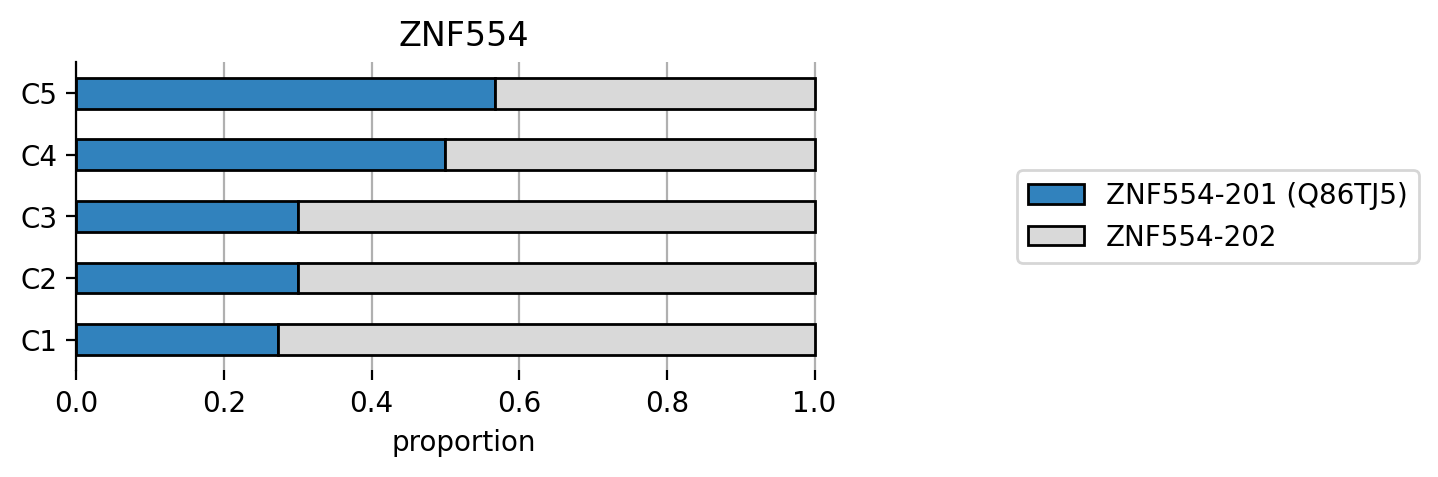

ZNF580


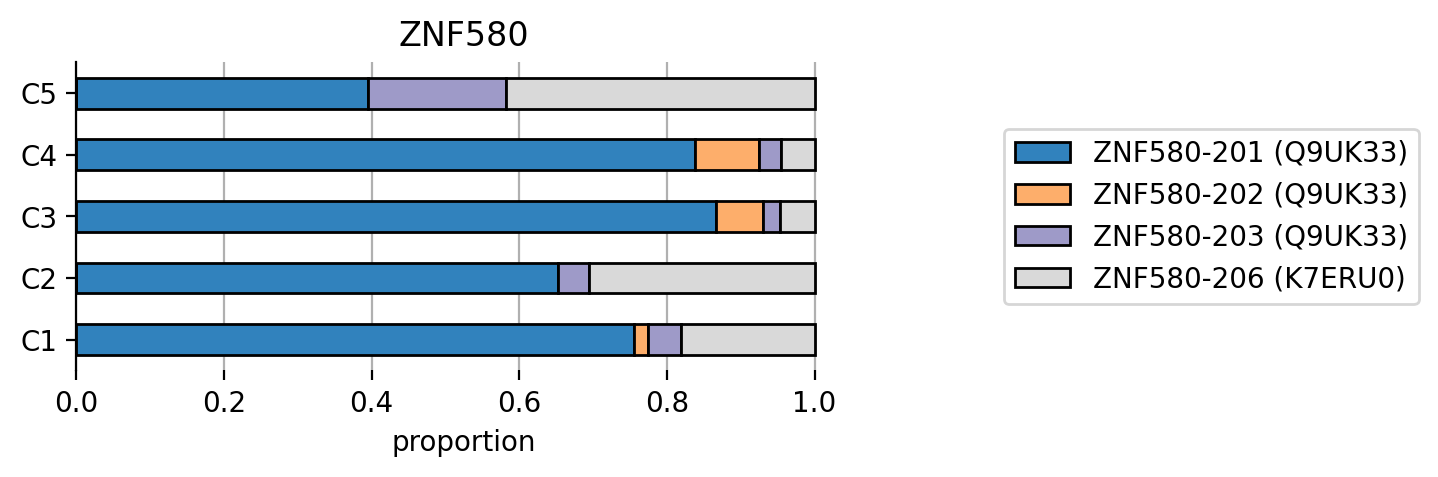

ZNF623


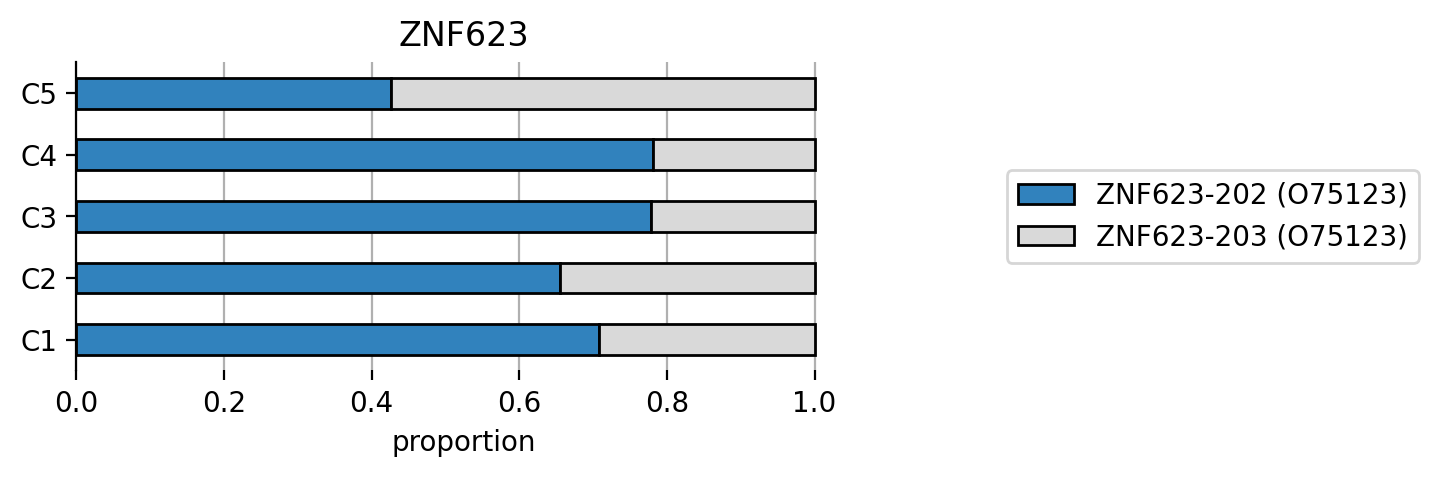

ZNF639


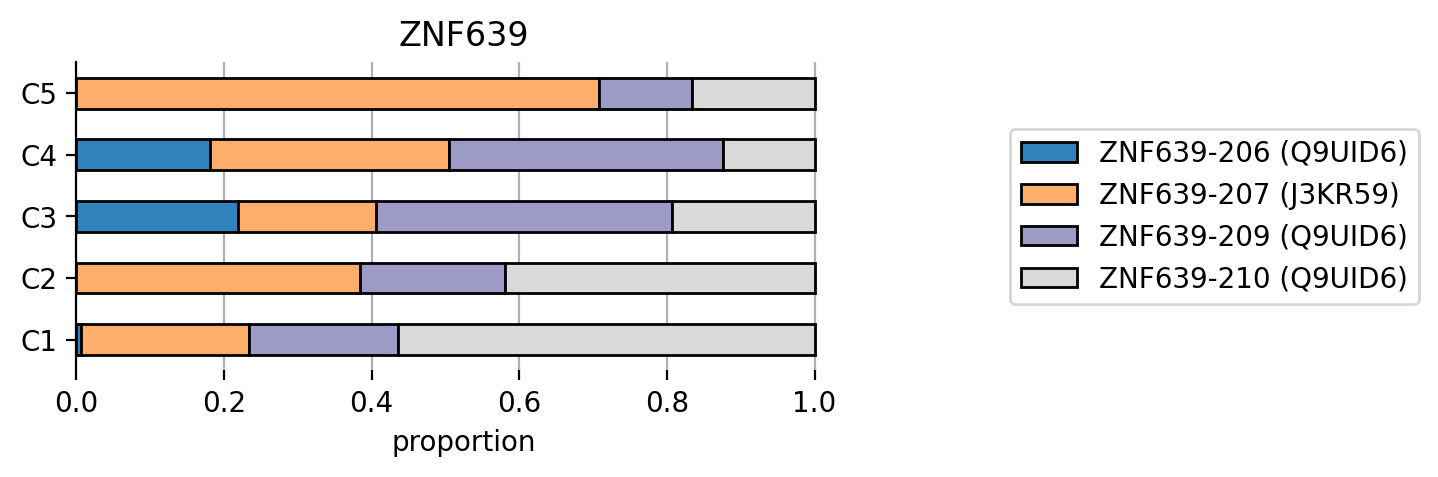

ZNF677


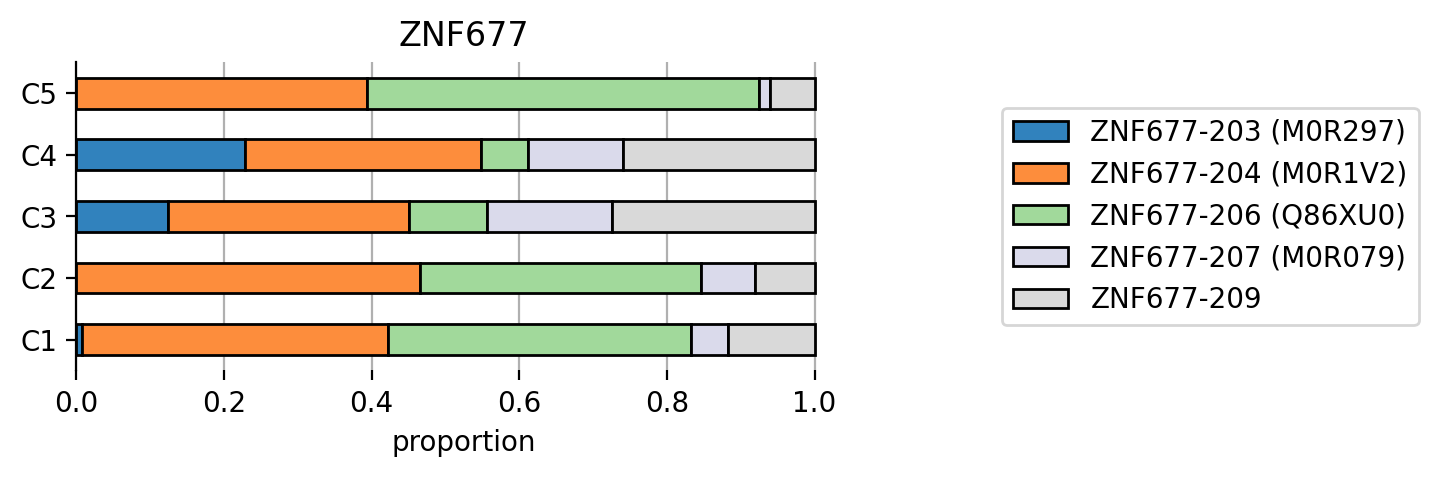

ZNF845


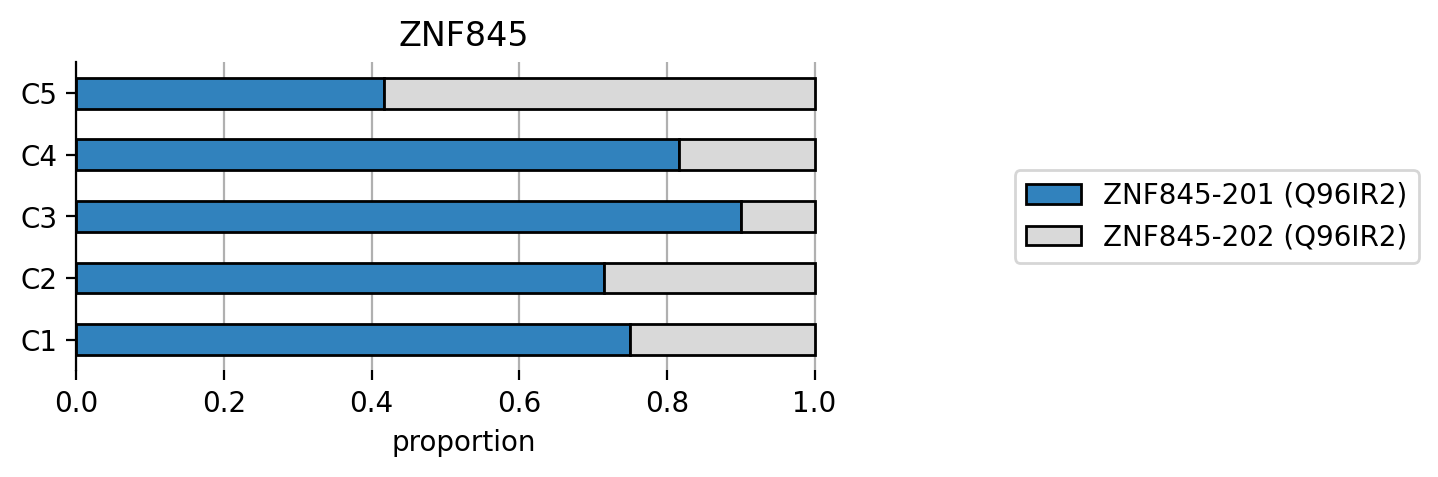

In [36]:
plot_df = pdf.copy()
print(plot_df.columns)
print()

annotation_cols = ['transcript_name', 'transcript_type', 'uniprot', 'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE']

# for gene in results['gene_name'].values:
for gene in results['gene_name'].unique():
    print(gene)

    gene_df = plot_df[plot_df['gene_name'] == gene].reset_index()

    # Option 1: using np.where
    gene_df['annotation'] = (
        gene_df['transcript_name']
        + np.where(
            gene_df['uniprot'].notna(),
            ' (' + gene_df['uniprot'] + ')',
            ''
        )
    )
    
    tmp = gene_df.set_index('annotation').copy()
    tmp = tmp[['C1_pct', 'C2_pct', 'C3_pct', 'C4_pct', 'C5_pct']]
    tmp.columns = [x.replace("_pct", "") for x in tmp.columns]

    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 5, 2

    # 1) Plot figure without legend
    fig1, ax1 = plt.subplots()
    tmp.T.plot(
        kind='barh',
        stacked=True,
        ec='k',
        zorder=10,
        width=0.5,
        cmap='tab20c',
        ax=ax1
    )
    ax1.grid(axis='x', zorder=0)
    ax1.set_xlabel("proportion")
    sns.move_legend(
        ax1,
        loc='center right',
        title="",
        bbox_to_anchor=(1.75, 0.5),
    )
    ax1.set_title(gene)
    sns.despine(bottom=True)
    plt.show()
    
    # break